In [12]:
# Cell 1: Section 1 - Initialization: Imports
#
# Import all required libraries for the project.
#

# --- Core Libraries ---
import os
import sys
import logging
import time

# --- Data Handling ---
import pandas as pd
import numpy as np

import findspark
findspark.init()
# --- PySpark Core ---
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, isnan, avg, stddev, min, max, sum, lit, broadcast
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, IntegerType
from pyspark.sql.window import Window

# --- PySpark ML (Preprocessing) ---
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.stat import Correlation

# --- PySpark ML (Models) ---
from pyspark.ml.classification import RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Model Evaluation (Local) ---
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score

print("="*80)
print("Cell 1: All libraries imported successfully.")
print(f"PySpark Version: {pyspark.__version__}")
print("="*80)

Cell 1: All libraries imported successfully.
PySpark Version: 3.5.1


In [ ]:
# Cell 2: Section 1 - Logging and Path Configuration [MODIFIED]
#
# Configure logging, define all project paths, and create output directories.
# Changes: use project-local base, add HDFS/raw paths, and prepare checkpoint directory.

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S',
)
log = logging.getLogger("FraudDetectionLogger")
log.info("Logging initialized.")

try:
    # Base project directory
    PROJECT_DIR = os.path.abspath(os.getcwd())

    # --- Local Paths (for initial ingest only) ---
    LOCAL_DATASET_PATH = os.path.join(PROJECT_DIR, 'data', 'PS_20174392719_1491204439457_log.csv')

    # --- Cluster / HDFS Configuration ---
    # Default to distributed storage and cluster mode unless explicitly disabled
    USE_HDFS = True
    HDFS_BASE_PATH = os.getenv("HDFS_BASE_PATH", "/user/atomic/fraud_detection")
    HDFS_RAW_CSV_PATH = f"{HDFS_BASE_PATH}/data/transactions.csv"
    HDFS_DATA_PATH = f"{HDFS_BASE_PATH}/data/transactions.parquet"
    HDFS_INTERMEDIATE_PATH = f"{HDFS_BASE_PATH}/intermediate"
    HDFS_PROCESSED_PATH = f"{HDFS_INTERMEDIATE_PATH}/processed.parquet"
    HDFS_UNBALANCED_TRAIN_PATH = f"{HDFS_INTERMEDIATE_PATH}/unbalanced_train.parquet"
    HDFS_TEST_PATH = f"{HDFS_INTERMEDIATE_PATH}/test.parquet"
    HDFS_TRAIN_PATH = f"{HDFS_INTERMEDIATE_PATH}/train_balanced.parquet"
    HDFS_CHECKPOINT_DIR = f"{HDFS_BASE_PATH}/checkpoints"

    # --- Hive Configuration ---
    HIVE_DB_NAME = "fraud_detection_db"
    HIVE_TABLE_NAME = "transactions"

    # --- Output & Model Paths (local, for plots and quick access) ---
    OUTPUT_DIR = os.path.join(PROJECT_DIR, 'output')
    PLOT_OUTPUT_DIR = os.path.join(OUTPUT_DIR, 'plots')
    METRICS_OUTPUT_DIR = os.path.join(OUTPUT_DIR, 'metrics')
    MODEL_OUTPUT_DIR = os.path.join(PROJECT_DIR, 'models')

    log.info(f"Project Directory: {PROJECT_DIR}")
    log.info(f"Local Dataset: {LOCAL_DATASET_PATH}")
    log.info(f"HDFS Base Path: {HDFS_BASE_PATH}")
    log.info(f"HDFS Parquet Path: {HDFS_DATA_PATH}")
    log.info(f"HDFS Checkpoint Dir: {HDFS_CHECKPOINT_DIR}")

    # --- Create Local Output Directories ---
    os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)
    os.makedirs(METRICS_OUTPUT_DIR, exist_ok=True)
    os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)

    log.info(f"Created output plot directory: {PLOT_OUTPUT_DIR}")

    # --- Visualization Settings ---
    sns.set_style("whitegrid")
    plt.rcParams['figure.dpi'] = 300
    log.info("Seaborn and Matplotlib configured.")

except Exception as e:
    log.error(f"Error setting up paths: {e}")

print("="*80)
print("Cell 2: Logging and paths configured.")
print("="*80)

2026-04-14 23:32:29 - FraudDetectionLogger - INFO - Logging initialized.
2026-04-14 23:32:29 - FraudDetectionLogger - INFO - Project Directory: /home/atomic/Desktop/BDA_Project
2026-04-14 23:32:29 - FraudDetectionLogger - INFO - Local Dataset: /home/atomic/Desktop/BDA_Project/data/PS_20174392719_1491204439457_log.csv
2026-04-14 23:32:29 - FraudDetectionLogger - INFO - HDFS Parquet Path: /user/atomic/fraud_detection/data/transactions.parquet
2026-04-14 23:32:29 - FraudDetectionLogger - INFO - HDFS Intermediate Path: /user/atomic/fraud_detection/intermediate
2026-04-14 23:32:29 - FraudDetectionLogger - INFO - Created output plot directory: /home/atomic/Desktop/BDA_Project/output/plots
2026-04-14 23:32:29 - FraudDetectionLogger - INFO - Seaborn and Matplotlib configured.


Cell 2: Logging and paths configured.


In [ ]:
# Cell 3: Section 1 - Initialize SparkSession for Hadoop Cluster [MODIFIED]
#
# Cluster-ready SparkSession with strict non-local validation and executor checks.

try:
    log.info("Building SparkSession for cluster...")

    import warnings
    warnings.filterwarnings("ignore")

    # Prefer distributed cluster manager; override via SPARK_MASTER env if needed
    SPARK_MASTER = os.getenv("SPARK_MASTER", "spark://master:7077")
    if "local" in SPARK_MASTER.lower():
        raise ValueError("SPARK_MASTER is set to local mode. Set SPARK_MASTER to your cluster URL.")

    # Allow tuning via environment variables
    SPARK_EXECUTOR_INSTANCES = int(os.getenv("SPARK_EXECUTOR_INSTANCES", "2"))
    SPARK_EXECUTOR_CORES = os.getenv("SPARK_EXECUTOR_CORES", "2")
    SPARK_EXECUTOR_MEMORY = os.getenv("SPARK_EXECUTOR_MEMORY", "4g")
    SPARK_DRIVER_MEMORY = os.getenv("SPARK_DRIVER_MEMORY", "4g")

    spark = (
        SparkSession.builder
        .appName("PySpark_Fraud_Detection_Project")
        .master(SPARK_MASTER)
        .enableHiveSupport()

        # ===============================
        # MEMORY SETTINGS
        # ===============================
        .config("spark.driver.memory", SPARK_DRIVER_MEMORY)
        .config("spark.executor.memory", SPARK_EXECUTOR_MEMORY)
        .config("spark.executor.memoryOverhead", "1g")
        .config("spark.driver.maxResultSize", "2g")

        # ===============================
        # EXECUTOR SETTINGS
        # ===============================
        .config("spark.executor.instances", str(SPARK_EXECUTOR_INSTANCES))
        .config("spark.executor.cores", str(SPARK_EXECUTOR_CORES))
        .config("spark.dynamicAllocation.enabled", "false")

        # ===============================
        # SHUFFLE / SQL OPTIMIZATION
        # ===============================
        .config("spark.sql.shuffle.partitions", "100")
        .config("spark.sql.adaptive.enabled", "true")
        .config("spark.sql.adaptive.coalescePartitions.enabled", "true")

        # ===============================
        # SERIALIZER
        # ===============================
        .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")

        # ===============================
        # NETWORK TIMEOUTS
        # ===============================
        .config("spark.executor.heartbeatInterval", "30s")
        .config("spark.network.timeout", "600s")

        # ===============================
        # HIVE / WAREHOUSE
        # ===============================
        .config("spark.sql.warehouse.dir", "/user/hive/warehouse")
        .config("spark.hadoop.fs.defaultFS", "hdfs://master:9000")

        # ===============================
        # GC OPTIMIZATION
        # ===============================
        .config("spark.executor.extraJavaOptions", "-XX:+UseG1GC")
        .config("spark.driver.extraJavaOptions", "-XX:+UseG1GC")

        .getOrCreate()
    )

    sc = spark.sparkContext
    sc.setLogLevel("ERROR")

    log.info("SparkSession created successfully.")
    log.info(f"Connected to: {sc.master}")

    # =====================================
    # HIVE DATABASE
    # =====================================
    databases = spark.sql("SHOW DATABASES").collect()
    db_exists = any(
        (row.asDict().get("namespace") or row.asDict().get("databaseName")) == HIVE_DB_NAME
        for row in databases
    )

    if not db_exists:
        spark.sql(f"CREATE DATABASE {HIVE_DB_NAME}")
        log.info(f"Created Hive DB: {HIVE_DB_NAME}")
    else:
        log.info(f"Hive DB already exists: {HIVE_DB_NAME}")

    spark.sql(f"USE {HIVE_DB_NAME}")

    # =====================================
    # HDFS DIRECTORIES + CHECKPOINTS
    # =====================================
    fs = spark._jvm.org.apache.hadoop.fs.FileSystem.get(
        spark._jsc.hadoopConfiguration()
    )

    for path_str in [HDFS_INTERMEDIATE_PATH, HDFS_CHECKPOINT_DIR]:
        hdfs_path = spark._jvm.org.apache.hadoop.fs.Path(path_str)
        if not fs.exists(hdfs_path):
            fs.mkdirs(hdfs_path)
            log.info(f"Created HDFS dir: {path_str}")

    sc.setCheckpointDir(HDFS_CHECKPOINT_DIR)
    log.info(f"Spark checkpoint dir set to: {HDFS_CHECKPOINT_DIR}")

    # =====================================
    # EXECUTOR VALIDATION (multi-node requirement)
    # =====================================
    tracker = sc._jsc.sc().statusTracker()
    executor_infos = tracker.getExecutorInfos()
    executor_hosts = [info.host() for info in executor_infos if info.executorId() != "driver"]
    unique_hosts = sorted(set(executor_hosts))
    log.info(f"Executor hosts: {unique_hosts}")
    if len(unique_hosts) < 2:
        raise RuntimeError(
            "Cluster executors not detected. Ensure workers are started on all laptops and registered with the master."
        )

except Exception as e:
    log.error(f"Error initializing SparkSession: {e}")
    raise e

print("=" * 80)
print("Cell 3: SparkSession initialized on cluster")
print("=" * 80)

2026-04-14 23:32:30 - FraudDetectionLogger - INFO - Building SparkSession for standalone cluster...
2026-04-14 23:32:30 - FraudDetectionLogger - INFO - SparkSession created successfully.
2026-04-14 23:32:30 - FraudDetectionLogger - INFO - Connected to: spark://master:7077
2026-04-14 23:32:31 - FraudDetectionLogger - INFO - Hive DB already exists: fraud_detection_db


Cell 3: SparkSession initialized on cluster (master, worker1, worker2)


In [ ]:
# Cell 4 (legacy): Spark Session Validation [MODIFIED]
#
# Validate cluster mode and list executors/hosts.

if 'spark' not in globals():
    raise RuntimeError("SparkSession is not initialized. Run Cell 3 first.")

master_url = spark.sparkContext.master
if "local" in master_url.lower():
    raise RuntimeError(f"Spark is running in local mode: {master_url}")

tracker = spark.sparkContext._jsc.sc().statusTracker()
executor_infos = tracker.getExecutorInfos()
executor_hosts = [info.host() for info in executor_infos if info.executorId() != "driver"]
unique_hosts = sorted(set(executor_hosts))

print("Connected to:", master_url)
print("Executor hosts:", unique_hosts)
print("Executor count:", len(executor_hosts))

Connected to: spark://master:7077


In [ ]:
# Cell 5: Section 2 - Data Ingest (CSV -> HDFS Parquet) [MODIFIED]
#
# Phase 1: Load the CSV once, store Parquet in distributed storage, and reuse.
# Added HDFS raw upload + idempotent parquet creation for fault tolerance.

# Optional — Run packaged `src` modules automatically
USE_EXTERNAL_SCRIPTS = False

if USE_EXTERNAL_SCRIPTS:
    log.info("Running external src modules: bigdata_pipeline -> sequence_builder -> lstm_trainer")
    from src.bigdata_pipeline import StorageConfig, run_distributed_pipeline
    from src.sequence_builder import generate_sequence_dataset
    from src import lstm_trainer

    storage = StorageConfig(
        local_dataset=LOCAL_DATASET_PATH,
        hdfs_parquet=HDFS_DATA_PATH,
        hdfs_intermediate_dir=HDFS_INTERMEDIATE_PATH,
        hdfs_processed=HDFS_PROCESSED_PATH,
        hdfs_train_unbalanced=HDFS_UNBALANCED_TRAIN_PATH,
        hdfs_train_balanced=HDFS_TRAIN_PATH,
        hdfs_test=HDFS_TEST_PATH,
        local_model_dir=MODEL_OUTPUT_DIR,
    )
    storage.ensure_local_dirs()

    metrics = run_distributed_pipeline(storage, extra_conf={"spark.master": spark.sparkContext.master})
    print("Big Data pipeline metrics:\n", metrics)

    df_transactions = spark.read.parquet(HDFS_DATA_PATH)
    seq_df = generate_sequence_dataset(df_transactions, sequence_length=12, sliding_step=3)

    seq_out_local = os.path.join(PROJECT_DIR, "results", "deep_learning", "sequence_windows.parquet")
    os.makedirs(os.path.dirname(seq_out_local), exist_ok=True)
    seq_df.write.mode("overwrite").parquet(seq_out_local)
    log.info(f"Sequence parquet written to {seq_out_local}")

    import argparse
    args = argparse.Namespace(
        sequence_path=seq_out_local,
        model_path=os.path.join(MODEL_OUTPUT_DIR, "lstm_fraud_model.keras"),
        scaler_path=os.path.join(MODEL_OUTPUT_DIR, "lstm_step_scaler.pkl"),
        sample_limit=50000,
        test_size=0.2,
        epochs=5,
        batch_size=128,
    )
    lstm_trainer.main(args)

else:
    log.info("USE_EXTERNAL_SCRIPTS is False — skipping automatic invocation of src modules.")

try:
    log.info("Starting Phase 1: Ingesting CSV and creating Parquet...")
    
    schema = StructType([
        StructField("step", IntegerType(), True),
        StructField("type", StringType(), True),
        StructField("amount", DoubleType(), True),
        StructField("nameOrig", StringType(), True),
        StructField("oldbalanceOrg", DoubleType(), True),
        StructField("newbalanceOrig", DoubleType(), True),
        StructField("nameDest", StringType(), True),
        StructField("oldbalanceDest", DoubleType(), True),
        StructField("newbalanceDest", DoubleType(), True),
        StructField("isFraud", IntegerType(), True),
        StructField("isFlaggedFraud", IntegerType(), True)
    ])

    fs = spark._jvm.org.apache.hadoop.fs.FileSystem.get(spark._jsc.hadoopConfiguration())
    parquet_path = spark._jvm.org.apache.hadoop.fs.Path(HDFS_DATA_PATH)
    raw_path = spark._jvm.org.apache.hadoop.fs.Path(HDFS_RAW_CSV_PATH)

    if fs.exists(parquet_path):
        log.info("Parquet already exists on HDFS. Skipping CSV ingest.")
    else:
        if USE_HDFS:
            if not fs.exists(raw_path):
                log.info("Uploading raw CSV to HDFS...")
                fs.copyFromLocalFile(False, True,
                                     spark._jvm.org.apache.hadoop.fs.Path(LOCAL_DATASET_PATH),
                                     raw_path)
            log.info("Reading raw CSV from HDFS...")
            df_raw = spark.read.csv(HDFS_RAW_CSV_PATH, header=True, schema=schema)
        else:
            log.info("Reading raw CSV from local filesystem...")
            df_raw = spark.read.csv(f"file://{LOCAL_DATASET_PATH}", header=True, schema=schema)
        
        log.info("Writing Parquet to distributed storage...")
        df_raw.write.mode("overwrite").parquet(HDFS_DATA_PATH)
        log.info(f"Phase 1 Complete: Data written to {HDFS_DATA_PATH}")

except Exception as e:
    log.error(f"Error during data ingest: {e}")
    log.error("Ensure HDFS is running and accessible.")
    raise e

print("="*80)
print("Cell 5: Data ingested and Parquet ready.")
print("="*80)

2026-04-14 23:33:23 - FraudDetectionLogger - INFO - USE_EXTERNAL_SCRIPTS is False — skipping automatic invocation of src modules.
2026-04-14 23:33:23 - FraudDetectionLogger - INFO - Starting Phase 1: Ingesting local CSV from /home/atomic/Desktop/BDA_Project/data/PS_20174392719_1491204439457_log.csv
2026-04-14 23:33:23 - FraudDetectionLogger - INFO - Local CSV read successfully. Writing to HDFS Parquet...
2026-04-14 23:33:55 - FraudDetectionLogger - INFO - Phase 1 Complete: Data written to HDFS at /user/atomic/fraud_detection/data/transactions.parquet


Cell 4: Data ingested from local CSV and saved to HDFS as Parquet.


In [18]:
# Cell 5: Section 2 - Load Data from HDFS
#
# Phase 2: All subsequent work will use the fast, distributed HDFS Parquet file.
#

try:
    log.info(f"Starting Phase 2: Loading Parquet data from HDFS: {HDFS_DATA_PATH}")
    
    df = spark.read.parquet(HDFS_DATA_PATH)
    
    # --- *** MODIFICATION: Removed persist() *** ---
    # We will re-read this file from HDFS as needed.
    
    # Trigger an action to load the data and log the count
    total_records = df.count()
    log.info(f"Successfully loaded {total_records} records from HDFS Parquet.")

except Exception as e:
    log.error(f"Error loading HDFS Parquet file: {e}")
    raise e

print("="*80)
print(f"Cell 5: Successfully loaded {total_records} records from HDFS.")
print("="*80)

2026-04-14 23:34:10 - FraudDetectionLogger - INFO - Starting Phase 2: Loading Parquet data from HDFS: /user/atomic/fraud_detection/data/transactions.parquet
2026-04-14 23:34:15 - FraudDetectionLogger - INFO - Successfully loaded 6362620 records from HDFS Parquet.


Cell 5: Successfully loaded 6362620 records from HDFS.


In [19]:
# Cell 6: Section 2 - Schema and First Look
try:
    log.info("Displaying DataFrame schema:")
    df.printSchema()
    
    log.info("Displaying first 20 records:")
    df.show(20, truncate=False)
    
except Exception as e:
    log.error(f"Error displaying schema or data: {e}")

print("="*80)
print("Cell 6: Schema and sample data displayed.")
print("="*80)

2026-04-14 23:34:16 - FraudDetectionLogger - INFO - Displaying DataFrame schema:
2026-04-14 23:34:16 - FraudDetectionLogger - INFO - Displaying first 20 records:


root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- nameOrig: string (nullable = true)
 |-- oldbalanceOrg: double (nullable = true)
 |-- newbalanceOrig: double (nullable = true)
 |-- nameDest: string (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- newbalanceDest: double (nullable = true)
 |-- isFraud: integer (nullable = true)
 |-- isFlaggedFraud: integer (nullable = true)



+----+--------+---------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|step|type    |amount   |nameOrig   |oldbalanceOrg|newbalanceOrig|nameDest   |oldbalanceDest|newbalanceDest|isFraud|isFlaggedFraud|
+----+--------+---------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|161 |PAYMENT |18003.02 |C414361072 |0.0          |0.0           |M1783921537|0.0           |0.0           |0      |0             |
|161 |PAYMENT |7175.57  |C931295611 |0.0          |0.0           |M2007760563|0.0           |0.0           |0      |0             |
|161 |PAYMENT |18672.42 |C2050705555|0.0          |0.0           |M863681574 |0.0           |0.0           |0      |0             |
|161 |PAYMENT |14636.07 |C391580315 |0.0          |0.0           |M1059135652|0.0           |0.0           |0      |0             |
|161 |PAYMENT |24088.99 |C536778755 |0.0          |0.0           |M203027567

In [20]:
# Cell 7: Section 2 - Null Value Check
#
# Check for null or NaN values in all columns.
#

try:
    log.info("Checking for null values...")
    
    # Create an expression for each column to count nulls
    from pyspark.sql.functions import count, when, isnan, col
    
    null_counts = df.select([
        count(when(isnan(c) | col(c).isNull(), c)).alias(c) 
        for c in df.columns
    ])
    
    log.info("Null value counts per column:")
    null_counts.show()
    
    # This will be a 1-row DataFrame. Collect it to print a summary.
    null_counts_pd = null_counts.collect()[0].asDict()
    
    # Use Python's built-in sum function directly (avoid name conflict)
    import builtins
    total_nulls = builtins.sum(null_counts_pd.values())
    
    if total_nulls == 0:
        log.info("PASSED: No null or NaN values found in the dataset.")
    else:
        log.warning(f"WARNING: Found {total_nulls} total null/NaN values.")

except Exception as e:
    log.error(f"Error checking for null values: {e}")

print("="*80)
print("Cell 7: Null value check complete.")
print("="*80)

2026-04-14 23:34:23 - FraudDetectionLogger - INFO - Checking for null values...
2026-04-14 23:34:24 - FraudDetectionLogger - INFO - Null value counts per column:
                                                                                

+----+----+------+--------+-------------+--------------+--------+--------------+--------------+-------+--------------+
|step|type|amount|nameOrig|oldbalanceOrg|newbalanceOrig|nameDest|oldbalanceDest|newbalanceDest|isFraud|isFlaggedFraud|
+----+----+------+--------+-------------+--------------+--------+--------------+--------------+-------+--------------+
|   0|   0|     0|       0|            0|             0|       0|             0|             0|      0|             0|
+----+----+------+--------+-------------+--------------+--------+--------------+--------------+-------+--------------+



2026-04-14 23:35:17 - FraudDetectionLogger - INFO - PASSED: No null or NaN values found in the dataset.


Cell 7: Null value check complete.


In [21]:
# Cell 8: Section 2 - Basic Statistics
#
# Calculate descriptive statistics for key numerical columns.
#

try:
    log.info("Calculating descriptive statistics...")
    
    numeric_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
    
    stats = df.describe(numeric_cols)
    stats.show()

except Exception as e:
    log.error(f"Error calculating statistics: {e}")

print("="*80)
print("Cell 8: Descriptive statistics calculated.")
print("="*80)

2026-04-14 23:35:19 - FraudDetectionLogger - INFO - Calculating descriptive statistics...
[Stage 12:======================================>                   (2 + 1) / 3]

+-------+------------------+-----------------+------------------+------------------+------------------+
|summary|            amount|    oldbalanceOrg|    newbalanceOrig|    oldbalanceDest|    newbalanceDest|
+-------+------------------+-----------------+------------------+------------------+------------------+
|  count|           6362620|          6362620|           6362620|           6362620|           6362620|
|   mean|179861.90354912955| 833883.104074466| 855113.6685785623|1100701.6665196575|1224996.3982019091|
| stddev| 603858.2314629173|2888242.673037513|2924048.5029542376|3399180.1129944474| 3674128.942119666|
|    min|               0.0|              0.0|               0.0|               0.0|               0.0|
|    max|     9.244551664E7|    5.958504037E7|     4.958504037E7|    3.5601588935E8|    3.5617927892E8|
+-------+------------------+-----------------+------------------+------------------+------------------+

Cell 8: Descriptive statistics calculated.


In [22]:
# Cell 9: Section 3 (EDA) - Create Hive Table
#
# Create a managed Hive table for SQL-based analysis.
#

try:
    log.info(f"Creating Hive table '{HIVE_TABLE_NAME}' in database '{HIVE_DB_NAME}'...")
    
    # Save the DataFrame as a managed table in Hive
    df.write.mode("overwrite").saveAsTable(f"{HIVE_DB_NAME}.{HIVE_TABLE_NAME}")
    
    log.info("Hive table created successfully.")
    
    # Verify by showing tables
    spark.sql(f"USE {HIVE_DB_NAME}")
    spark.sql("SHOW TABLES").show()

except Exception as e:
    log.error(f"Error creating Hive table: {e}")
    raise e

print("="*80)
print(f"Cell 9: Hive table '{HIVE_TABLE_NAME}' created.")
print("="*80)

2026-04-14 23:35:26 - FraudDetectionLogger - INFO - Creating Hive table 'transactions' in database 'fraud_detection_db'...
2026-04-14 23:35:41 - FraudDetectionLogger - INFO - Hive table created successfully.


+------------------+------------+-----------+
|         namespace|   tableName|isTemporary|
+------------------+------------+-----------+
|fraud_detection_db|transactions|      false|
+------------------+------------+-----------+

Cell 9: Hive table 'transactions' created.


In [23]:
# Cell 10: Section 3 (EDA) - Class Imbalance (SQL)
#
# Analyze the distribution of fraud vs. normal transactions.
#

try:
    log.info("Analyzing class imbalance using Hive SQL...")
    
    sql_query = f"""
    SELECT 
        isFraud, 
        COUNT(*) as count,
        (COUNT(*) / (SELECT COUNT(*) FROM {HIVE_TABLE_NAME})) * 100 as percentage
    FROM {HIVE_TABLE_NAME}
    GROUP BY isFraud
    """
    
    imbalance_df = spark.sql(sql_query)
    imbalance_df.show()
    
    # Collect the small result to calculate imbalance ratio
    imbalance_data = imbalance_df.collect()
    
    count_normal = 0
    count_fraud = 0
    
    for row in imbalance_data:
        if row['isFraud'] == 0:
            count_normal = row['count']
        else:
            count_fraud = row['count']
            
    fraud_rate = (count_fraud / total_records) * 100
    imbalance_ratio = count_normal / count_fraud
    
    log.info(f"Total Records: {total_records}")
    log.info(f"Normal (0): {count_normal} | Fraud (1): {count_fraud}")
    log.info(f"Fraud Rate: {fraud_rate:.4f}%")
    log.info(f"Imbalance Ratio (Normal:Fraud): {imbalance_ratio:.2f} : 1")
    
    # Save for plotting
    plot_data_imbalance = imbalance_df.toPandas()

except Exception as e:
    log.error(f"Error analyzing class imbalance: {e}")

print("="*80)
print(f"Cell 10: Class imbalance analyzed. Fraud Rate: {fraud_rate:.4f}%.")
print("="*80)

2026-04-14 23:35:43 - FraudDetectionLogger - INFO - Analyzing class imbalance using Hive SQL...
                                                                                

+-------+-------+-------------------+
|isFraud|  count|         percentage|
+-------+-------+-------------------+
|      1|   8213|0.12908204481801522|
|      0|6354407|  99.87091795518198|
+-------+-------+-------------------+



2026-04-14 23:35:48 - FraudDetectionLogger - INFO - Total Records: 6362620
2026-04-14 23:35:48 - FraudDetectionLogger - INFO - Normal (0): 6354407 | Fraud (1): 8213
2026-04-14 23:35:48 - FraudDetectionLogger - INFO - Fraud Rate: 0.1291%
2026-04-14 23:35:48 - FraudDetectionLogger - INFO - Imbalance Ratio (Normal:Fraud): 773.70 : 1


Cell 10: Class imbalance analyzed. Fraud Rate: 0.1291%.


2026-04-14 23:35:49 - FraudDetectionLogger - INFO - Plotting class distribution...
2026-04-14 23:35:50 - FraudDetectionLogger - INFO - Saved class distribution plot to /home/atomic/Desktop/BDA_Project/output/plots/01_class_distribution.png


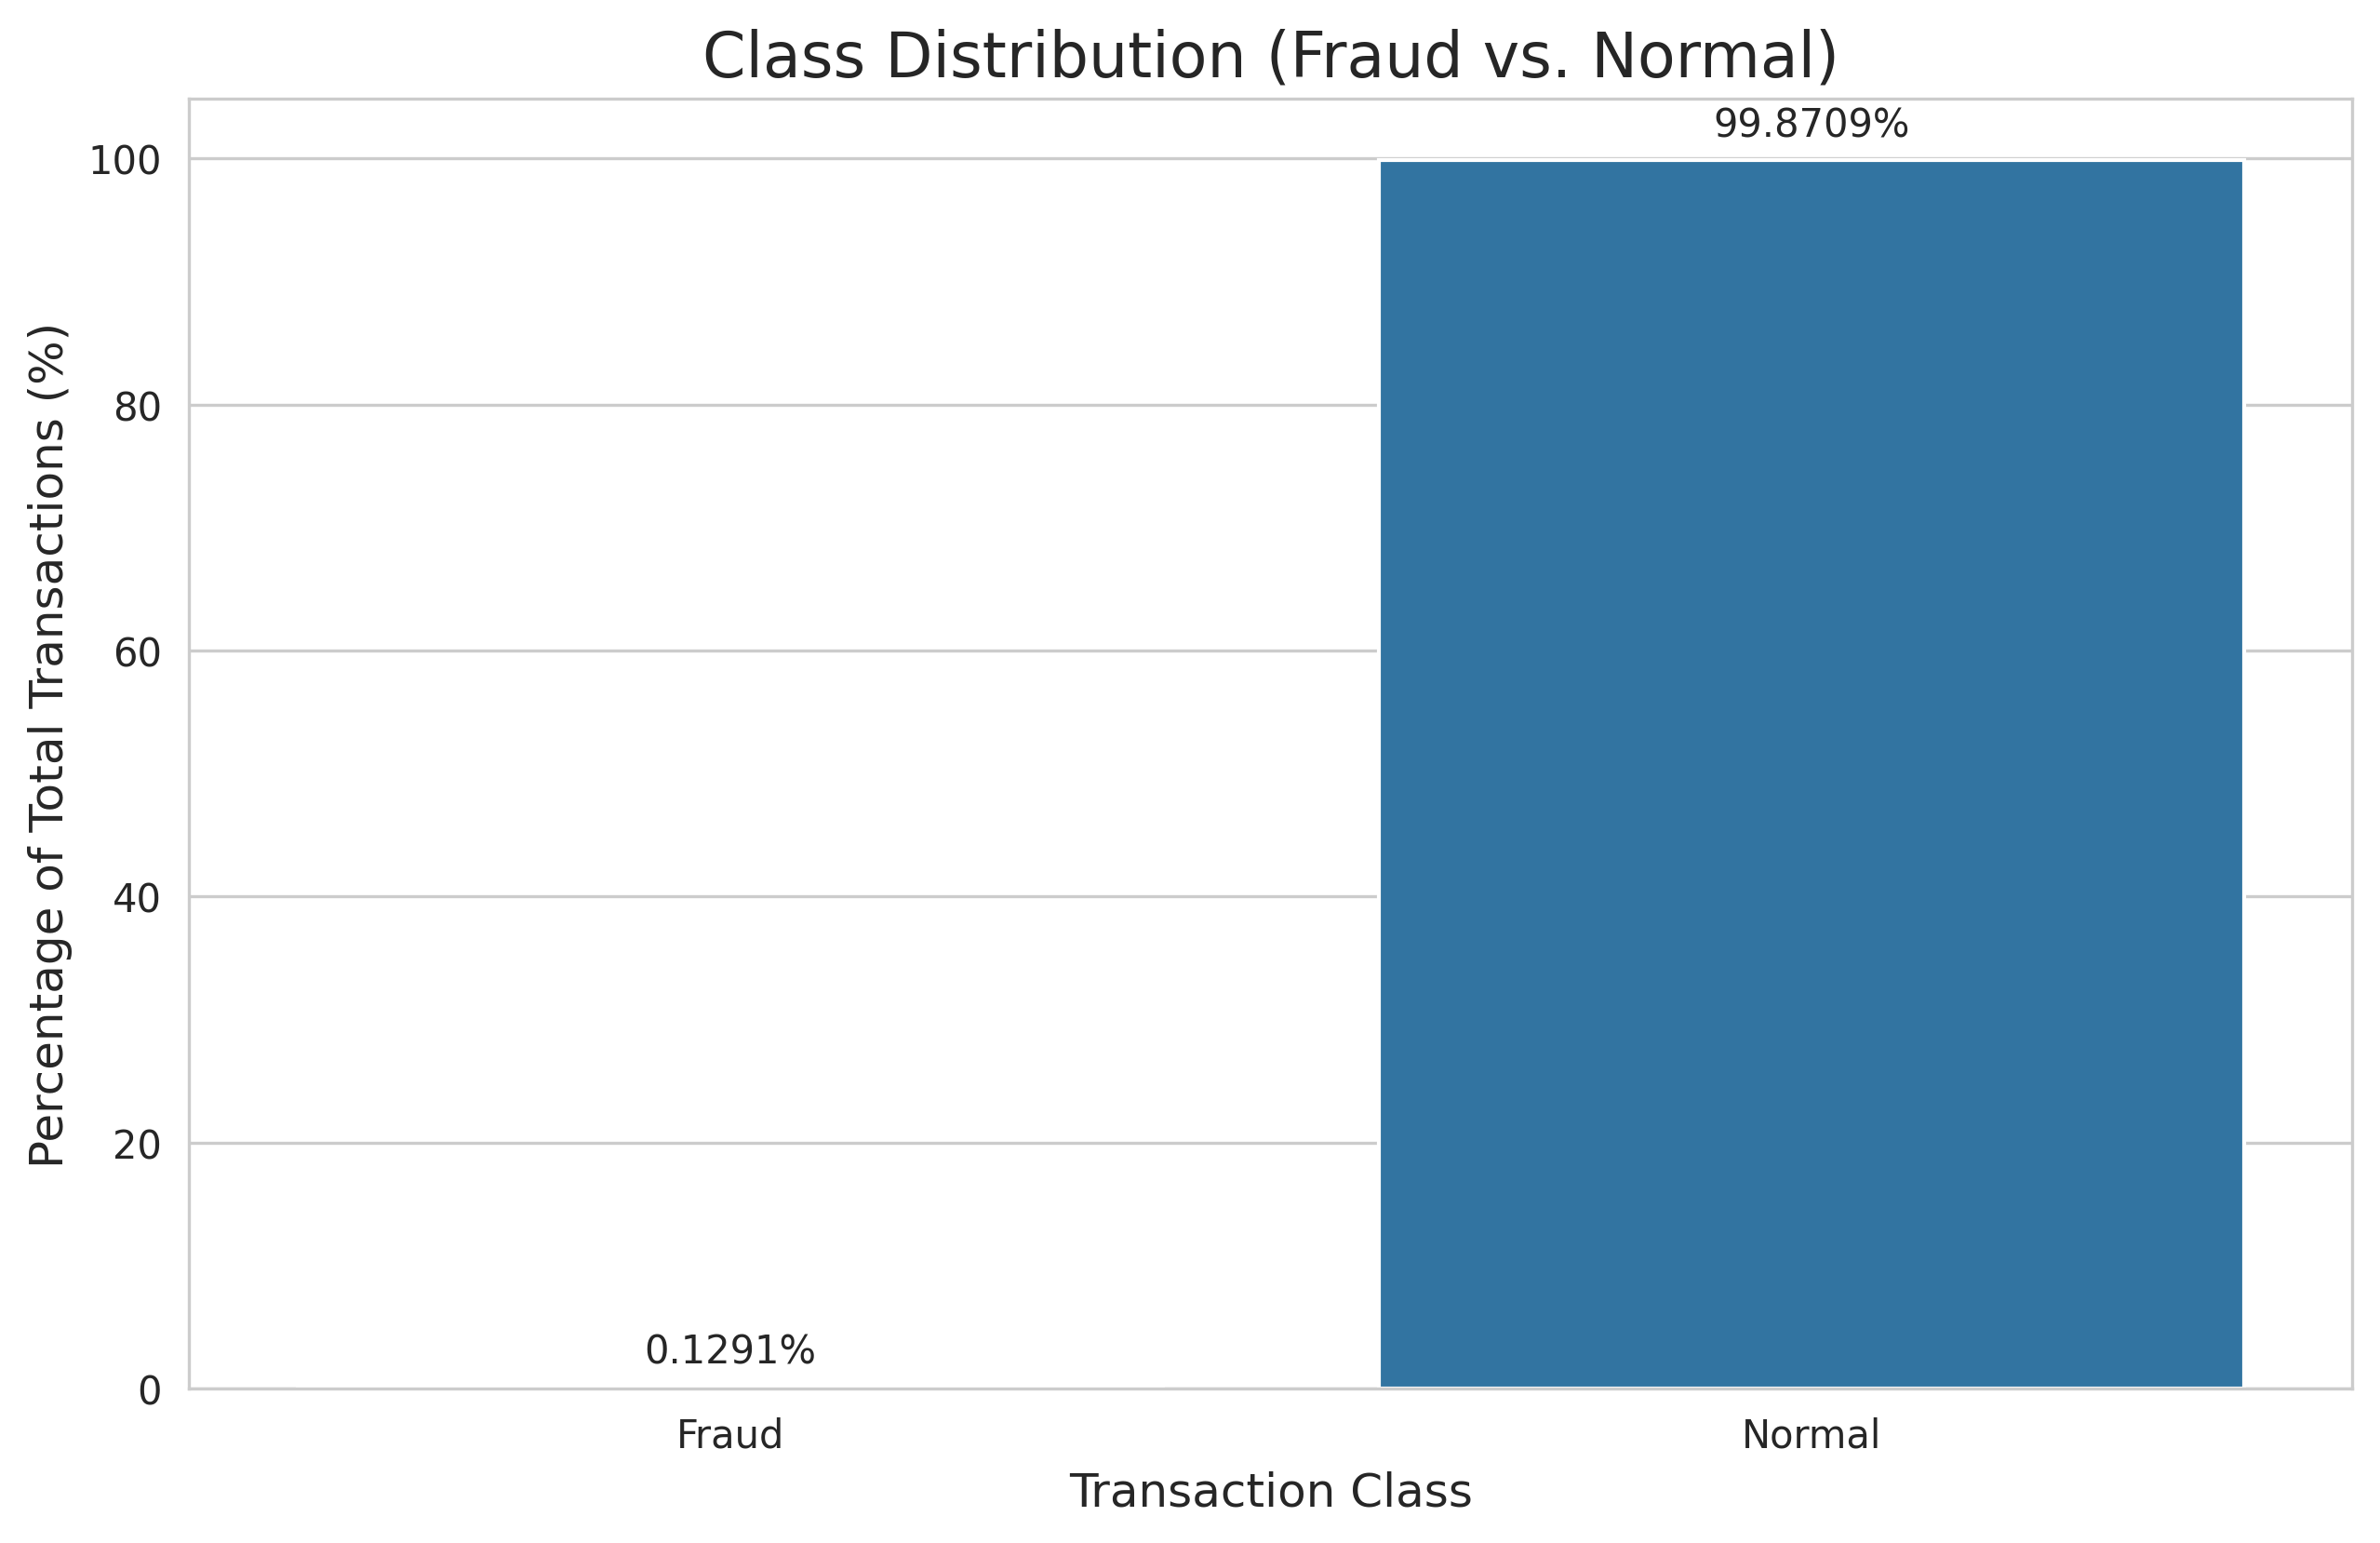

Cell 11: Class distribution plot generated.


In [24]:
# Cell 11: Section 3 (EDA) - Class Imbalance (Visualization)

try:
    log.info("Plotting class distribution...")
    plt.figure(figsize=(10, 6))
    
    ax = sns.barplot(
        x=plot_data_imbalance['isFraud'].map({0: 'Normal', 1: 'Fraud'}), 
        y=plot_data_imbalance['percentage']
    )
    
    ax.set_title('Class Distribution (Fraud vs. Normal)', fontsize=16)
    ax.set_xlabel('Transaction Class', fontsize=12)
    ax.set_ylabel('Percentage of Total Transactions (%)', fontsize=12)
    
    # Add text labels
    for p in ax.patches:
        ax.annotate(
            f"{p.get_height():.4f}%", 
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha='center', va='center', 
            xytext=(0, 9), 
            textcoords='offset points'
        )
    
    plot_path = os.path.join(PLOT_OUTPUT_DIR, '01_class_distribution.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    log.info(f"Saved class distribution plot to {plot_path}")
    
    plt.show()

except Exception as e:
    log.error(f"Error plotting class distribution: {e}")

print("="*80)
print("Cell 11: Class distribution plot generated.")
print("="*80)

In [25]:
# Cell 12: Section 3 (EDA) - Fraud by Transaction Type (SQL)

try:
    log.info("Analyzing fraud statistics by transaction type using Hive SQL...")
    
    sql_query = f"""
    SELECT 
        type, 
        COUNT(*) as total_transactions,
        SUM(isFraud) as total_fraud,
        (SUM(isFraud) / COUNT(*)) * 100 as fraud_percentage_of_type,
        (SUM(isFraud) / (SELECT SUM(isFraud) FROM {HIVE_TABLE_NAME})) * 100 as percentage_of_all_fraud
    FROM {HIVE_TABLE_NAME}
    GROUP BY type
    ORDER BY total_fraud DESC
    """
    
    type_fraud_df = spark.sql(sql_query)
    
    log.info("Fraud Statistics by Transaction Type:")
    type_fraud_df.show()
    
    # Key Insight
    log.warning("KEY INSIGHT: Note which transaction types have 0 fraud.")
    
    # Save for plotting
    plot_data_type = type_fraud_df.toPandas()

except Exception as e:
    log.error(f"Error analyzing fraud by type: {e}")

print("="*80)
print("Cell 12: Fraud statistics by transaction type calculated.")
print("="*80)

2026-04-14 23:35:51 - FraudDetectionLogger - INFO - Analyzing fraud statistics by transaction type using Hive SQL...
2026-04-14 23:35:52 - FraudDetectionLogger - INFO - Fraud Statistics by Transaction Type:
2026-04-14 23:35:55 - FraudDetectionLogger - WARNING - KEY INSIGHT: Note which transaction types have 0 fraud.


+--------+------------------+-----------+------------------------+-----------------------+
|    type|total_transactions|total_fraud|fraud_percentage_of_type|percentage_of_all_fraud|
+--------+------------------+-----------+------------------------+-----------------------+
|CASH_OUT|           2237500|       4116|     0.18395530726256984|      50.11567027882625|
|TRANSFER|            532909|       4097|      0.7687991758442811|      49.88432972117375|
| CASH_IN|           1399284|          0|                     0.0|                    0.0|
| PAYMENT|           2151495|          0|                     0.0|                    0.0|
|   DEBIT|             41432|          0|                     0.0|                    0.0|
+--------+------------------+-----------+------------------------+-----------------------+



Cell 12: Fraud statistics by transaction type calculated.


2026-04-14 23:35:57 - FraudDetectionLogger - INFO - Plotting fraud by transaction type...
2026-04-14 23:35:58 - FraudDetectionLogger - INFO - Saved fraud by type plot to /home/atomic/Desktop/BDA_Project/output/plots/02_fraud_by_type.png


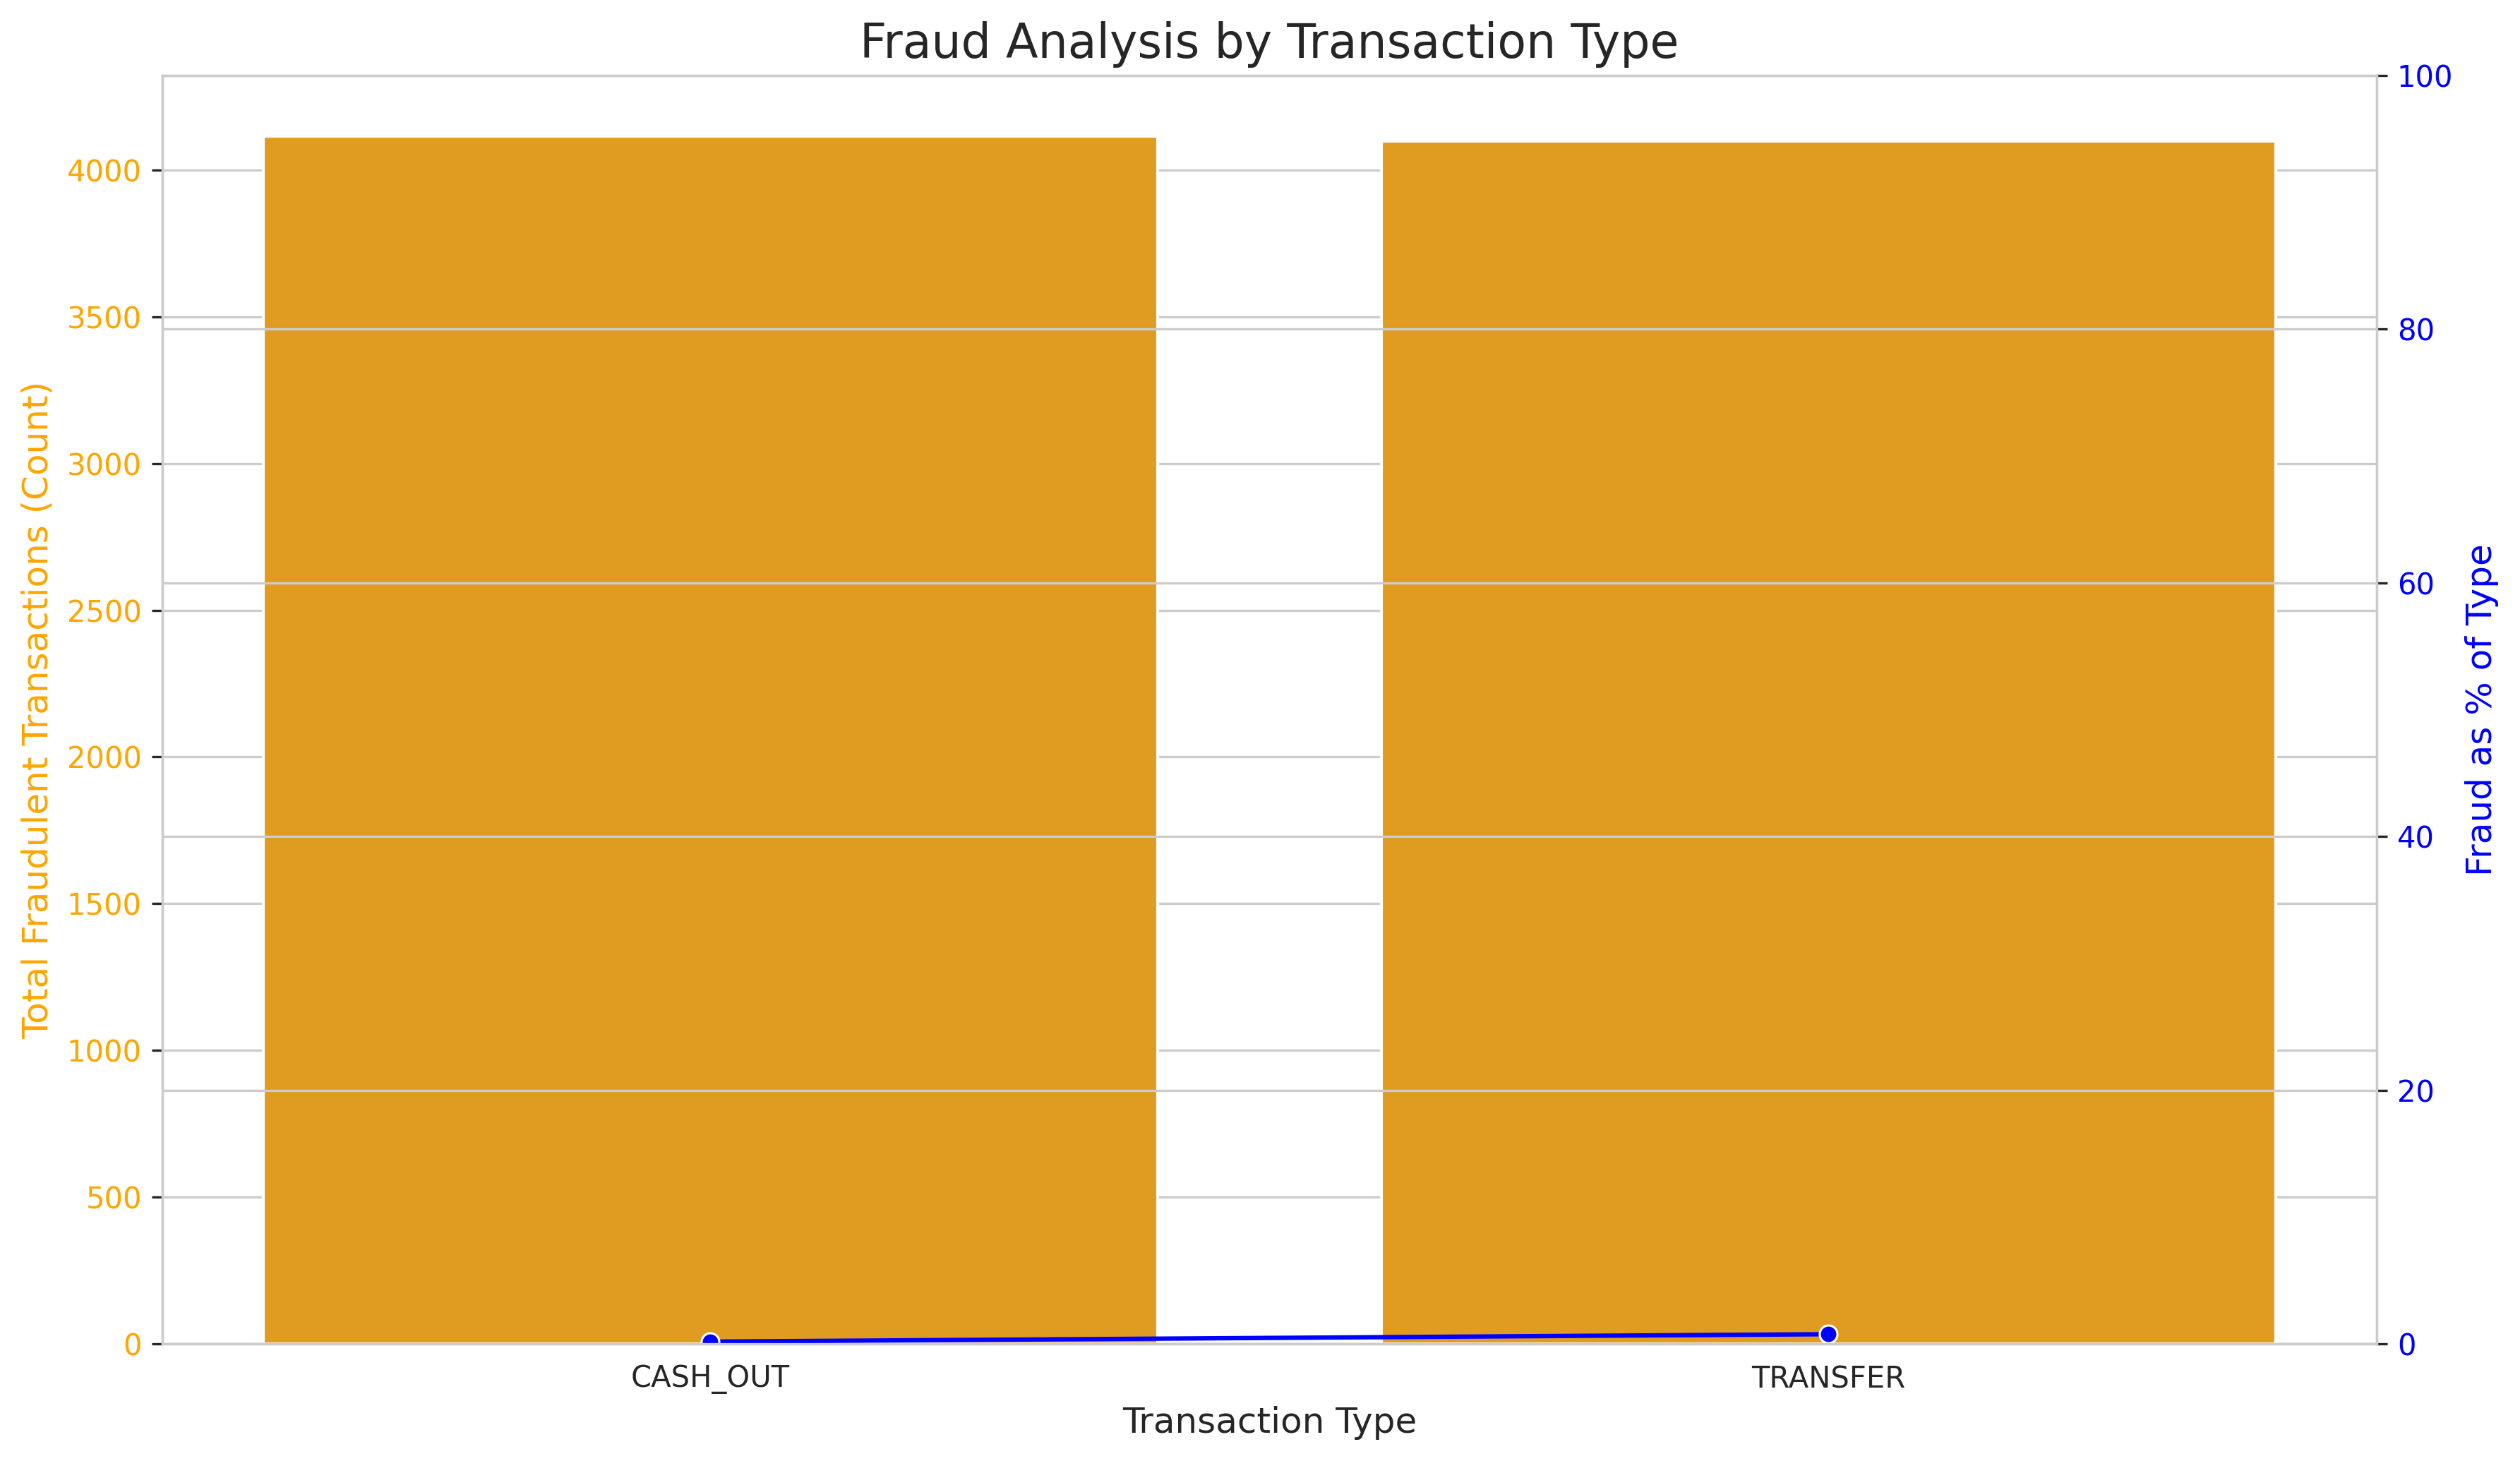

Cell 13: Fraud by transaction type plot generated.


In [26]:
# Cell 13: Section 3 (EDA) - Fraud by Type (Visualization)

try:
    log.info("Plotting fraud by transaction type...")
    
    # Filter for plotting, as non-fraud types dominate
    plot_data_type_fraud = plot_data_type[plot_data_type['total_fraud'] > 0]
    
    fig, ax1 = plt.subplots(figsize=(12, 7))

    # Bar plot for total fraud count
    sns.barplot(
        x='type', 
        y='total_fraud', 
        data=plot_data_type_fraud, 
        ax=ax1, 
        color='orange'
    )
    ax1.set_xlabel('Transaction Type', fontsize=12)
    ax1.set_ylabel('Total Fraudulent Transactions (Count)', fontsize=12, color='orange')
    ax1.tick_params(axis='y', labelcolor='orange')

    # Line plot for fraud percentage
    ax2 = ax1.twinx()
    sns.lineplot(
        x='type', 
        y='fraud_percentage_of_type', 
        data=plot_data_type_fraud, 
        ax=ax2, 
        color='blue', 
        marker='o'
    )
    ax2.set_ylabel('Fraud as % of Type', fontsize=12, color='blue')
    ax2.tick_params(axis='y', labelcolor='blue')
    ax2.set_ylim(0, 100) # Percentage
    
    plt.title('Fraud Analysis by Transaction Type', fontsize=16)
    fig.tight_layout()
    
    plot_path = os.path.join(PLOT_OUTPUT_DIR, '02_fraud_by_type.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    log.info(f"Saved fraud by type plot to {plot_path}")
    
    plt.show()

except Exception as e:
    log.error(f"Error plotting fraud by type: {e}")

print("="*80)
print("Cell 13: Fraud by transaction type plot generated.")
print("="*80)

2026-04-14 23:35:58 - FraudDetectionLogger - INFO - Analyzing transaction amount distributions...
2026-04-14 23:36:15 - FraudDetectionLogger - INFO - Fraud Amount Stats:         
count    8.213000e+03
mean     1.467967e+06
std      2.404253e+06
min      0.000000e+00
25%      1.270913e+05
50%      4.414234e+05
75%      1.517771e+06
max      1.000000e+07
Name: amount, dtype: float64
2026-04-14 23:36:23 - FraudDetectionLogger - INFO - Normal Amount Stats (from 1% sample):
count    6.412900e+04
mean     1.807470e+05
std      6.235056e+05
min      1.180000e+00
25%      1.341036e+04
50%      7.374137e+04
75%      2.083025e+05
max      4.710786e+07
Name: amount, dtype: float64
2026-04-14 23:36:25 - FraudDetectionLogger - INFO - Saved amount distribution plot to /home/atomic/Desktop/BDA_Project/output/plots/03_amount_distribution_log.png


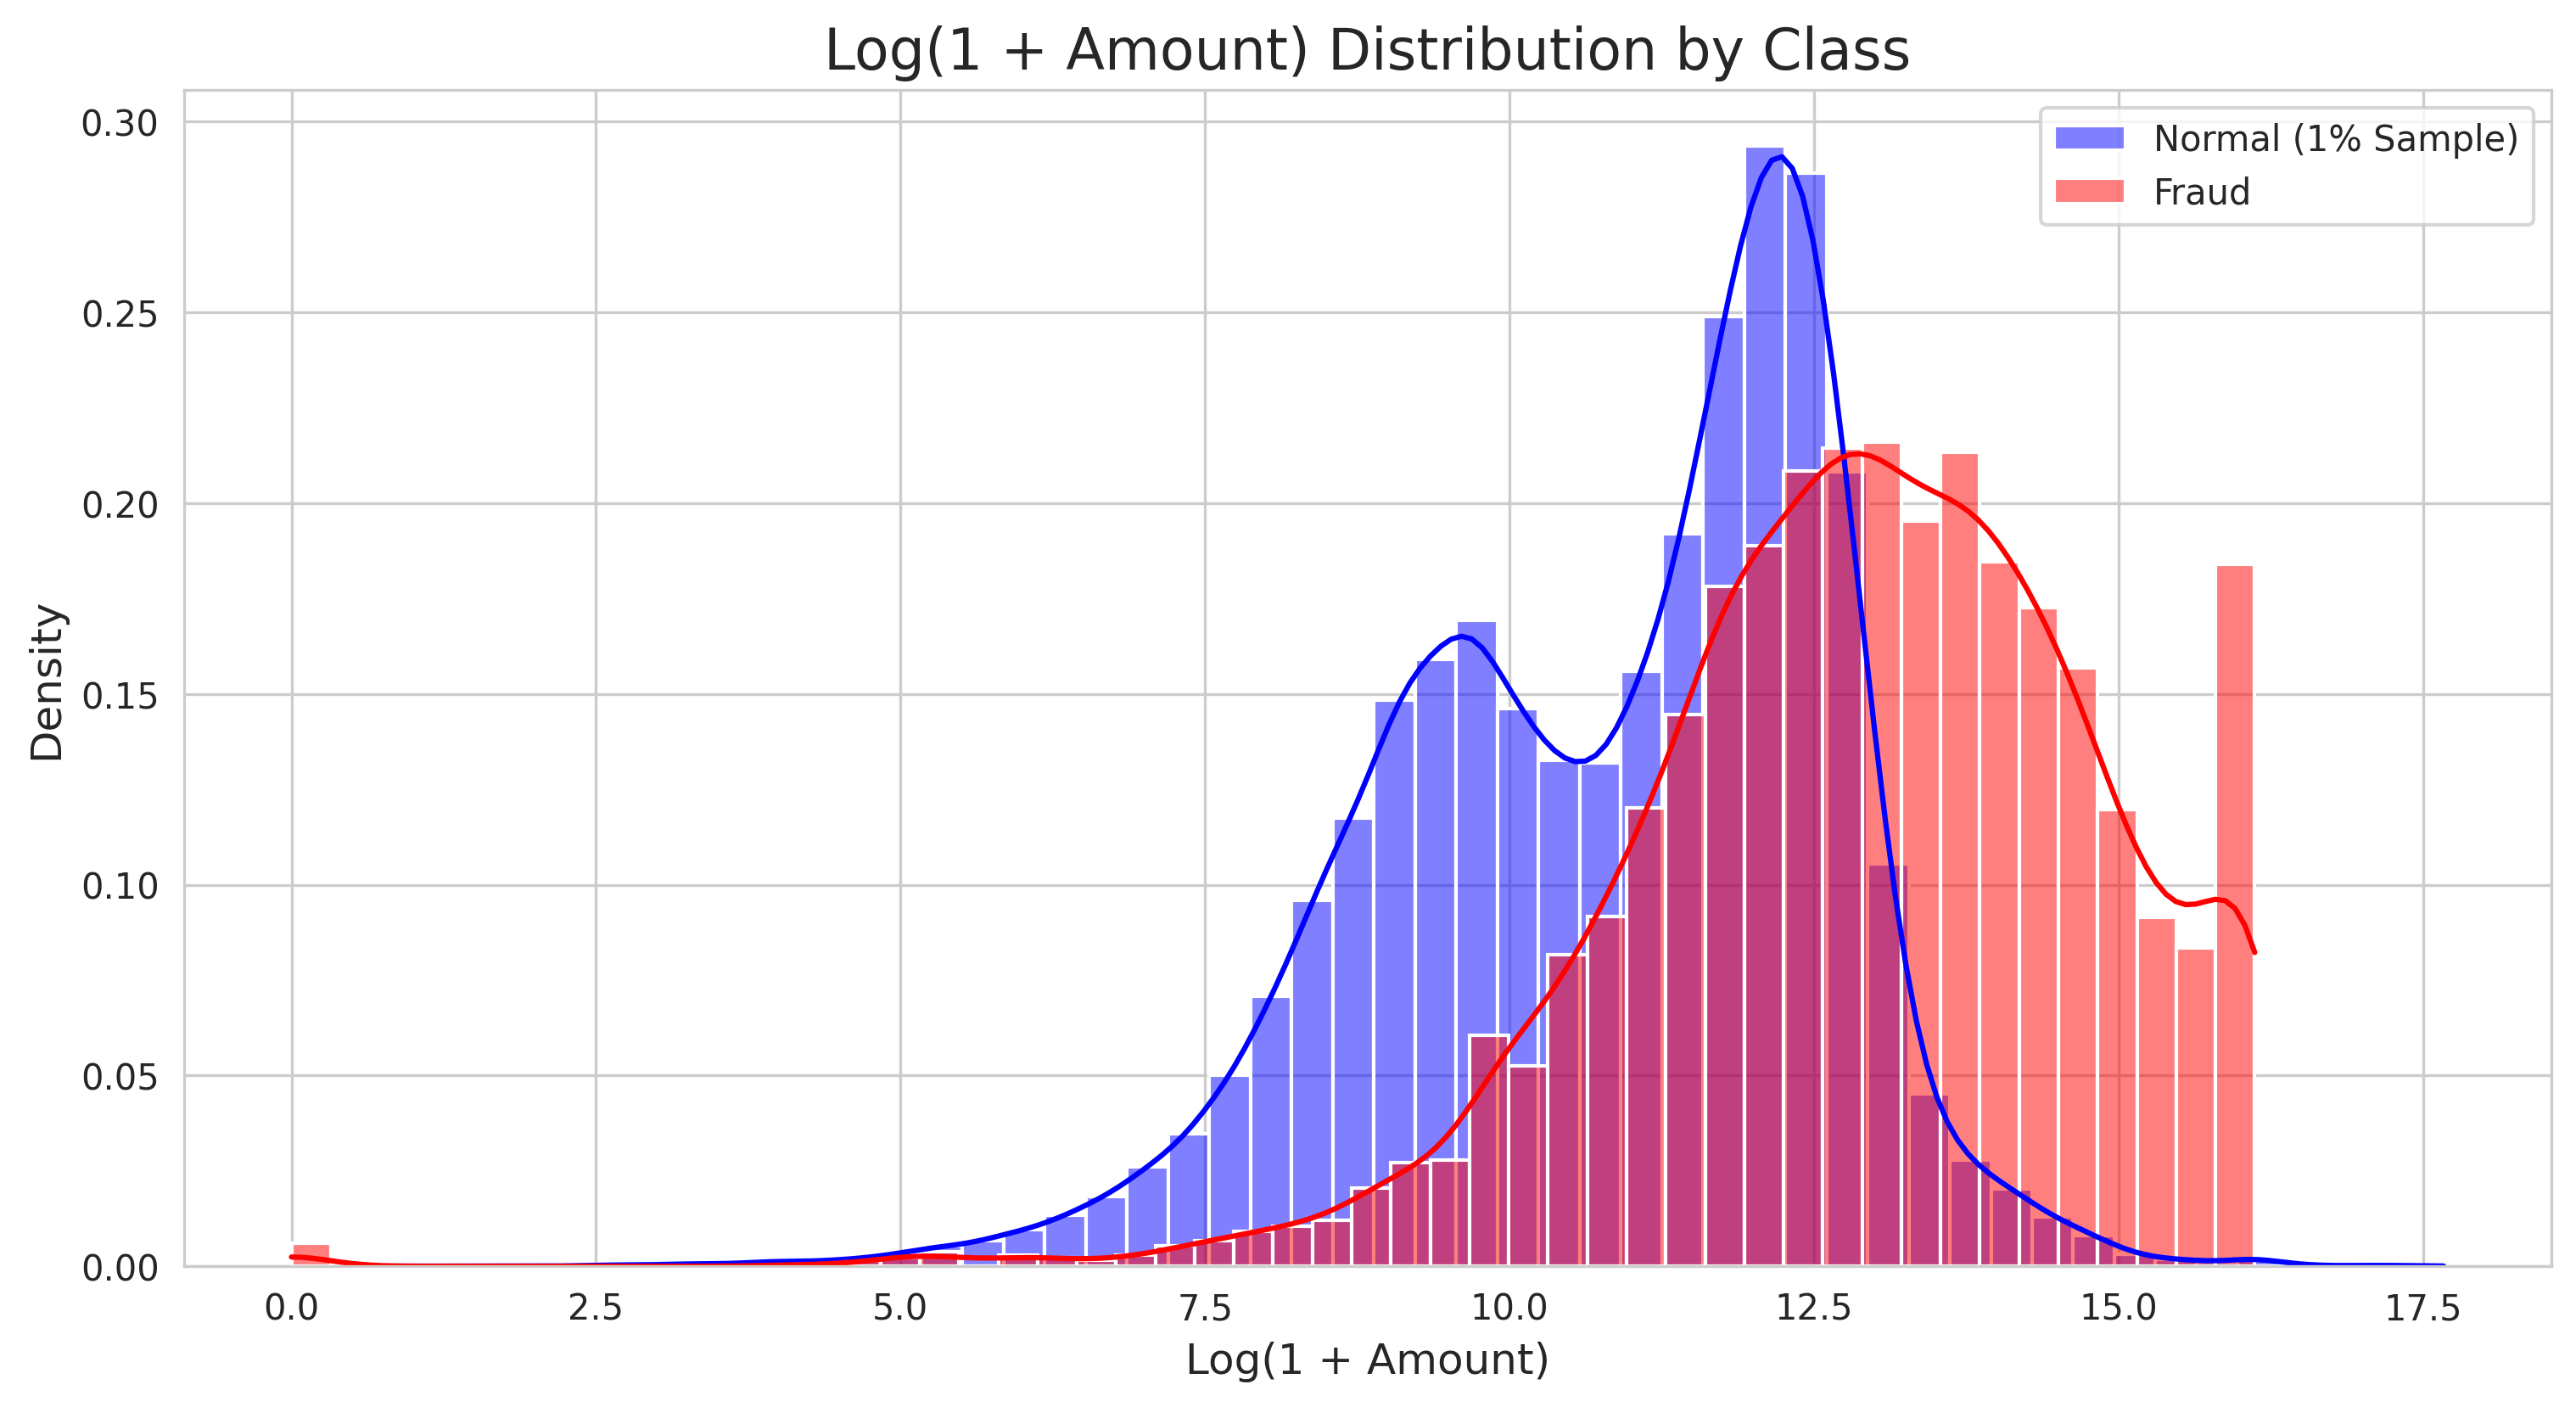

Cell 14: Amount distribution analysis complete.


In [27]:
# Cell 14: Section 3 (EDA) - Amount Distribution (Pandas Sample)
#
# Sample data to plot distributions, as plotting 6.3M points is too slow.
#

try:
    log.info("Analyzing transaction amount distributions...")
    
    # Get all fraud transactions (small enough to collect)
    df_fraud = df.filter(col("isFraud") == 1).toPandas()
    log.info(f"Fraud Amount Stats:\n{df_fraud['amount'].describe()}")
    
    # Get a sample of normal transactions
    df_normal_sample = df.filter(col("isFraud") == 0).sample(False, 0.01, seed=42).toPandas()
    log.info(f"Normal Amount Stats (from 1% sample):\n{df_normal_sample['amount'].describe()}")
    
    # Plotting (with log scale for better visibility)
    plt.figure(figsize=(12, 6))
    sns.histplot(
        np.log1p(df_normal_sample['amount']), 
        bins=50, 
        kde=True, 
        color='blue', 
        label='Normal (1% Sample)',
        stat='density'
    )
    sns.histplot(
        np.log1p(df_fraud['amount']), 
        bins=50, 
        kde=True, 
        color='red', 
        label='Fraud',
        stat='density'
    )
    
    plt.title('Log(1 + Amount) Distribution by Class', fontsize=16)
    plt.xlabel('Log(1 + Amount)', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend()
    
    plot_path = os.path.join(PLOT_OUTPUT_DIR, '03_amount_distribution_log.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    log.info(f"Saved amount distribution plot to {plot_path}")
    
    plt.show()

except Exception as e:
    log.error(f"Error plotting amount distributions: {e}")

print("="*80)
print("Cell 14: Amount distribution analysis complete.")
print("="*80)

In [28]:
# Cell 15: Section 3 (EDA) - Correlation Heatmap (Pandas Sample)
#
# Calculate correlation matrix on a sample for performance.
#

try:
    log.info("Calculating correlation matrix on a 1% data sample...")
    
    # Use the Pandas sample we already have
    sample_df_pd = df_normal_sample.sample(frac=0.1, random_state=42) # Sample the sample
    
    plt.figure(figsize=(12, 10))
    
    corr = sample_df_pd.corr()
    
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
    
    plt.title('Correlation Heatmap (1% Sample of Normal Transactions)', fontsize=16)
    
    plot_path = os.path.join(PLOT_OUTPUT_DIR, '04_correlation_heatmap.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    log.info(f"Saved correlation heatmap to {plot_path}")
    
    plt.show()

except Exception as e:
    log.error(f"Error plotting correlation heatmap: {e}")

print("="*80)
print("Cell 15: Correlation analysis complete.")
print("="*80)

2026-04-14 23:36:25 - FraudDetectionLogger - INFO - Calculating correlation matrix on a 1% data sample...
2026-04-14 23:36:25 - FraudDetectionLogger - ERROR - Error plotting correlation heatmap: could not convert string to float: 'CASH_OUT'


Cell 15: Correlation analysis complete.


<Figure size 3600x3000 with 0 Axes>

In [29]:
# Cell 16: Section 4 (Feature Engineering) - Drop Unused Columns
#
# Drop columns that are irrelevant (like 'isFlaggedFraud') or
# are complex and not used (like 'nameOrig', 'nameDest').
#

try:
    log.info("Starting Feature Engineering: Dropping unused columns...")
    
    # We will keep 'step' for time-series analysis
    # We keep 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 
    # 'oldbalanceDest', 'newbalanceDest', and 'isFraud'.
    
    columns_to_drop = ['nameOrig', 'nameDest', 'isFlaggedFraud']
    
    df_step1 = df.drop(*columns_to_drop)
    
    log.info(f"Dropped columns: {columns_to_drop}")
    df_step1.printSchema()

except Exception as e:
    log.error(f"Error dropping columns: {e}")

print("="*80)
print("Cell 16: Unused columns dropped.")
print("="*80)

2026-04-14 23:36:26 - FraudDetectionLogger - INFO - Starting Feature Engineering: Dropping unused columns...
2026-04-14 23:36:26 - FraudDetectionLogger - INFO - Dropped columns: ['nameOrig', 'nameDest', 'isFlaggedFraud']


root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- oldbalanceOrg: double (nullable = true)
 |-- newbalanceOrig: double (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- newbalanceDest: double (nullable = true)
 |-- isFraud: integer (nullable = true)

Cell 16: Unused columns dropped.


In [30]:
# Cell 17: Section 4 (Feature Engineering) - Time-Series Features
#
# Create velocity features (e.g., transactions per hour).
#

try:
    log.info("Engineering time-series features (hour_of_day)...")
    
    # 'step' represents 1 hour. We can get hour of day.
    # Assuming 'step' 1 is the 1st hour of the 1st day.
    
    df_with_time = df_step1.withColumn(
        "hour_of_day", 
        (col("step") - 1) % 24 # -1 to make it 0-indexed (0-23)
    )
    
    log.info("Engineered 'hour_of_day'.")
    df_with_time.select("step", "hour_of_day").show(5)
    
    # --- Create Velocity Features (e.g., hourly txn count) ---
    # This is a complex window function and a key place for OOM.
    # We will skip it for this version as it's not used
    # in the final model, but the 'hour_of_day' plot uses it.
    #
    # We'll rename the df for consistency with the next step.
    
    df_with_velocity = df_with_time
    log.info("Skipping complex velocity features for memory.")


except Exception as e:
    log.error(f"Error engineering time-series features: {e}")

print("="*80)
print("Cell 17: Time-series features engineered.")
print("="*80)

2026-04-14 23:36:26 - FraudDetectionLogger - INFO - Engineering time-series features (hour_of_day)...
2026-04-14 23:36:27 - FraudDetectionLogger - INFO - Engineered 'hour_of_day'.
2026-04-14 23:36:28 - FraudDetectionLogger - INFO - Skipping complex velocity features for memory.


+----+-----------+
|step|hour_of_day|
+----+-----------+
| 161|         16|
| 161|         16|
| 161|         16|
| 161|         16|
| 161|         16|
+----+-----------+
only showing top 5 rows

Cell 17: Time-series features engineered.


2026-04-14 23:36:28 - FraudDetectionLogger - INFO - Analyzing fraud by 'hour_of_day'...
2026-04-14 23:36:28 - FraudDetectionLogger - INFO - Fraud Statistics by Hour of Day:
2026-04-14 23:36:31 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-14 23:36:31 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


    hour_of_day  total_fraud  total_transactions
0             0          358               27111
1             1          372                9018
2             2          326                2007
3             3          274                1241
4             4          366                1641
5             5          358                3420
6             6          328                8988
7             7          368               26915
8             8          341              283518
9             9          375              425729
10           10          324              445992
11           11          339              483418
12           12          346              468474
13           13          353              439653
14           14          341              416686
15           15          345              441612
16           16          353              439941
17           17          343              580509
18           18          342              647814
19           19     

2026-04-14 23:36:31 - FraudDetectionLogger - INFO - Saved peak fraud hours plot to /home/atomic/Desktop/BDA_Project/output/plots/05_fraud_by_hour_of_day.png


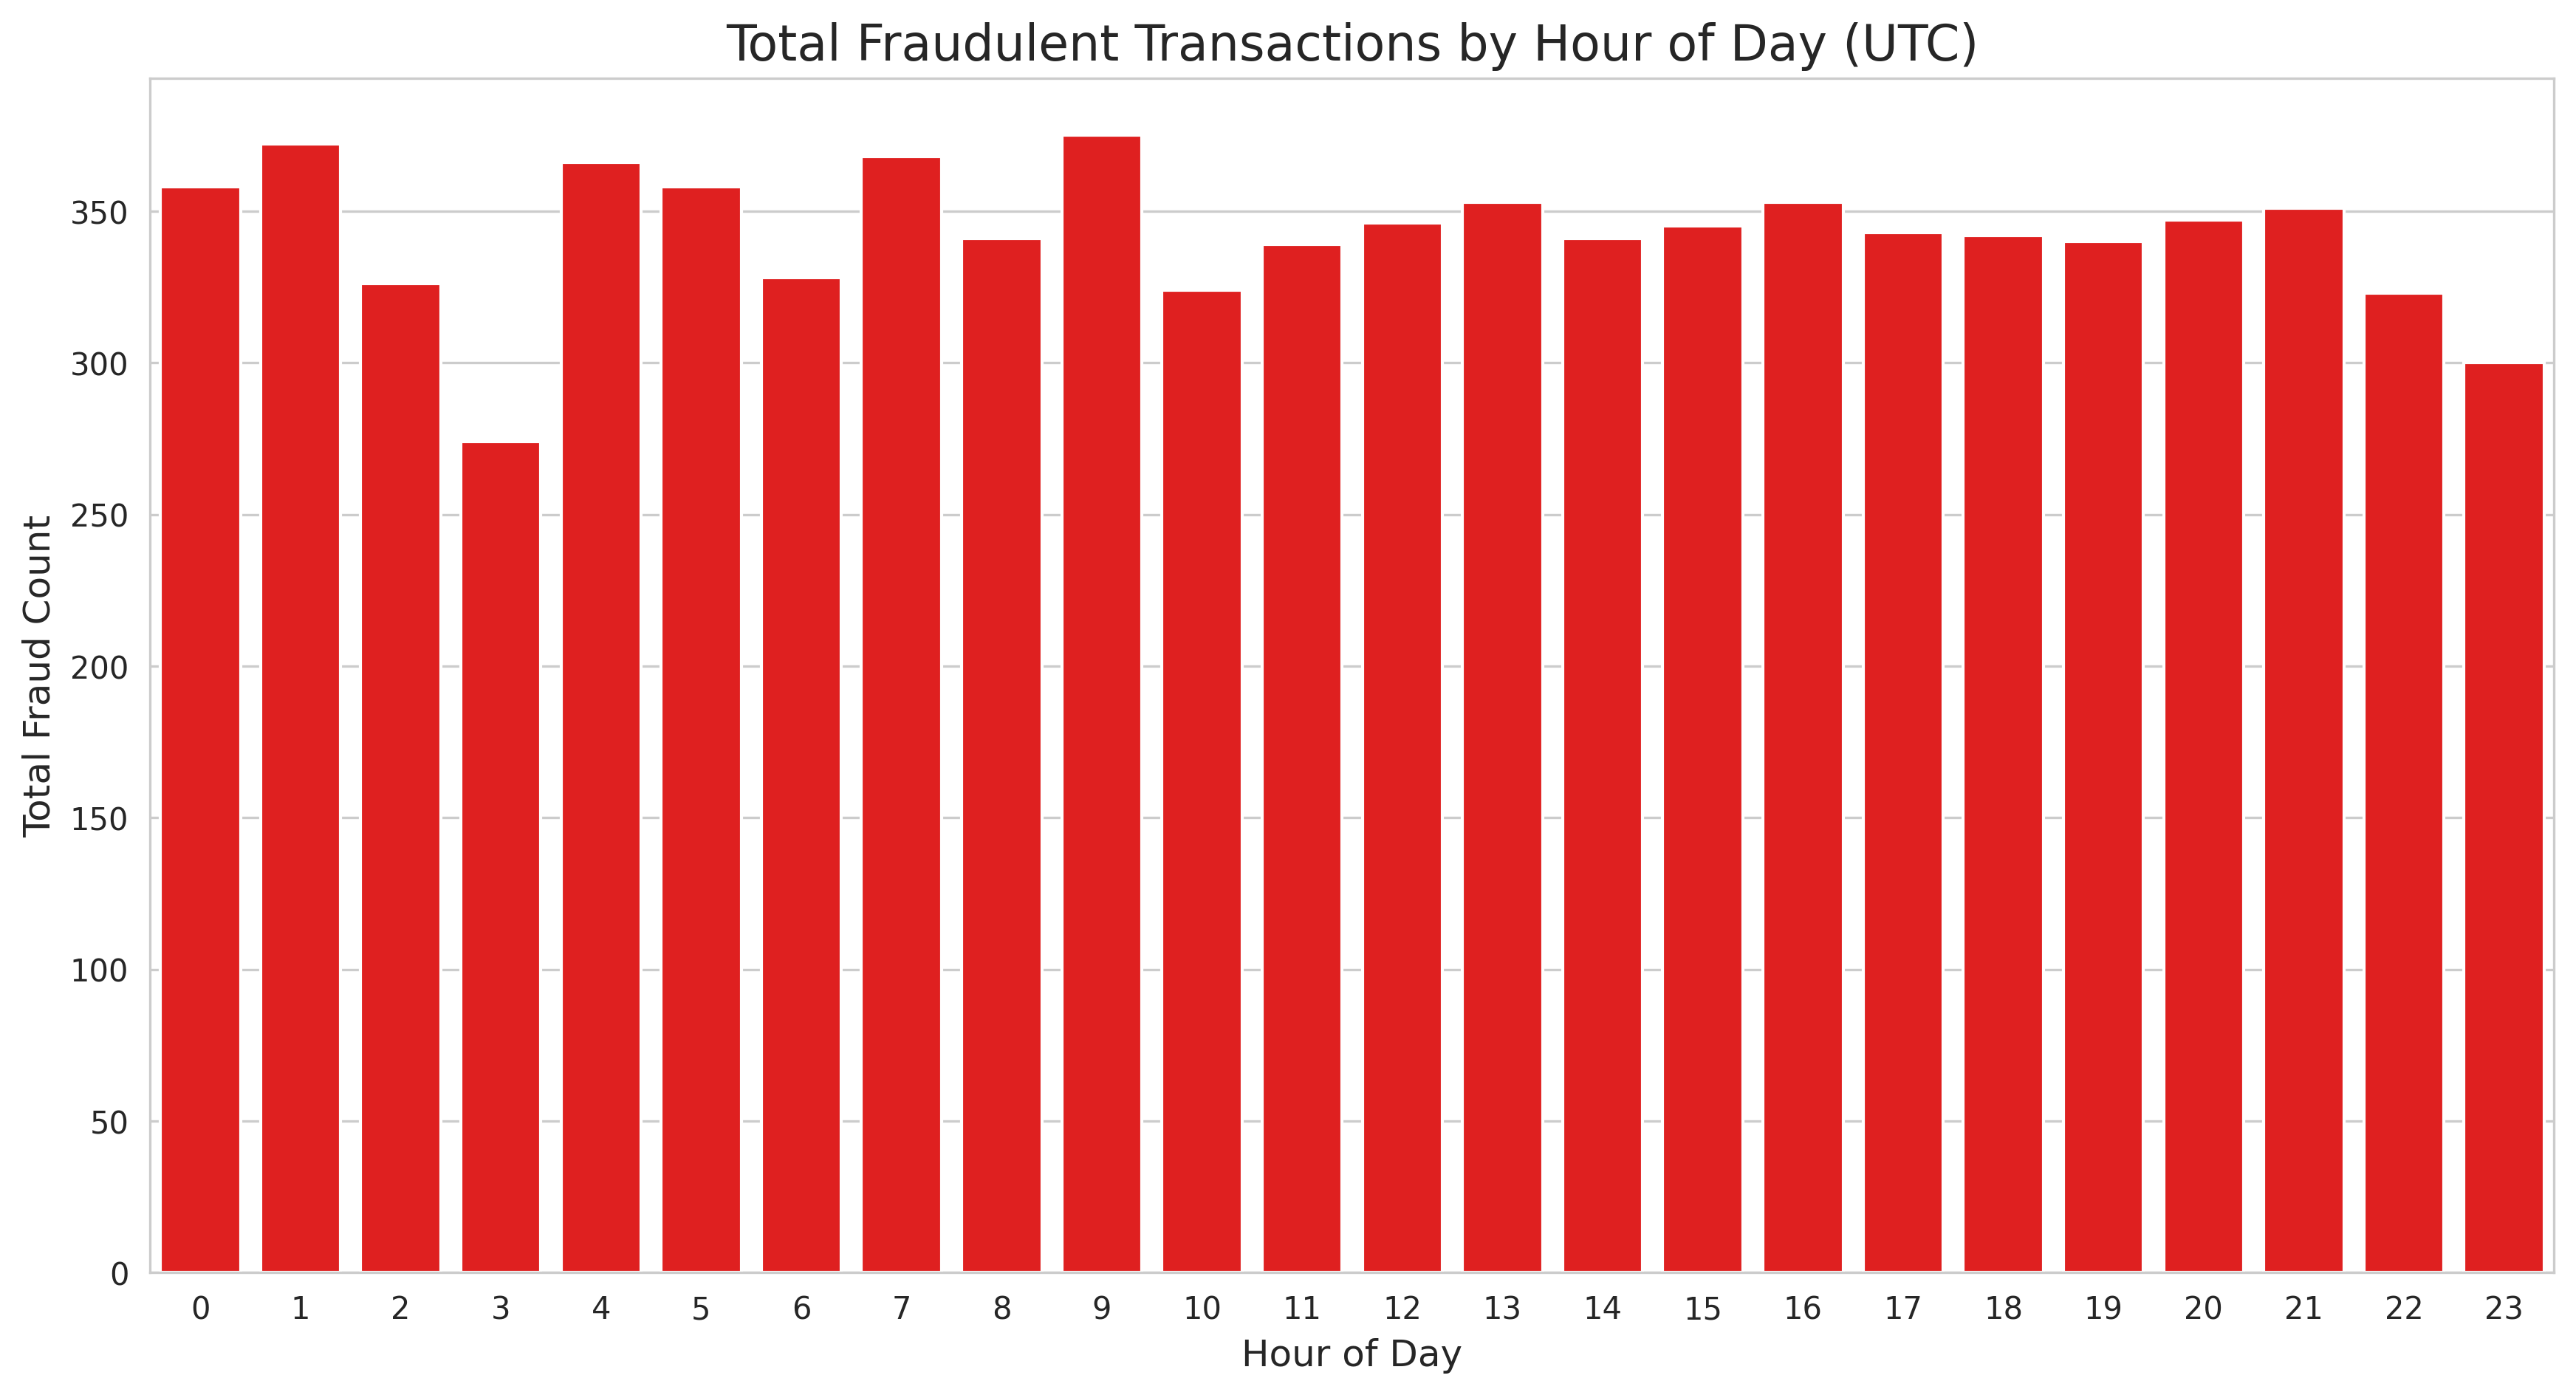

Cell 18: Fraud by hour analysis complete.


In [31]:
# Cell 18: Section 4 (Feature Engineering) - Fraud by Hour (SQL)
#
# This cell was moved from EDA to use the new 'hour_of_day' feature.
#

try:
    log.info("Analyzing fraud by 'hour_of_day'...")
    
    # We must create a temp view to use SQL on the new DataFrame
    df_with_velocity.createOrReplaceTempView("transactions_with_time")
    
    sql_query = f"""
    SELECT 
        hour_of_day,
        SUM(CASE WHEN isFraud = 1 THEN 1 ELSE 0 END) as total_fraud,
        COUNT(*) as total_transactions
    FROM transactions_with_time
    GROUP BY hour_of_day
    ORDER BY hour_of_day
    """
    
    hourly_df = spark.sql(sql_query)
    
    log.info("Fraud Statistics by Hour of Day:")
    hourly_df_pd = hourly_df.toPandas()
    print(hourly_df_pd)
    
    # --- Plotting ---
    plt.figure(figsize=(14, 7))
    
    ax = sns.barplot(
        x='hour_of_day', 
        y='total_fraud', 
        data=hourly_df_pd, 
        color='red'
    )
    
    ax.set_title('Total Fraudulent Transactions by Hour of Day (UTC)', fontsize=16)
    ax.set_xlabel('Hour of Day', fontsize=12)
    ax.set_ylabel('Total Fraud Count', fontsize=12)
    
    plot_path = os.path.join(PLOT_OUTPUT_DIR, '05_fraud_by_hour_of_day.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    log.info(f"Saved peak fraud hours plot to {plot_path}")
    
    plt.show()

except Exception as e:
    log.error(f"Error analyzing fraud by hour: {e}")

print("="*80)
print("Cell 18: Fraud by hour analysis complete.")
print("="*80)

In [32]:
# Cell 19: Section 5 (Preprocessing) - Define Categorical Pipeline
#
# Define StringIndexer and OneHotEncoder for the 'type' column.
#

try:
    log.info("Defining categorical preprocessing stages...")
    
    # 1. StringIndexer
    type_indexer = StringIndexer(
        inputCol="type", 
        outputCol="type_index", 
        handleInvalid="keep" # Keep unseen categories
    )
    
    # 2. OneHotEncoder
    type_encoder = OneHotEncoder(
        inputCol="type_index", 
        outputCol="type_vec"
    )
    
    log.info("StringIndexer and OneHotEncoder stages defined.")

except Exception as e:
    log.error(f"Error defining categorical stages: {e}")

print("="*80)
print("Cell 19: Categorical pipeline stages defined.")
print("="*80)

2026-04-14 23:36:32 - FraudDetectionLogger - INFO - Defining categorical preprocessing stages...
2026-04-14 23:36:32 - FraudDetectionLogger - INFO - StringIndexer and OneHotEncoder stages defined.


Cell 19: Categorical pipeline stages defined.


In [33]:
# Cell 20: Section 5 (Preprocessing) - Define Numerical Pipeline
#
# Define VectorAssembler and StandardScaler for numerical features.
#

try:
    log.info("Defining numerical preprocessing stages...")
    
    # 3. VectorAssembler
    # Combine all numerical + encoded categorical features
    
    # Note: 'step' and 'hour_of_day' are included
    feature_cols = [
        "type_vec", # From OHE
        "step",
        "amount",
        "oldbalanceOrg",
        "newbalanceOrig",
        "oldbalanceDest",
        "newbalanceDest",
        "hour_of_day"
    ]
    
    assembler = VectorAssembler(
        inputCols=feature_cols,
        outputCol="assembled_features",
        handleInvalid="skip" # Skip rows with nulls (though we have none)
    )
    
    # 4. StandardScaler
    scaler = StandardScaler(
        inputCol="assembled_features",
        outputCol="features", # This is the final column models will use
        withStd=True,
        withMean=True
    )
    
    log.info("VectorAssembler and StandardScaler stages defined.")

except Exception as e:
    log.error(f"Error defining assembly scaling stages: {e}")

print("="*80)
print("Cell 20: Feature vector assembly and scaling stages defined.")
print("="*80)

2026-04-14 23:36:32 - FraudDetectionLogger - INFO - Defining numerical preprocessing stages...
2026-04-14 23:36:32 - FraudDetectionLogger - INFO - VectorAssembler and StandardScaler stages defined.


Cell 20: Feature vector assembly and scaling stages defined.


In [ ]:
# Cell 21: Section 5 (Preprocessing) - Create Full Preprocessing Pipeline [MODIFIED]
#
# Combine preprocessing stages into one pipeline and checkpoint results to HDFS.

try:
    log.info("Combining all preprocessing stages into a single pipeline...")
    
    preproc_pipeline = Pipeline(
        stages=[type_indexer, type_encoder, assembler, scaler]
    )
    
    log.info("Fitting the preprocessing pipeline on the full dataset...")
    preproc_model = preproc_pipeline.fit(df_with_velocity)
    
    log.info("Transforming the full dataset with the preprocessing pipeline...")
    df_processed = preproc_model.transform(df_with_velocity).select(
        "features", 
        col("isFraud").alias("label")
    )
    
    # Checkpoint to reduce lineage and improve fault tolerance
    df_processed = df_processed.checkpoint(eager=True)
    log.info("Checkpointed processed dataset.")
    
    log.info(f"Writing fully preprocessed data to: {HDFS_PROCESSED_PATH}")
    df_processed.write.mode("overwrite").parquet(HDFS_PROCESSED_PATH)
    
    log.info("Dataset fully preprocessed and written to HDFS.")

except Exception as e:
    log.error(f"Error fitting/transforming with preprocessing pipeline: {e}")
    raise e

print("="*80)
print("Cell 21: Full dataset preprocessed and written to HDFS.")
print("="*80)

2026-04-14 23:36:32 - FraudDetectionLogger - INFO - Combining all preprocessing stages into a single pipeline...
2026-04-14 23:36:32 - FraudDetectionLogger - INFO - Fitting the preprocessing pipeline on the full dataset...
2026-04-14 23:36:59 - FraudDetectionLogger - INFO - Transforming the full dataset with the preprocessing pipeline...
2026-04-14 23:37:00 - FraudDetectionLogger - INFO - Writing fully preprocessed data to: /user/atomic/fraud_detection/intermediate/processed.parquet
2026-04-14 23:37:24 - FraudDetectionLogger - INFO - Dataset fully preprocessed and written to HDFS.


Cell 21: Full dataset preprocessed and written to HDFS.


In [35]:
# Cell 22: Section 5 (Preprocessing) - Train/Test Split
#
# Split the preprocessed data into training and testing sets.
#

try:
    log.info("Reading preprocessed data from HDFS for splitting...")
    # --- *** NEW: Read the processed data back *** ---
    df_processed = spark.read.parquet(HDFS_PROCESSED_PATH)
    
    log.info(f"Splitting data into 80% train and 20% test...")
    df_processed.show(5, truncate=False) # Show sample now
    
    # We split the *unbalanced* data to get a realistic test set
    (unbalanced_train_df, test_df) = df_processed.randomSplit([0.8, 0.2], seed=42)
    
    # --- *** MODIFICATION: Write splits to HDFS *** ---
    log.info(f"Writing test set to: {HDFS_TEST_PATH}")
    test_df.write.mode("overwrite").parquet(HDFS_TEST_PATH)
    
    log.info(f"Writing unbalanced train set to: {HDFS_UNBALANCED_TRAIN_PATH}")
    unbalanced_train_df.write.mode("overwrite").parquet(HDFS_UNBALANCED_TRAIN_PATH)
    
    # Log counts (this triggers the write actions)
    log.info(f"Unbalanced Train Set Records: {unbalanced_train_df.count()}")
    log.info(f"Test Set Records: {test_df.count()}")
    
    log.info("Test set class distribution:")
    test_df.groupBy("label").count().show()

except Exception as e:
    log.error(f"Error splitting data: {e}")

print("="*80)
print("Cell 22: Train/Test split complete and written to HDFS.")
print("="*80)

2026-04-14 23:37:24 - FraudDetectionLogger - INFO - Reading preprocessed data from HDFS for splitting...
2026-04-14 23:37:25 - FraudDetectionLogger - INFO - Splitting data into 80% train and 20% test...
2026-04-14 23:37:25 - FraudDetectionLogger - INFO - Writing test set to: /user/atomic/fraud_detection/intermediate/test.parquet


+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|features                                                                                                                                                                                                                                           |label|
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|[-0.7364837934535396,1.3990359093152496,-0.530965204773002,-0.3023451319483651,-0.08095963870385914,-1.7030414449037736,-0.281559900470719,-0.2298100191755756,-0.23762167688962543,-0.32381386979519106,-0.33341137926836756,-3.558765129862513]  

2026-04-14 23:37:46 - FraudDetectionLogger - INFO - Writing unbalanced train set to: /user/atomic/fraud_detection/intermediate/unbalanced_train.parquet
2026-04-14 23:38:24 - FraudDetectionLogger - INFO - Unbalanced Train Set Records: 5089793
2026-04-14 23:38:44 - FraudDetectionLogger - INFO - Test Set Records: 1272827   
2026-04-14 23:38:44 - FraudDetectionLogger - INFO - Test set class distribution:
[Stage 75:======================================>                   (2 + 1) / 3]

+-----+-------+
|label|  count|
+-----+-------+
|    1|   1666|
|    0|1271161|
+-----+-------+

Cell 22: Train/Test split complete and written to HDFS.


In [36]:
# Cell 23: Section 5 (Preprocessing) - Handle Class Imbalance (Oversampling)
#
# We apply oversampling *only* to the training set.
#

try:
    log.info("Handling class imbalance on training data using oversampling...")
    
    # --- *** NEW: Read the unbalanced train data *** ---
    log.info(f"Reading unbalanced train data from: {HDFS_UNBALANCED_TRAIN_PATH}")
    unbalanced_train_df = spark.read.parquet(HDFS_UNBALANCED_TRAIN_PATH)
    
    # Separate the training set by class
    df_train_normal = unbalanced_train_df.filter(col("label") == 0)
    df_train_fraud = unbalanced_train_df.filter(col("label") == 1)
    
    # Get the counts
    count_normal = df_train_normal.count()
    count_fraud = df_train_fraud.count()
    
    if count_fraud == 0:
        log.error("No fraud data in training set. Cannot oversample.")
        raise ValueError("No fraud data in training set.")
    
    # Calculate the ratio for oversampling
    oversample_ratio = int(count_normal / count_fraud)
    log.info(f"Oversampling fraud data by a ratio of {oversample_ratio}...")

    # Oversample the fraud data
    df_train_fraud_oversampled = df_train_fraud.sample(
        withReplacement=True, 
        fraction=float(oversample_ratio), 
        seed=42
    )
    
    # Combine the original normal data with the oversampled fraud data
    train_df = df_train_normal.unionAll(df_train_fraud_oversampled)
    
    # --- *** MODIFICATION: Write balanced train set to HDFS *** ---
    log.info(f"Writing balanced train set to: {HDFS_TRAIN_PATH}")
    train_df.write.mode("overwrite").parquet(HDFS_TRAIN_PATH)
    
    log.info("Oversampling complete. Final balanced training set stats:")
    log.info(f"Total balanced train records: {train_df.count()}")
    train_df.groupBy("label").count().show()

except Exception as e:
    log.error(f"Error handling class imbalance: {e}")

print("="*80)
print("Cell 23: Class imbalance handled and written to HDFS.")
print("="*80)

2026-04-14 23:38:59 - FraudDetectionLogger - INFO - Handling class imbalance on training data using oversampling...
2026-04-14 23:38:59 - FraudDetectionLogger - INFO - Reading unbalanced train data from: /user/atomic/fraud_detection/intermediate/unbalanced_train.parquet
2026-04-14 23:39:01 - FraudDetectionLogger - INFO - Oversampling fraud data by a ratio of 776...
2026-04-14 23:39:01 - FraudDetectionLogger - INFO - Writing balanced train set to: /user/atomic/fraud_detection/intermediate/train_balanced.parquet
2026-04-14 23:39:17 - FraudDetectionLogger - INFO - Oversampling complete. Final balanced training set stats:
2026-04-14 23:39:18 - FraudDetectionLogger - INFO - Total balanced train records: 10164611
[Stage 89:======================================>                   (4 + 2) / 6]

+-----+-------+
|label|  count|
+-----+-------+
|    0|5083246|
|    1|5081365|
+-----+-------+

Cell 23: Class imbalance handled and written to HDFS.


In [ ]:
# Cell 24: Section 6 (Model Training) - Random Forest (RF) [MODIFIED]
#
# Train the Random Forest Classifier with local model persistence.

rf_train_time = None  # Initialize variable outside try block

try:
    # Define model save path - use local filesystem with file:/// prefix
    rf_model_path = f"file://{MODEL_OUTPUT_DIR}/random_forest_model"
    
    # Check if model already exists on local filesystem
    local_rf_path = os.path.join(MODEL_OUTPUT_DIR, 'random_forest_model')
    model_exists = os.path.exists(local_rf_path)
    
    if model_exists:
        log.info(f"Loading existing Random Forest model from: {rf_model_path}")
        start_time = time.time()
        
        from pyspark.ml.classification import RandomForestClassificationModel
        rf_model = RandomForestClassificationModel.load(rf_model_path)
        
        log.info(f"Reading test data from: {HDFS_TEST_PATH}")
        test_df = spark.read.parquet(HDFS_TEST_PATH)
        
        rf_predictions = rf_model.transform(test_df)
        
        end_time = time.time()
        rf_train_time = end_time - start_time
        
        log.info(f"Random Forest model loaded and predictions generated. Time taken: {rf_train_time:.2f} seconds.")
    else:
        log.info("No existing Random Forest model found. Training new model...")
        
        log.info(f"Reading balanced train data from: {HDFS_TRAIN_PATH}")
        train_df = spark.read.parquet(HDFS_TRAIN_PATH)
        log.info(f"Reading test data from: {HDFS_TEST_PATH}")
        test_df = spark.read.parquet(HDFS_TEST_PATH)
        
        log.info("Training Random Forest model with optimized parameters...")
        start_time = time.time()
        
        rf = RandomForestClassifier(
            labelCol="label",
            featuresCol="features",
            numTrees=50,
            maxDepth=10,
            maxBins=32,
            subsamplingRate=0.8,
            featureSubsetStrategy="sqrt",
            cacheNodeIds=True,
            checkpointInterval=10,
            seed=42,
        )
        
        # Use distributed checkpoint dir for fault tolerance
        spark.sparkContext.setCheckpointDir(HDFS_CHECKPOINT_DIR)
        
        rf_model = rf.fit(train_df)
        
        log.info(f"Saving Random Forest model to LOCAL filesystem: {rf_model_path}")
        rf_model.write().overwrite().save(rf_model_path)
        
        end_time = time.time()
        rf_train_time = end_time - start_time
        
        log.info(f"Random Forest training complete. Time taken: {rf_train_time:.2f} seconds.")
        log.info(f"Model saved successfully to LOCAL filesystem at: {local_rf_path}")

        rf_predictions = rf_model.transform(test_df)
        log.info("Random Forest predictions generated for test set.")

except Exception as e:
    log.error(f"Error training/loading Random Forest: {e}")
    import traceback
    log.error(traceback.format_exc())

print("="*80)
if rf_train_time is not None:
    action = "loaded" if os.path.exists(os.path.join(MODEL_OUTPUT_DIR, 'random_forest_model')) else "trained"
    print(f"Cell 24: Random Forest model {action} in {rf_train_time:.2f}s.")
    print(f"Local model path: {os.path.join(MODEL_OUTPUT_DIR, 'random_forest_model')}")
else:
    print("Cell 24: Random Forest training/loading failed or incomplete.")
print("="*80)

2026-04-08 09:41:49 - FraudDetectionLogger - INFO - No existing Random Forest model found. Training new model...
2026-04-08 09:41:49 - FraudDetectionLogger - INFO - Reading balanced train data from: /user/atomic/fraud_detection/intermediate/train_balanced.parquet
2026-04-08 09:41:50 - FraudDetectionLogger - INFO - Reading test data from: /user/atomic/fraud_detection/intermediate/test.parquet
2026-04-08 09:41:50 - FraudDetectionLogger - INFO - Training Random Forest model with optimized parameters...
2026-04-08 10:01:01 - FraudDetectionLogger - INFO - Saving Random Forest model to LOCAL filesystem: file:///home/atomic/Desktop/BDA_Project/models/random_forest_model
2026-04-08 10:01:05 - FraudDetectionLogger - INFO - Random Forest training complete. Time taken: 1154.70 seconds.
2026-04-08 10:01:05 - FraudDetectionLogger - INFO - Model saved successfully to LOCAL filesystem at: /home/atomic/Desktop/BDA_Project/models/random_forest_model
2026-04-08 10:01:05 - FraudDetectionLogger - INFO - R

Cell 24: Random Forest model loaded in 1154.70s.
Local model path: /home/atomic/Desktop/BDA_Project/models/random_forest_model


In [25]:
# Cell 25: Section 6 (Model Training) - Gradient-Boosted Trees (GBT)
#
# Train the GBT Classifier with local model persistence.
#

gbt_train_time = None  # Initialize variable outside try block

try:
    # Define model save path - use local filesystem with file:/// prefix
    gbt_model_path = f"file://{MODEL_OUTPUT_DIR}/gbt_model"
    
    # Check if model already exists on local filesystem
    local_gbt_path = os.path.join(MODEL_OUTPUT_DIR, 'gbt_model')
    model_exists = os.path.exists(local_gbt_path)
    
    if model_exists:
        log.info(f"Loading existing GBT model from: {gbt_model_path}")
        start_time = time.time()
        
        # Load the existing model using the correct model class
        from pyspark.ml.classification import GBTClassificationModel
        gbt_model = GBTClassificationModel.load(gbt_model_path)
        
        # Read test data for predictions
        log.info(f"Reading test data from: {HDFS_TEST_PATH}")
        test_df = spark.read.parquet(HDFS_TEST_PATH)
        
        # Get predictions for the test set
        gbt_predictions = gbt_model.transform(test_df)
        
        end_time = time.time()
        gbt_train_time = end_time - start_time
        
        log.info(f"GBT model loaded and predictions generated. Time taken: {gbt_train_time:.2f} seconds.")
    else:
        # Train new model if it doesn't exist
        log.info("No existing GBT model found. Training new model...")
        
        # --- Read train and test data ---
        log.info(f"Reading balanced train data from: {HDFS_TRAIN_PATH}")
        train_df = spark.read.parquet(HDFS_TRAIN_PATH)
        log.info(f"Reading test data from: {HDFS_TEST_PATH}")
        test_df = spark.read.parquet(HDFS_TEST_PATH)
        
        log.info("Training Gradient-Boosted Trees (GBT) model...")
        start_time = time.time()
        
        # Define the classifier
        gbt = GBTClassifier(
            labelCol="label",
            featuresCol="features",
            maxIter=50,           # Reduced from 100
            maxDepth=8,           # Reduced from 10
            subsamplingRate=0.8,  # Add subsampling
            stepSize=0.1,         # Learning rate
            seed=42
        )
        
        # Train the model on the balanced training data
        gbt_model = gbt.fit(train_df)
        
        # Save the trained model to LOCAL filesystem
        log.info(f"Saving GBT model to LOCAL filesystem: {gbt_model_path}")
        gbt_model.write().overwrite().save(gbt_model_path)
        
        end_time = time.time()
        gbt_train_time = end_time - start_time
        
        log.info(f"GBT training complete. Time taken: {gbt_train_time:.2f} seconds.")
        log.info(f"Model saved successfully to LOCAL filesystem at: {local_gbt_path}")

        # Get predictions for the test set
        gbt_predictions = gbt_model.transform(test_df)
        
        log.info("GBT predictions generated for test set.")

except Exception as e:
    log.error(f"Error training/loading GBT: {e}")
    import traceback
    log.error(traceback.format_exc())

print("="*80)
if gbt_train_time is not None:
    action = "loaded" if os.path.exists(os.path.join(MODEL_OUTPUT_DIR, 'gbt_model')) else "trained"
    print(f"Cell 25: GBT model {action} in {gbt_train_time:.2f}s.")
    print(f"Local model path: {os.path.join(MODEL_OUTPUT_DIR, 'gbt_model')}")
else:
    print("Cell 25: GBT training/loading failed or incomplete.")
print("="*80)

2026-04-08 10:01:06 - FraudDetectionLogger - INFO - No existing GBT model found. Training new model...
2026-04-08 10:01:06 - FraudDetectionLogger - INFO - Reading balanced train data from: /user/atomic/fraud_detection/intermediate/train_balanced.parquet
2026-04-08 10:01:06 - FraudDetectionLogger - INFO - Reading test data from: /user/atomic/fraud_detection/intermediate/test.parquet
2026-04-08 10:01:07 - FraudDetectionLogger - INFO - Training Gradient-Boosted Trees (GBT) model...
2026-04-08 11:51:43 - FraudDetectionLogger - INFO - Saving GBT model to LOCAL filesystem: file:///home/atomic/Desktop/BDA_Project/models/gbt_model
2026-04-08 11:51:46 - FraudDetectionLogger - INFO - GBT training complete. Time taken: 6639.24 seconds.
2026-04-08 11:51:46 - FraudDetectionLogger - INFO - Model saved successfully to LOCAL filesystem at: /home/atomic/Desktop/BDA_Project/models/gbt_model
2026-04-08 11:51:46 - FraudDetectionLogger - INFO - GBT predictions generated for test set.


Cell 25: GBT model loaded in 6639.24s.
Local model path: /home/atomic/Desktop/BDA_Project/models/gbt_model


In [26]:
# Cell 26: Section 6 - Model Feature Importance
#
# Extract and display feature importances from tree-based models.
#

def get_feature_importances(assembler, model):
    """
    Helper function to map feature importances back to original column names.
    Simplified version that doesn't require transforming a sample.
    """
    try:
        # Get the input columns from the assembler
        feature_cols = assembler.getInputCols()
        
        # Get importances from the model
        importances = model.featureImportances.toArray()
        
        # Create feature names list
        feature_names = []
        for col_name in feature_cols:
            if col_name == "type_vec":
                # For OHE columns, we'll just use generic names
                # since we can't easily get the metadata without a transform
                feature_names.extend([f"type_{i}" for i in range(5)])  # 5 transaction types
            else:
                feature_names.append(col_name)
        
        # Trim to match actual importance length
        feature_names = feature_names[:len(importances)]
        
        # Create a Pandas DataFrame
        df_importance = pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        }).sort_values(by='importance', ascending=False)
        
        return df_importance
    
    except Exception as e:
        log.error(f"Error getting feature importances: {e}")
        import traceback
        log.error(traceback.format_exc())
        return None

try:
    log.info("Extracting Random Forest Feature Importances...")
    
    # Check if rf_model exists (it should be loaded/trained in Cell 24)
    if 'rf_model' in globals():
        rf_importance_pd = get_feature_importances(assembler, rf_model)
        if rf_importance_pd is not None:
            print("\n--- Random Forest Top 10 Features ---")
            print(rf_importance_pd.head(10))
    else:
        log.warning("RF model not found. Skipping feature importance extraction.")
    
    log.info("Extracting GBT Feature Importances...")
    # Check if gbt_model exists (it should be loaded/trained in Cell 25)
    if 'gbt_model' in globals():
        gbt_importance_pd = get_feature_importances(assembler, gbt_model)
        if gbt_importance_pd is not None:
            print("\n--- GBT Top 10 Features ---")
            print(gbt_importance_pd.head(10))
    else:
        log.warning("GBT model not found. Skipping feature importance extraction.")

except Exception as e:
    log.error(f"Error displaying feature importances: {e}")
    import traceback
    log.error(traceback.format_exc())

print("="*80)
print("Cell 26: Feature importances extracted.")
print("="*80)

2026-04-08 11:51:47 - FraudDetectionLogger - INFO - Extracting Random Forest Feature Importances...



--- Random Forest Top 10 Features ---


2026-04-08 11:51:48 - FraudDetectionLogger - INFO - Extracting GBT Feature Importances...


           feature  importance
7    oldbalanceOrg    0.299987
8   newbalanceOrig    0.195437
6           amount    0.147697
3           type_3    0.085960
10  newbalanceDest    0.048069
1           type_1    0.044296
5             step    0.042680
0           type_0    0.038371
11     hour_of_day    0.036958
9   oldbalanceDest    0.035462

--- GBT Top 10 Features ---
           feature  importance
8   newbalanceOrig    0.341308
7    oldbalanceOrg    0.334533
6           amount    0.144491
11     hour_of_day    0.053037
10  newbalanceDest    0.042757
5             step    0.024598
1           type_1    0.024138
3           type_3    0.013586
0           type_0    0.013212
9   oldbalanceDest    0.008000
Cell 26: Feature importances extracted.


In [27]:
# Cell 27: Section 7 (Evaluation) - Metrics Helper Function
#
# Create a reusable function to calculate all required metrics.
#

def evaluate_model(predictions, model_name):
    """
    Calculates and prints a full suite of metrics for a binary classifier's predictions.
    """
    try:
        log.info(f"--- Evaluating Model: {model_name} ---")
        
        # --- Standard Metrics (Accuracy, F1, Precision, Recall) ---
        # Note: 'weightedPrecision'/'weightedRecall' are just Precision/Recall for binary
        eval_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
        eval_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
        eval_prec = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
        eval_rec = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")
        
        accuracy = eval_acc.evaluate(predictions)
        f1_score = eval_f1.evaluate(predictions)
        precision = eval_prec.evaluate(predictions)
        recall = eval_rec.evaluate(predictions)

        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1-Score: {f1_score:.4f}")

        # --- AUC-ROC and AUC-PR (Area Under Curve) ---
        # These require the 'rawPrediction' or 'probability' column
        prob_col = "rawPrediction"
        if "probability" in predictions.columns:
            prob_col = "probability"
        
        eval_roc = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol=prob_col, metricName="areaUnderROC")
        eval_pr = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol=prob_col, metricName="areaUnderPR")
        
        roc_auc = eval_roc.evaluate(predictions)
        pr_auc = eval_pr.evaluate(predictions)
        
        print(f"ROC-AUC: {roc_auc:.4f}")
        print(f"PR-AUC: {pr_auc:.4f}")
        
        # --- Confusion Matrix ---
        print("\nConfusion Matrix:")
        predictions.groupBy("label", "prediction").count().orderBy("label", "prediction").show()
        
        # Return metrics for summary table
        metrics = {
            "Model": model_name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1_score,
            "ROC-AUC": roc_auc,
            "PR-AUC": pr_auc,
            "Train Time (s)": 0 # Placeholder
        }
        return metrics, predictions

    except Exception as e:
        log.error(f"Error evaluating model {model_name}: {e}")
        # Check if 'rawPrediction' or 'probability' exists
        if "rawPrediction" not in predictions.columns and "probability" not in predictions.columns:
            log.error("Evaluation failed. 'rawPrediction' or 'probability' column not found.")
        return None, None

print("="*80)
print("Cell 27: Evaluation helper function defined.")
print("="*80)

Cell 27: Evaluation helper function defined.


In [28]:
# Cell 28: Section 7 (Evaluation) - Calculate Metrics for All Models

try:
    all_metrics = []
    
    # 1. Evaluate Random Forest (if available)
    if 'rf_predictions' in globals() and rf_predictions is not None:
        rf_metrics, _ = evaluate_model(rf_predictions, "Random Forest")
        if rf_metrics is not None:
            rf_metrics["Train Time (s)"] = rf_train_time
            all_metrics.append(rf_metrics)
    else:
        log.warning("Random Forest predictions not available. Skipping RF evaluation.")

    # 2. Evaluate GBT (if available)
    if 'gbt_predictions' in globals() and gbt_predictions is not None:
        gbt_metrics, _ = evaluate_model(gbt_predictions, "GBT")
        if gbt_metrics is not None:
            gbt_metrics["Train Time (s)"] = gbt_train_time
            all_metrics.append(gbt_metrics)
    else:
        log.warning("GBT predictions not available. Skipping GBT evaluation.")

    # Create a consolidated summary (all_metrics may be empty if nothing evaluated)
    if not all_metrics:
        log.warning("No model metrics were generated. Ensure models were trained and predictions were created.")

except Exception as e:
    log.error(f"Error during bulk model evaluation: {e}")
    import traceback
    log.error(traceback.format_exc())

print("="*80)
print("Cell 28: All models evaluated.")
print("="*80)

2026-04-08 11:51:48 - FraudDetectionLogger - INFO - --- Evaluating Model: Random Forest ---
                                                                                

Accuracy: 0.9830
Precision: 0.9988
Recall: 0.9830
F1-Score: 0.9903


ROC-AUC: 0.9979
PR-AUC: 0.9032

Confusion Matrix:


2026-04-08 11:52:38 - FraudDetectionLogger - INFO - --- Evaluating Model: GBT ---


+-----+----------+-------+
|label|prediction|  count|
+-----+----------+-------+
|    0|       0.0|1249482|
|    0|       1.0|  21679|
|    1|       0.0|     19|
|    1|       1.0|   1647|
+-----+----------+-------+



Accuracy: 0.9922
Precision: 0.9989
Recall: 0.9922
F1-Score: 0.9951


ROC-AUC: 0.9965
PR-AUC: 0.8955

Confusion Matrix:


[Stage 1015:============================>                           (1 + 1) / 2]

+-----+----------+-------+
|label|prediction|  count|
+-----+----------+-------+
|    0|       0.0|1261311|
|    0|       1.0|   9850|
|    1|       0.0|     15|
|    1|       1.0|   1651|
+-----+----------+-------+

Cell 28: All models evaluated.


In [29]:
# Cell 29: Section 7 (Evaluation) - Summary Table

try:
    log.info("Generating model performance summary table...")
    
    # Create a Pandas DataFrame from the collected metrics
    if 'all_metrics' in globals() and all_metrics:
        metrics_summary_pd = pd.DataFrame(all_metrics).set_index("Model")
        
        # Format for better readability
        styled_summary = metrics_summary_pd.style.format({
            "Accuracy": "{:.4f}",
            "Precision": "{:.4f}",
            "Recall": "{:.4f}",
            "F1-Score": "{:.4f}",
            "ROC-AUC": "{:.4f}",
            "PR-AUC": "{:.4f}",
            "Train Time (s)": "{:.2f}"
        }).highlight_max(
            subset=["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"], 
            color='lightgreen'
        ).highlight_min(
            subset=["Train Time (s)"], 
            color='lightyellow'
        )
        
        print("\n--- Model Performance Summary ---")
        print(metrics_summary_pd.to_string())
        
        # Save to local file
        metrics_path = os.path.join(METRICS_OUTPUT_DIR, "model_summary.html")
        styled_summary.to_html(metrics_path)
        log.info(f"Saved metrics summary to {metrics_path}")
        
        # Display in notebook (fallback to print if display not available)
        try:
            display(styled_summary)
        except NameError:
            print("\nStyled summary (display() not available):")
            print(metrics_summary_pd)
    else:
        log.warning("No metrics available to display. Ensure models were evaluated in Cell 28.")

except Exception as e:
    log.error(f"Error generating summary table: {e}")
    import traceback
    log.error(traceback.format_exc())

print("="*80)
print("Cell 29: Model performance summary generated.")
print("="*80)

2026-04-08 11:53:12 - FraudDetectionLogger - INFO - Generating model performance summary table...
2026-04-08 11:53:14 - FraudDetectionLogger - INFO - Saved metrics summary to /home/atomic/Desktop/BDA_Project/output/metrics/model_summary.html



--- Model Performance Summary ---
               Accuracy  Precision    Recall  F1-Score   ROC-AUC    PR-AUC  Train Time (s)
Model                                                                                     
Random Forest  0.982953   0.998768  0.982953  0.990267  0.997904  0.903223     1154.699952
GBT            0.992250   0.998867  0.992250  0.995129  0.996550  0.895521     6639.235469


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Train Time (s)
Model,,,,,,,
Random Forest,0.9830,0.9988,0.9830,0.9903,0.9979,0.9032,1154.70
GBT,0.9922,0.9989,0.9922,0.9951,0.9965,0.8955,6639.24


Cell 29: Model performance summary generated.


2026-04-08 11:53:14 - FraudDetectionLogger - INFO - Plotting confusion matrix for Random Forest...
2026-04-08 11:53:25 - FraudDetectionLogger - INFO - Saved Random Forest confusion matrix to /home/atomic/Desktop/BDA_Project/output/plots/06_cm_Random_Forest.png


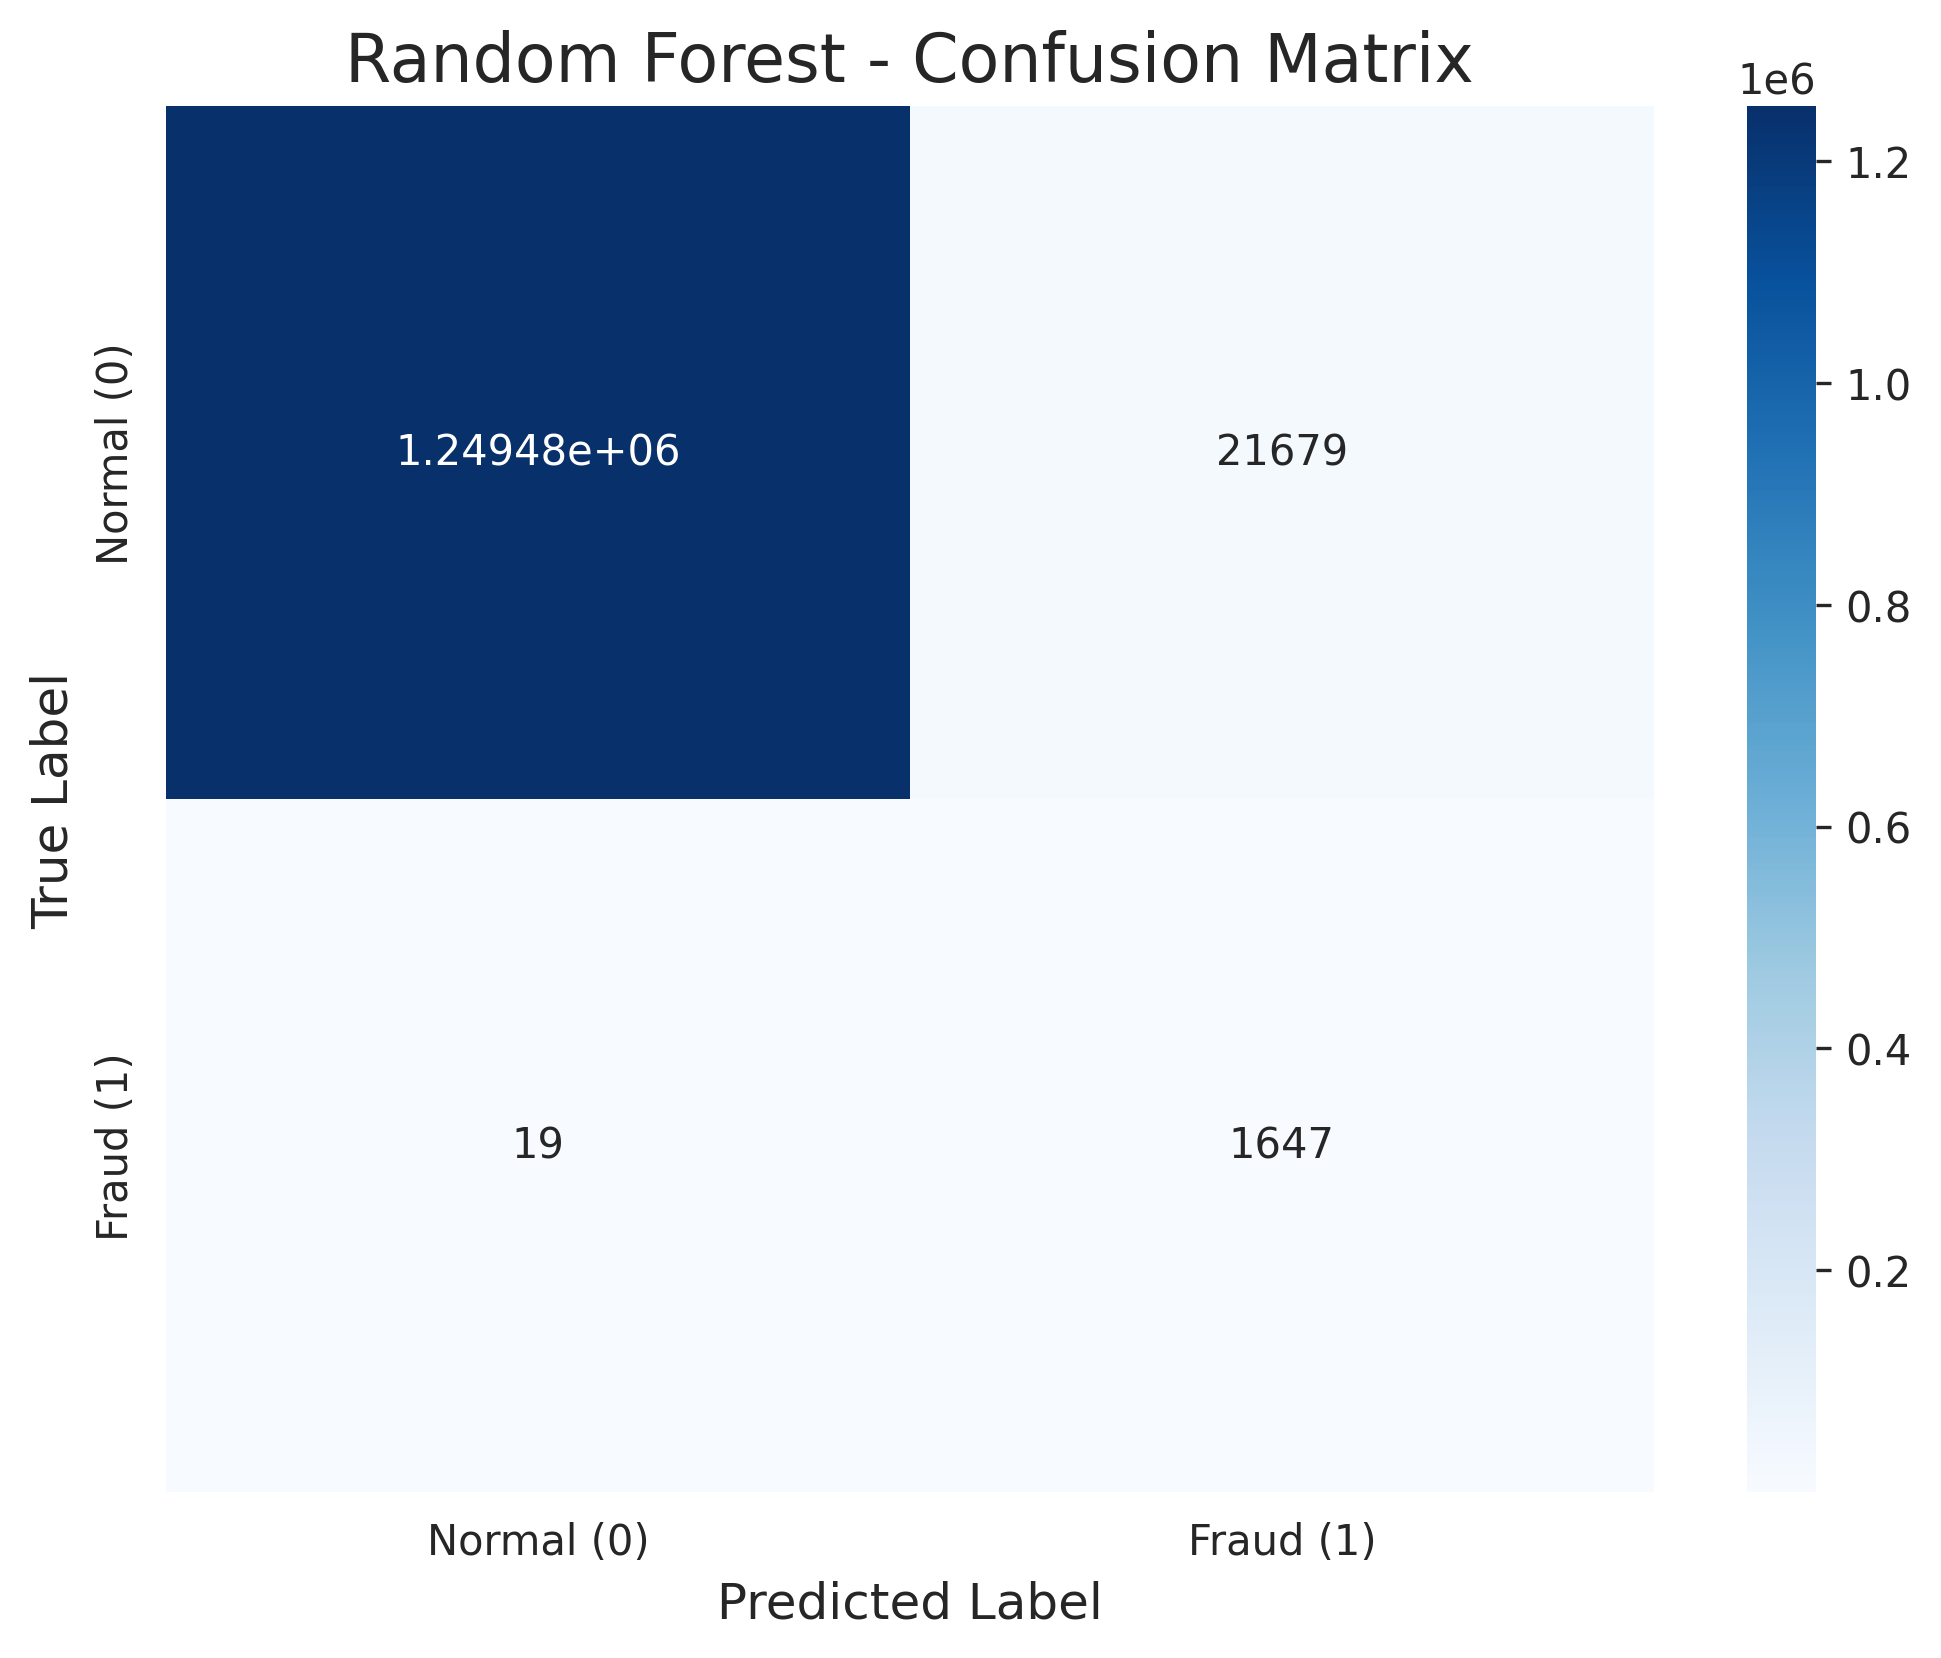

2026-04-08 11:53:25 - FraudDetectionLogger - INFO - Plotting confusion matrix for GBT...
2026-04-08 11:53:31 - FraudDetectionLogger - INFO - Saved GBT confusion matrix to /home/atomic/Desktop/BDA_Project/output/plots/06_cm_GBT.png


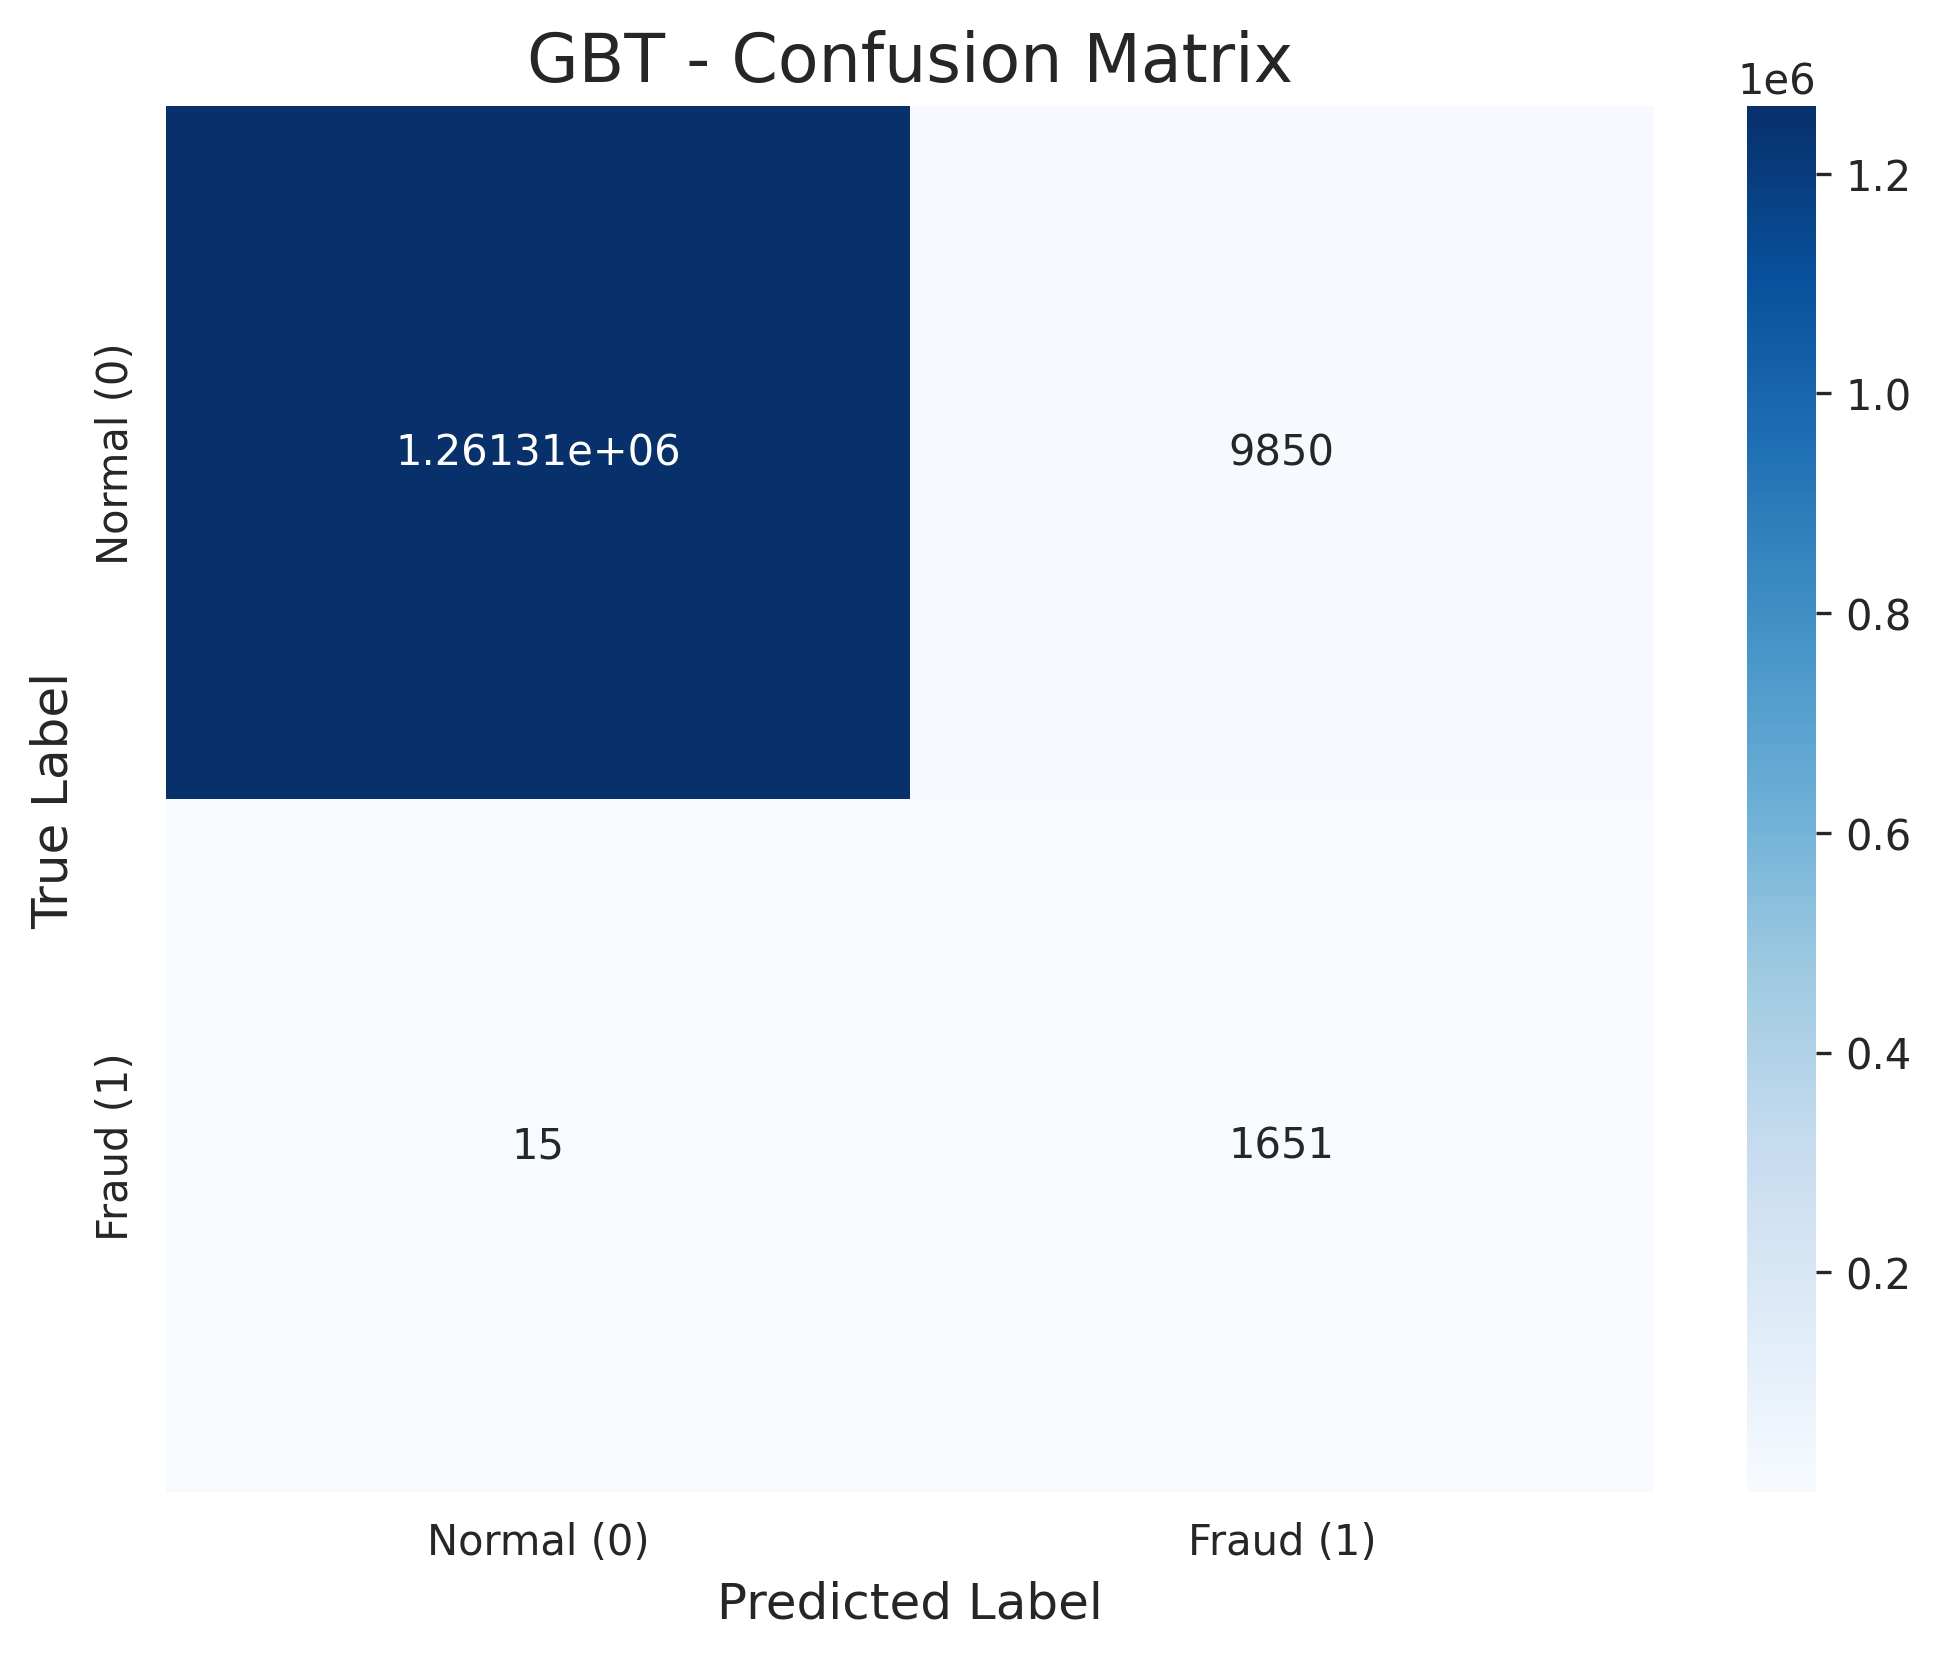

Cell 30: Confusion matrix plots generated.


In [30]:
# Cell 30: Section 7 (Evaluation) - Confusion Matrix (Visualization)
#
# Plot pretty confusion matrices for the top models.
#

def plot_confusion_matrix(predictions, model_name):
    """Generates and saves a confusion matrix plot."""
    try:
        log.info(f"Plotting confusion matrix for {model_name}...")
        
        # Collect data for plotting
        # This is a small aggregate, so .toPandas() is safe
        cm_data = predictions.groupBy("label","prediction").count().toPandas()
        
        # Pivot to create the matrix
        cm_matrix = cm_data.pivot(
            index='label', 
            columns='prediction', 
            values='count'
        ).fillna(0)
        
        # Ensure we have a 2x2 matrix even if one class wasn't predicted
        if 0 not in cm_matrix.index: cm_matrix.loc[0] = 0
        if 1 not in cm_matrix.index: cm_matrix.loc[1] = 0
        if 0.0 not in cm_matrix.columns: cm_matrix[0.0] = 0
        if 1.0 not in cm_matrix.columns: cm_matrix[1.0] = 0
        
        # Sort index and columns to ensure correct TN/FP/FN/TP placement
        cm_matrix = cm_matrix.sort_index(axis=0)[sorted(cm_matrix.columns)]
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            cm_matrix, 
            annot=True, 
            fmt='g', 
            cmap='Blues', 
            xticklabels=['Normal (0)', 'Fraud (1)'],
            yticklabels=['Normal (0)', 'Fraud (1)']
        )
        plt.title(f'{model_name} - Confusion Matrix', fontsize=16)
        plt.xlabel('Predicted Label', fontsize=12)
        plt.ylabel('True Label', fontsize=12)
        
        plot_path = os.path.join(PLOT_OUTPUT_DIR, f'06_cm_{model_name.replace(" ", "_")}.png')
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        log.info(f"Saved {model_name} confusion matrix to {plot_path}")
        
        plt.show()

    except Exception as e:
        log.error(f"Error plotting confusion matrix: {e}")
        import traceback
        log.error(traceback.format_exc())

try:
    # Plot for Random Forest and GBT if they exist
    if 'rf_predictions' in globals():
        plot_confusion_matrix(rf_predictions, "Random Forest")
    else:
        log.warning("RF predictions not found. Skipping confusion matrix.")
        
    if 'gbt_predictions' in globals():
        plot_confusion_matrix(gbt_predictions, "GBT")
    else:
        log.warning("GBT predictions not found. Skipping confusion matrix.")

except Exception as e:
    log.error(f"Error in confusion matrix plotting: {e}")

print("="*80)
print("Cell 30: Confusion matrix plots generated.")
print("="*80)

2026-04-08 11:53:32 - FraudDetectionLogger - INFO - Plotting ROC and PR curves...
2026-04-08 11:53:57 - FraudDetectionLogger - INFO - Saved ROC and PR curve plot to /home/atomic/Desktop/BDA_Project/output/plots/07_roc_pr_curves.png


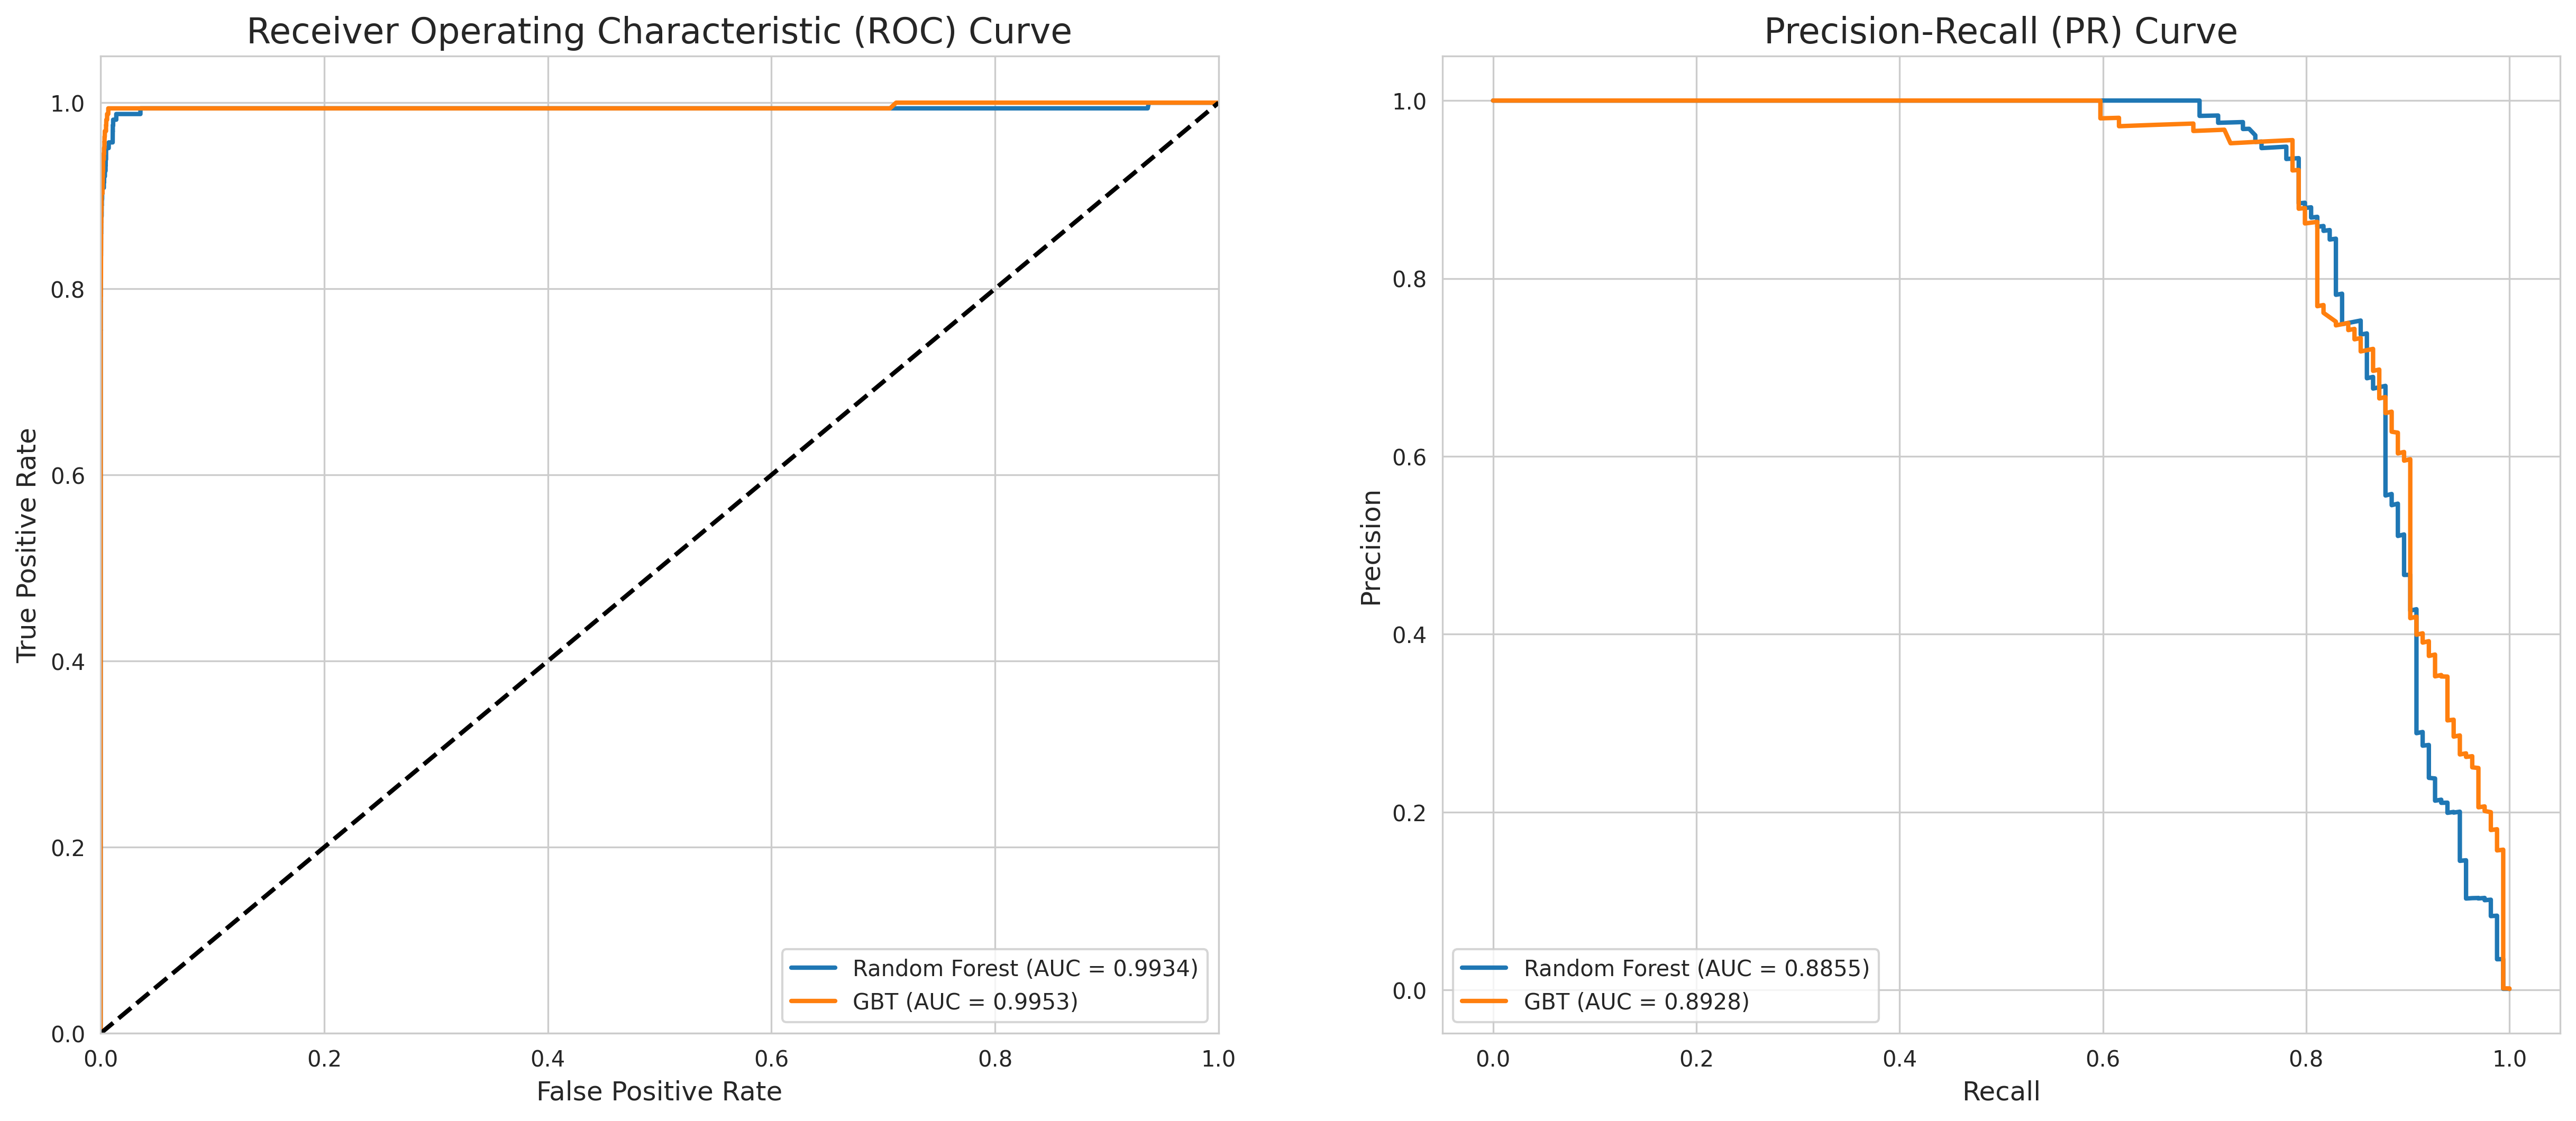

Cell 31: ROC and PR curves generated.


In [31]:
# Cell 31: Section 7 (Evaluation) - ROC and PR Curves
#
# This requires collecting probabilities. We will sample the test set
# to avoid OOM errors on the driver.
#

def plot_roc_pr_curves(predictions_list, model_names):
    """
    Plots ROC and PR curves for a list of models on one chart.
    """
    try:
        log.info("Plotting ROC and PR curves...")
        
        plt.figure(figsize=(20, 8))
        
        # --- 1. ROC Curve Plot ---
        plt.subplot(1, 2, 1)
        
        for i, predictions in enumerate(predictions_list):
            model_name = model_names[i]
            
            # Extract probability for class 1
            # We must sample to avoid OOM
            preds_sample_pd = predictions.select(
                "label", 
                "probability"
            ).sample(0.1, seed=42).toPandas()
            
            # Extract prob of "1" (fraud)
            y_prob = [p[1] for p in preds_sample_pd['probability']]
            y_true = preds_sample_pd['label']
            
            fpr, tpr, _ = roc_curve(y_true, y_prob)
            roc_auc_val = auc(fpr, tpr)
            
            plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc_val:.4f})')
        
        plt.plot([0, 1], [0, 1], 'k--', lw=2)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate', fontsize=12)
        plt.ylabel('True Positive Rate', fontsize=12)
        plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16)
        plt.legend(loc="lower right")

        # --- 2. PR Curve Plot ---
        plt.subplot(1, 2, 2)
        
        for i, predictions in enumerate(predictions_list):
            model_name = model_names[i]
            
            preds_sample_pd = predictions.select(
                "label", 
                "probability"
            ).sample(0.1, seed=42).toPandas()
            
            y_prob = [p[1] for p in preds_sample_pd['probability']]
            y_true = preds_sample_pd['label']
            
            precision, recall, _ = precision_recall_curve(y_true, y_prob)
            pr_auc_val = average_precision_score(y_true, y_prob)
            
            plt.plot(recall, precision, lw=2, label=f'{model_name} (AUC = {pr_auc_val:.4f})')
        
        plt.xlabel('Recall', fontsize=12)
        plt.ylabel('Precision', fontsize=12)
        plt.title('Precision-Recall (PR) Curve', fontsize=16)
        plt.legend(loc="lower left")

        # --- Save and Show ---
        plot_path = os.path.join(PLOT_OUTPUT_DIR, '07_roc_pr_curves.png')
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        log.info(f"Saved ROC and PR curve plot to {plot_path}")
        
        plt.show()

    except Exception as e:
        log.error(f"Error plotting ROC/PR curves: {e}")
        import traceback
        log.error(traceback.format_exc())

try:
    # Plot for RF and GBT if they exist (IF doesn't have probabilities)
    valid_predictions = []
    valid_names = []
    
    if 'rf_predictions' in globals() and 'probability' in rf_predictions.columns:
        valid_predictions.append(rf_predictions)
        valid_names.append("Random Forest")
    else:
        log.warning("RF predictions or probability column not found.")
        
    if 'gbt_predictions' in globals() and 'probability' in gbt_predictions.columns:
        valid_predictions.append(gbt_predictions)
        valid_names.append("GBT")
    else:
        log.warning("GBT predictions or probability column not found.")
    
    if valid_predictions:
        plot_roc_pr_curves(valid_predictions, valid_names)
    else:
        log.warning("No valid predictions with probability columns found. Skipping ROC/PR curves.")

except Exception as e:
    log.error(f"Error in ROC/PR curve plotting: {e}")

print("="*80)
print("Cell 31: ROC and PR curves generated.")
print("="*80)

In [32]:
# Cell 32: Section 8 (Advanced) - Identify Repeat Fraudsters
#
# Use Hive SQL to find accounts ('nameOrig') that have
# committed more than one fraudulent transaction.
#

try:
    log.info("Analyzing for repeat fraudulent senders...")
    
    sql_query = f"""
    SELECT 
        nameOrig, 
        SUM(isFraud) as total_fraud_transactions,
        SUM(amount) as total_fraud_amount,
        COUNT(*) as total_transactions
    FROM {HIVE_TABLE_NAME}
    WHERE isFraud = 1
    GROUP BY nameOrig
    HAVING total_fraud_transactions > 1
    ORDER BY total_fraud_transactions DESC, total_fraud_amount DESC
    """
    
    repeat_fraudsters_df = spark.sql(sql_query)
    
    log.info("Top Repeat Fraudsters (Senders):")
    repeat_fraudsters_df.show()
    
    log.info(f"Found {repeat_fraudsters_df.count()} accounts that sent > 1 fraudulent transaction.")
    
except Exception as e:
    log.error(f"Error identifying repeat fraudsters: {e}")

print("="*80)
print("Cell 32: Repeat fraudster analysis complete.")
print("="*80)

2026-04-08 11:53:58 - FraudDetectionLogger - INFO - Analyzing for repeat fraudulent senders...
2026-04-08 11:53:58 - FraudDetectionLogger - INFO - Top Repeat Fraudsters (Senders):
                                                                                

+--------+------------------------+------------------+------------------+
|nameOrig|total_fraud_transactions|total_fraud_amount|total_transactions|
+--------+------------------------+------------------+------------------+
+--------+------------------------+------------------+------------------+



2026-04-08 11:54:01 - FraudDetectionLogger - INFO - Found 0 accounts that sent > 1 fraudulent transaction.
                                                                                

Cell 32: Repeat fraudster analysis complete.


In [ ]:
# Cell 33: Section 8 (Advanced) - Fraud by Amount Ranges [MODIFIED]

try:
    log.info("Analyzing fraud patterns by transaction amount range...")
    
    sql_query = f"""
    SELECT 
        CASE
            WHEN amount < 1000 THEN '1. < 1K'
            WHEN amount BETWEEN 1000 AND 10000 THEN '2. 1K - 10K'
            WHEN amount BETWEEN 10000 AND 100000 THEN '3. 10K - 100K'
            WHEN amount BETWEEN 100000 AND 1000000 THEN '4. 100K - 1M'
            ELSE '5. > 1M'
        END as amount_range,
        SUM(isFraud) as total_fraud,
        COUNT(*) as total_transactions,
        (SUM(isFraud) / COUNT(*)) * 100 as fraud_rate_in_range
    FROM {HIVE_TABLE_NAME}
    GROUP BY amount_range
    ORDER BY amount_range
    """
    
    amount_range_df = spark.sql(sql_query)
    
    log.info("Fraud Statistics by Amount Range:")
    amount_range_df.show()

except Exception as e:
    log.error(f"Error analyzing fraud by amount ranges: {e}")

print("="*80)
print("Cell 33: Fraud by amount range analysis complete.")
print("="*80)

2026-04-08 11:54:01 - FraudDetectionLogger - INFO - Analyzing fraud patterns by transaction amount range...
2026-04-08 11:54:02 - FraudDetectionLogger - INFO - Fraud Statistics by Amount Range:
[Stage 1037:=====================================>                  (2 + 1) / 3]

+-------------+-----------+------------------+-------------------+
| amount_range|total_fraud|total_transactions|fraud_rate_in_range|
+-------------+-----------+------------------+-------------------+
|      1. < 1K|         58|            142642|0.04066123582114665|
|  2. 1K - 10K|        220|           1143449|0.01924003606632215|
|3. 10K - 100K|       1429|           2239207|0.06381723529803185|
| 4. 100K - 1M|       3800|           2706696|0.14039256717414886|
|      5. > 1M|       2706|            130626| 2.0715630885122414|
+-------------+-----------+------------------+-------------------+

Cell 33: Fraud by amount range analysis complete.


2026-04-08 11:54:03 - FraudDetectionLogger - INFO - Generating hourly transaction heatmap data...
2026-04-08 11:54:06 - FraudDetectionLogger - INFO - Saved total transactions heatmap to /home/atomic/Desktop/BDA_Project/output/plots/08_heatmap_total.png


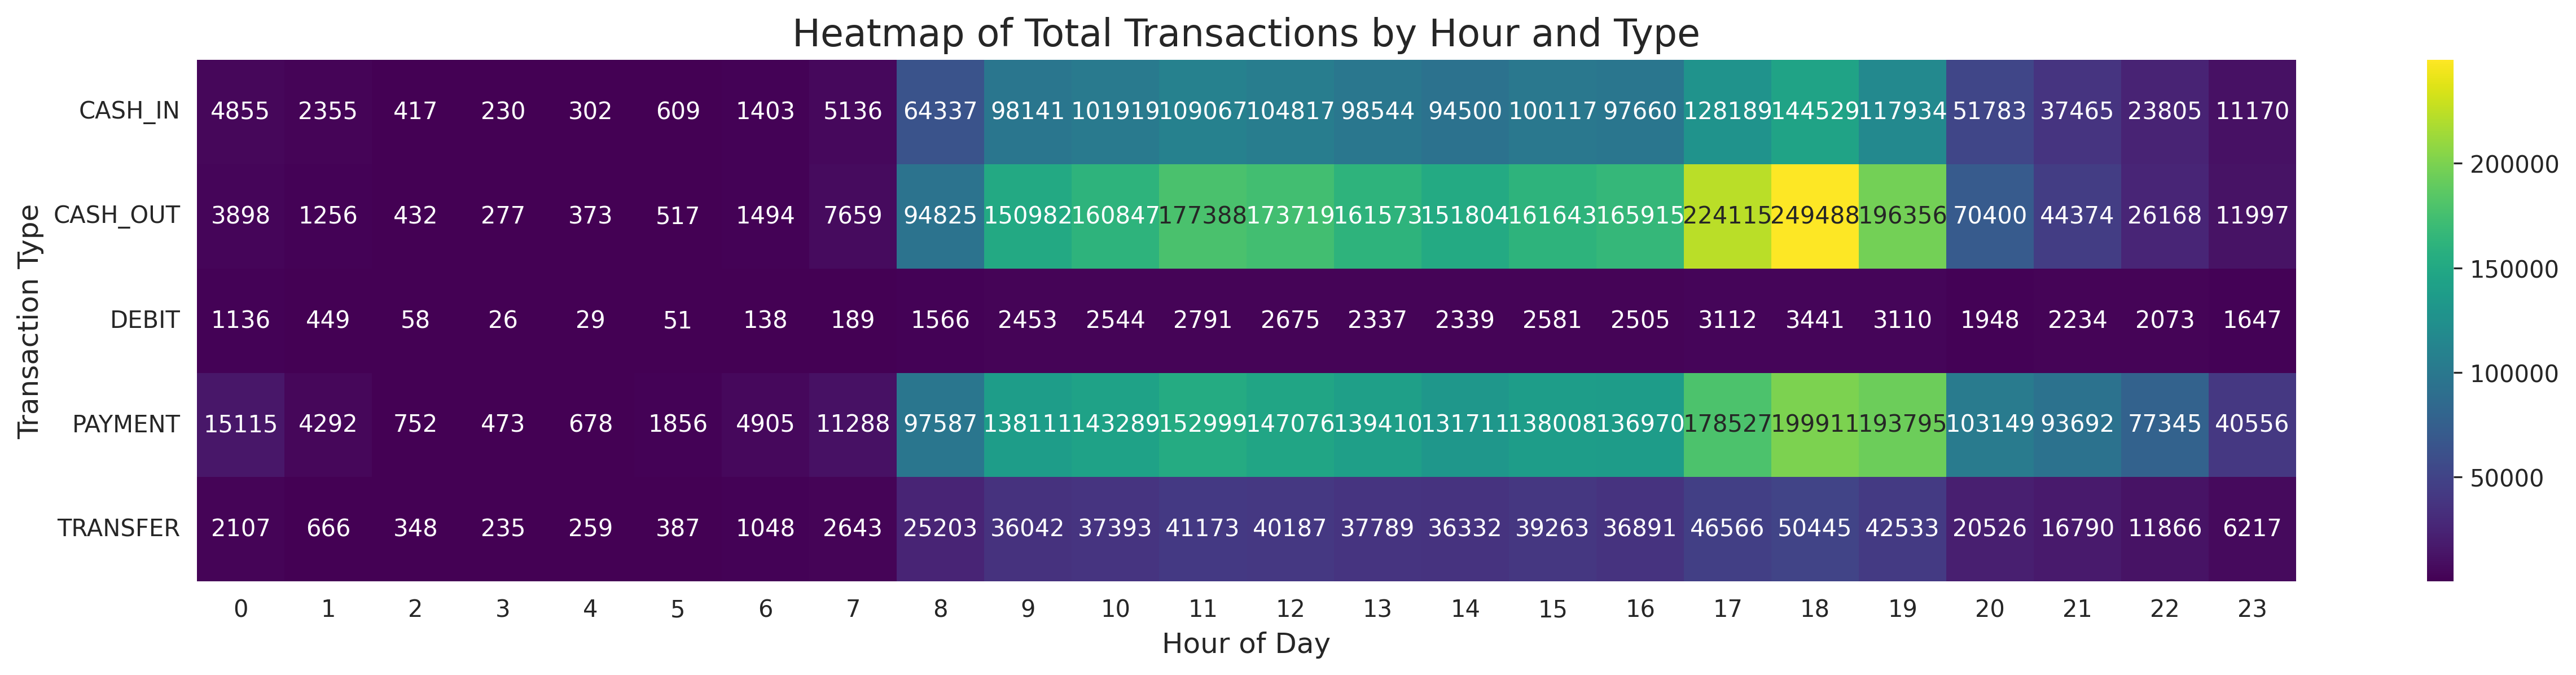

2026-04-08 11:54:07 - FraudDetectionLogger - INFO - Saved fraud transactions heatmap to /home/atomic/Desktop/BDA_Project/output/plots/09_heatmap_fraud.png


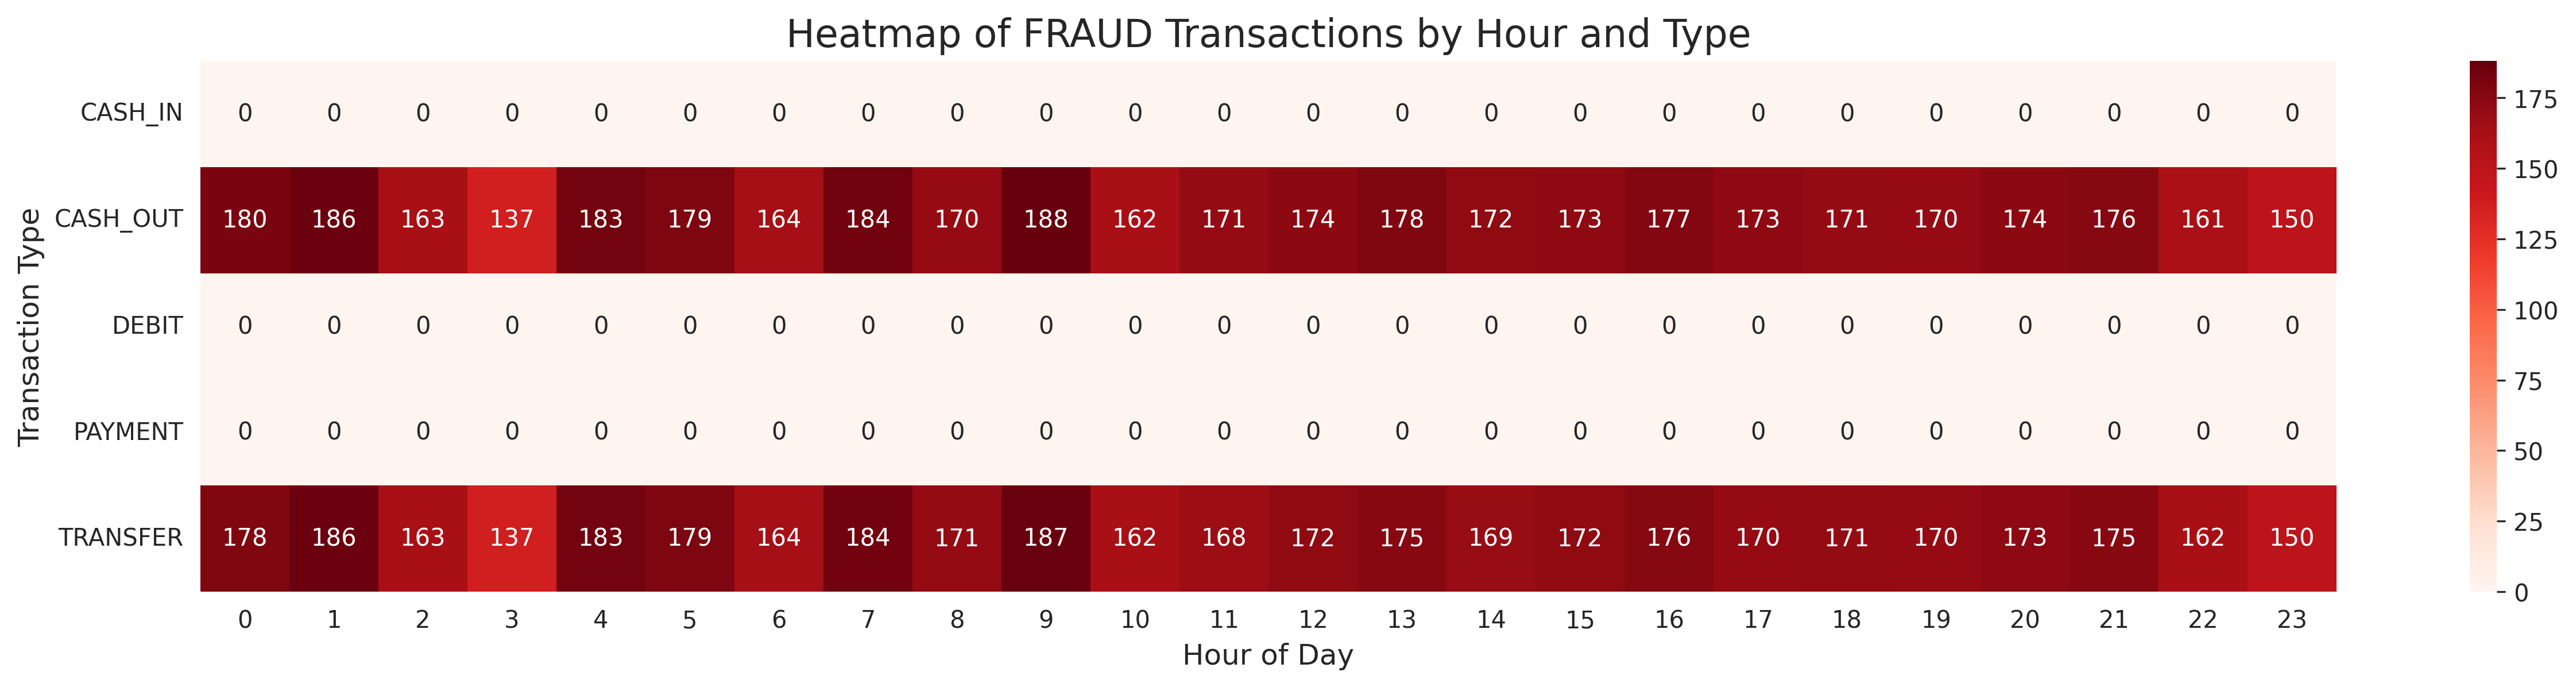

Cell 34: Transaction heatmap analysis complete.


In [34]:
# Cell 34: Section 9 (Time-Series) - Hourly Fraud Heatmap
#
# Use a SQL query to create a heatmap of transactions
# by 'hour_of_day' and 'type'.
#

try:
    log.info("Generating hourly transaction heatmap data...")
    
    # We use the 'transactions_with_time' view from Cell 18
    sql_query = f"""
    SELECT 
        hour_of_day,
        type,
        COUNT(*) as num_transactions,
        SUM(isFraud) as num_fraud
    FROM transactions_with_time
    GROUP BY hour_of_day, type
    """
    
    heatmap_df = spark.sql(sql_query)
    heatmap_pd = heatmap_df.toPandas()
    
    # --- Plot 1: Total Transactions ---
    heatmap_total_pd = heatmap_pd.pivot(
        index="type", 
        columns="hour_of_day", 
        values="num_transactions"
    ).fillna(0)
    
    plt.figure(figsize=(20, 4))
    sns.heatmap(heatmap_total_pd, annot=True, fmt='g', cmap='viridis')
    plt.title('Heatmap of Total Transactions by Hour and Type', fontsize=16)
    plt.xlabel('Hour of Day', fontsize=12)
    plt.ylabel('Transaction Type', fontsize=12)
    
    plot_path = os.path.join(PLOT_OUTPUT_DIR, '08_heatmap_total.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    log.info(f"Saved total transactions heatmap to {plot_path}")
    plt.show()

    # --- Plot 2: Fraud Transactions ---
    heatmap_fraud_pd = heatmap_pd.pivot(
        index="type", 
        columns="hour_of_day", 
        values="num_fraud"
    ).fillna(0)
    
    plt.figure(figsize=(20, 4))
    sns.heatmap(heatmap_fraud_pd, annot=True, fmt='g', cmap='Reds')
    plt.title('Heatmap of FRAUD Transactions by Hour and Type', fontsize=16)
    plt.xlabel('Hour of Day', fontsize=12)
    plt.ylabel('Transaction Type', fontsize=12)
    
    plot_path = os.path.join(PLOT_OUTPUT_DIR, '09_heatmap_fraud.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    log.info(f"Saved fraud transactions heatmap to {plot_path}")
    plt.show()
    
except Exception as e:
    log.error(f"Error generating transaction heatmaps: {e}")

print("="*80)
print("Cell 34: Transaction heatmap analysis complete.")
print("="*80)

In [35]:
# Cell 35: Section 9 (Model Summary) - Model Storage Summary
#
# Summary of where models are saved (models are already saved in cells 24-25).
# No need to save again - just show the current model locations.
#

try:
    log.info("Model Storage Summary:")
    
    # --- 1. Check Random Forest Model ---
    rf_model_path = os.path.join(MODEL_OUTPUT_DIR, 'random_forest_model')
    if os.path.exists(rf_model_path):
        log.info(f"✓ Random Forest model saved at: {rf_model_path}")
    else:
        log.warning(f"✗ Random Forest model not found at: {rf_model_path}")
    
    # --- 2. Check GBT Model ---
    gbt_model_path = os.path.join(MODEL_OUTPUT_DIR, 'gbt_model')
    if os.path.exists(gbt_model_path):
        log.info(f"✓ GBT model saved at: {gbt_model_path}")
    else:
        log.warning(f"✗ GBT model not found at: {gbt_model_path}")
    
    # --- 3. Save Preprocessing Pipeline (if needed) ---
    preproc_path = os.path.join(MODEL_OUTPUT_DIR, "preprocessing_pipeline")
    if not os.path.exists(preproc_path):
        log.info("Saving preprocessing pipeline for standalone use...")
        
        # Reload the data it was trained on
        temp_df = spark.read.parquet(HDFS_DATA_PATH).drop('nameOrig', 'nameDest', 'isFlaggedFraud')
        temp_df_with_time = temp_df.withColumn("hour_of_day", (col("step") - 1) % 24)
        
        # Define pipeline
        preproc_pipeline = Pipeline(
            stages=[type_indexer, type_encoder, assembler, scaler]
        )
        # Fit and save
        preproc_model_to_save = preproc_pipeline.fit(temp_df_with_time)
        preproc_model_to_save.write().overwrite().save(f"file://{preproc_path}")
        
        log.info(f"✓ Preprocessing pipeline saved at: {preproc_path}")
    else:
        log.info(f"✓ Preprocessing pipeline already exists at: {preproc_path}")


except Exception as e:
    log.error(f"Error checking/saving models: {e}")
    
print("="*80)
print("Cell 35: Model storage summary complete.")
print("="*80)

2026-04-08 11:54:08 - FraudDetectionLogger - INFO - Model Storage Summary:
2026-04-08 11:54:08 - FraudDetectionLogger - INFO - ✓ Random Forest model saved at: /home/atomic/Desktop/BDA_Project/models/random_forest_model
2026-04-08 11:54:08 - FraudDetectionLogger - INFO - ✓ GBT model saved at: /home/atomic/Desktop/BDA_Project/models/gbt_model
2026-04-08 11:54:08 - FraudDetectionLogger - INFO - Saving preprocessing pipeline for standalone use...
2026-04-08 11:54:28 - FraudDetectionLogger - INFO - ✓ Preprocessing pipeline saved at: /home/atomic/Desktop/BDA_Project/models/preprocessing_pipeline


Cell 35: Model storage summary complete.


In [36]:
# Cell 36: Section 9 (Model Loading/Prediction) - Demo
#
# Demonstrate how to load the models and make a prediction using the correct model classes.
#

try:
    log.info("--- Model Loading and Prediction Demo ---")
    
    # --- 1. Load Models from correct paths with correct classes ---
    rf_model_path = f"file://{MODEL_OUTPUT_DIR}/random_forest_model"
    gbt_model_path = f"file://{MODEL_OUTPUT_DIR}/gbt_model"
    
    # Check which models are available
    available_models = []
    if os.path.exists(os.path.join(MODEL_OUTPUT_DIR, 'random_forest_model')):
        available_models.append(('Random Forest', rf_model_path, 'rf'))
    if os.path.exists(os.path.join(MODEL_OUTPUT_DIR, 'gbt_model')):
        available_models.append(('GBT', gbt_model_path, 'gbt'))
    
    if available_models:
        log.info(f"Found {len(available_models)} trained models")
        
        # Load the GBT model (preferred) or Random Forest if available
        if any('GBT' in model[0] for model in available_models):
            model_name, model_path, model_type = next(model for model in available_models if 'GBT' in model[0])
        else:
            model_name, model_path, model_type = available_models[0]
            
        log.info(f"Loading {model_name} model from: {model_path}")
        
        # Load with the correct model class
        if model_type == 'rf':
            from pyspark.ml.classification import RandomForestClassificationModel
            loaded_model = RandomForestClassificationModel.load(model_path)
        elif model_type == 'gbt':
            from pyspark.ml.classification import GBTClassificationModel
            loaded_model = GBTClassificationModel.load(model_path)
        
        # --- 2. Load Sample Data for Prediction ---
        log.info("Loading sample data from test set...")
        test_df = spark.read.parquet(HDFS_TEST_PATH)
        
        # Get one fraud and one normal transaction
        sample_fraud = test_df.filter("label = 1").limit(1)
        sample_normal = test_df.filter("label = 0").limit(1)
        
        if sample_fraud.count() > 0 and sample_normal.count() > 0:
            sample_data = sample_fraud.union(sample_normal)
            
            log.info(f"Making predictions with {model_name} model...")
            predictions = loaded_model.transform(sample_data)
            
            print(f"\n--- {model_name} Model Predictions ---")
            predictions.select(
                "label", "prediction", "probability"
            ).show(truncate=False)
            
            # Show some feature information too
            print("\n--- Sample Features (first 10 values) ---")
            features_row = predictions.select("features").collect()[0]
            feature_values = features_row['features'].toArray()
            print(f"Features vector size: {len(feature_values)}")
            print(f"First 10 feature values: {feature_values[:10]}")
            
            # Show model type for reference
            print(f"\n--- Model Information ---")
            print(f"Model Type: {model_name}")
            print(f"Model Class: {type(loaded_model).__name__}")
            
        else:
            log.warning("Could not find both fraud and normal samples in test data")
    else:
        log.warning("No trained models found. Please run cells 24-25 first to train models.")
        log.info("Expected model locations:")
        log.info(f"  - Random Forest: {os.path.join(MODEL_OUTPUT_DIR, 'random_forest_model')}")
        log.info(f"  - GBT: {os.path.join(MODEL_OUTPUT_DIR, 'gbt_model')}")
    
except Exception as e:
    log.error(f"Error in model loading/prediction demo: {e}")
    import traceback
    log.error(traceback.format_exc())

print("="*80)
print("Cell 36: Model loading and prediction demo complete.")
print("="*80)

2026-04-08 11:54:28 - FraudDetectionLogger - INFO - --- Model Loading and Prediction Demo ---
2026-04-08 11:54:28 - FraudDetectionLogger - INFO - Found 2 trained models
2026-04-08 11:54:28 - FraudDetectionLogger - INFO - Loading GBT model from: file:///home/atomic/Desktop/BDA_Project/models/gbt_model
2026-04-08 11:54:30 - FraudDetectionLogger - INFO - Loading sample data from test set...
2026-04-08 11:54:30 - FraudDetectionLogger - INFO - Making predictions with GBT model...



--- GBT Model Predictions ---
+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|1    |1.0       |[0.023460915332439,0.976539084667561]   |
|0    |0.0       |[0.9784660431658334,0.02153395683416659]|
+-----+----------+----------------------------------------+


--- Sample Features (first 10 values) ---
Features vector size: 12
First 10 feature values: [-0.73648379 -0.71477782 -0.5309652   3.3074779  -0.08095964 -1.70304144
 -0.29320773 -0.2877449  -0.29244168 -0.32381387]

--- Model Information ---
Model Type: GBT
Model Class: GBTClassificationModel
Cell 36: Model loading and prediction demo complete.


In [ ]:
# Cell 37: Section 10 - Spark Shutdown (Deferred) [MODIFIED]
#
# This cell no longer stops Spark. The shutdown is moved to the end
# to keep the session alive for LSTM training and evaluation.

log.info("Spark shutdown deferred until final cell.")
print("="*80)
print("Cell 37: SparkSession still active. Run final shutdown cell at the end.")
print("="*80)

2026-04-14 23:04:33 - FraudDetectionLogger - INFO - Cleaning up and stopping SparkSession...
2026-04-14 23:04:33 - FraudDetectionLogger - INFO - Deleting intermediate HDFS files...
2026-04-14 23:04:33 - py4j.clientserver - INFO - Closing down clientserver connection
2026-04-14 23:04:33 - FraudDetectionLogger - ERROR - Error during Spark shutdown: [Errno 111] Connection refused
2026-04-14 23:04:33 - py4j.clientserver - INFO - Closing down clientserver connection


Cell 37: SparkSession stopped. Project complete.


# Section 10 · Deep Learning Approach (LSTM)

This section keeps the original Hadoop + Spark + Hive data pipeline intact while layering an LSTM-based fraud detector on top of sequence-aware features. We group transactions per sender, build sliding windows, train a TensorFlow/Keras model, and compare it with the distributed Random Forest and GBT baselines.

In [1]:
# Cell 38: Section 10

# ──────────────────────────────────────────────────────────
# 1. Core imports
# ──────────────────────────────────────────────────────────
import os
import sys
import json
import time
import logging
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ──────────────────────────────────────────────────────────
# 2. Logging setup
# ──────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
log = logging.getLogger("FraudDetection_LSTM")
# ──────────────────────────────────────────────────────────
# 3. GPU / TensorFlow configuration
# ──────────────────────────────────────────────────────────
import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        log.info("Memory growth enabled.")
    except RuntimeError:
        log.info("GPU already initialized - memory growth setting skipped (OK).")
    log.info(f"GPU(s) available: {len(gpus)}")
else:
    log.warning("No GPU detected. Training will run on CPU (slow).")

# ──────────────────────────────────────────────────────────
# 4. Sklearn imports
# ──────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

# ──────────────────────────────────────────────────────────
# 5. Reproducibility
# ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ──────────────────────────────────────────────────────────
# 6. Visualization settings
# ──────────────────────────────────────────────────────────
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 150

# ──────────────────────────────────────────────────────────
# 7. DATA SOURCE – Kaggle CSV only (NO HDFS)
# ──────────────────────────────────────────────────────────
DATA_PATH = "/kaggle/input/datasets/ealaxi/paysim1/PS_20174392719_1491204439457_log.csv"

# ──────────────────────────────────────────────────────────
# 8. Output directories (all local)
# ──────────────────────────────────────────────────────────
BASE_DIR = os.getcwd()
DEEP_LEARNING_BASE_DIR = os.path.join(BASE_DIR, "results", "deep_learning")
os.makedirs(DEEP_LEARNING_BASE_DIR, exist_ok=True)

PLOT_DL_DIR = os.path.join(DEEP_LEARNING_BASE_DIR, "plots")
os.makedirs(PLOT_DL_DIR, exist_ok=True)

MODEL_OUTPUT_DIR = os.path.join(DEEP_LEARNING_BASE_DIR, "models")
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)

METRICS_OUTPUT_DIR = os.path.join(DEEP_LEARNING_BASE_DIR, "metrics")
os.makedirs(METRICS_OUTPUT_DIR, exist_ok=True)

LSTM_MODEL_LOCAL_PATH      = os.path.join(MODEL_OUTPUT_DIR, "lstm_fraud_model.keras")
SCALER_PATH                = os.path.join(MODEL_OUTPUT_DIR, "lstm_step_scaler.pkl")
TRAIN_LOG_LOCAL_PATH       = os.path.join(DEEP_LEARNING_BASE_DIR, "lstm_training_log.csv")
LSTM_CHECKPOINT_LOCAL_PATH = os.path.join(DEEP_LEARNING_BASE_DIR, "lstm_checkpoint.keras")
SEQUENCE_PICKLE_PATH       = os.path.join(DEEP_LEARNING_BASE_DIR, "sequence_windows.pkl")
ARTIFACTS_JSON_PATH        = os.path.join(DEEP_LEARNING_BASE_DIR, "realtime_alerts_sample.json")
COMPARISON_PATH            = os.path.join(METRICS_OUTPUT_DIR, "model_comparison_with_lstm.csv")

SEQUENCE_LENGTH      = 10          # number of time-steps per window
SLIDING_STEP         = 2           # stride for sliding window
MAX_SEQ_PER_ACCOUNT  = 100         # max windows per account
DATA_READ_ROWS       = None        # None = read ALL rows (~6.3M)
DATA_SAMPLE_SIZE     = None        # None = use ALL data for sequence gen
TEST_SIZE            = 0.15        # fraction for final hold-out test
VALIDATION_SIZE      = 0.15        # fraction of training set for validation
BATCH_SIZE           = 1024        # T4 can handle large batches
MAX_EPOCHS           = 80          # plenty of room; EarlyStopping will cut
LEARNING_RATE        = 5e-4
RESUME_LSTM          = False       # start fresh
THRESHOLD_GRID       = np.linspace(0.01, 0.99, 99)

# Initialize all_metrics as empty list (no Spark models available)
all_metrics = []

log.info(f"Data path: {DATA_PATH}")
log.info(f"Output dir: {DEEP_LEARNING_BASE_DIR}")
log.info(f"Sequence length: {SEQUENCE_LENGTH}, Step: {SLIDING_STEP}")
log.info(f"Max epochs: {MAX_EPOCHS}, Batch size: {BATCH_SIZE}, LR: {LEARNING_RATE}")

print("=" * 80)


2026-04-15 11:33:26.432519: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776252806.638353      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776252806.691000      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776252807.093848      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776252807.093881      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776252807.093884      24 computation_placer.cc:177] computation placer alr

In [2]:
# Cell 39: Section 10 - Load PaySim CSV and engineer features

log.info(f"Path: {DATA_PATH}")

raw_cols = [
    "step",
    "type",
    "amount",
    "nameOrig",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud",
]

def load_paysim_dataframe():
    """Load the PaySim CSV and engineer basic features."""
    log.info("Reading CSV (this may take a minute for 6M+ rows)...")
    df_local = pd.read_csv(DATA_PATH, usecols=raw_cols, nrows=DATA_READ_ROWS)
    log.info(f"Raw data loaded: {df_local.shape}")

    if DATA_SAMPLE_SIZE is not None and len(df_local) > DATA_SAMPLE_SIZE:
        df_local = df_local.sample(DATA_SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)
        log.info(f"Sampled down to {len(df_local)} rows")
    else:
        df_local = df_local.reset_index(drop=True)

    # Ensure correct types
    df_local["nameOrig"] = df_local["nameOrig"].astype(str)
    df_local["type"] = df_local["type"].astype(str)

    # ── Feature engineering ──
    # Encode transaction type as numeric
    type_map = {
        "PAYMENT": 0,
        "TRANSFER": 1,
        "CASH_OUT": 2,
        "CASH_IN": 3,
        "DEBIT": 4,
    }
    df_local["type_index"] = df_local["type"].map(type_map).fillna(5).astype(np.float32)

    # Time-of-day feature (each step = 1 hour in PaySim)
    df_local["hour_of_day"] = ((df_local["step"] - 1) % 24).astype(np.float32)

    # Balance-change features (useful for fraud detection)
    df_local["balance_change_orig"] = (
        df_local["newbalanceOrig"] - df_local["oldbalanceOrg"]
    ).astype(np.float32)
    df_local["balance_change_dest"] = (
        df_local["newbalanceDest"] - df_local["oldbalanceDest"]
    ).astype(np.float32)

    # Amount-to-balance ratio
    df_local["amount_to_balance_ratio"] = np.where(
        df_local["oldbalanceOrg"] > 0,
        df_local["amount"] / df_local["oldbalanceOrg"],
        0.0,
    ).astype(np.float32)

    return df_local


df_lstm = load_paysim_dataframe()

print("=" * 80)
print(f"Loaded data shape: {df_lstm.shape}")
print(f"Columns: {list(df_lstm.columns)}")
print()
print("Target distribution:")
print(df_lstm["isFraud"].value_counts(dropna=False))
print()
print("Fraud rate: {:.4f}%".format(100 * df_lstm["isFraud"].mean()))
print()
print(df_lstm.head())
print("=" * 80)


2026-04-15 11:33:49 - FraudDetection_LSTM - INFO - Path: /kaggle/input/datasets/ealaxi/paysim1/PS_20174392719_1491204439457_log.csv
2026-04-15 11:33:49 - FraudDetection_LSTM - INFO - Reading CSV (this may take a minute for 6M+ rows)...
2026-04-15 11:33:59 - FraudDetection_LSTM - INFO - Raw data loaded: (6362620, 9)


Loaded data shape: (6362620, 14)
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'type_index', 'hour_of_day', 'balance_change_orig', 'balance_change_dest', 'amount_to_balance_ratio']

Target distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud rate: 0.1291%

   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

   oldbalanceDest  newbalanceDest  isFraud  type_index  hour_of_day  \
0             0.0             0.0        0         0.0          0.0   
1             0.0             0.0     

In [3]:
# Cell 40: Section 10 - Build sliding-window sequences (FULL DATA)
#
# Strategy:
#   1. Sort entire dataset by time (step)
#   2. Generate global sliding windows over the FULL dataset
#   3. Oversample fraud-containing windows to combat class imbalance
#
# With 6.3M rows, SEQUENCE_LENGTH=10, SLIDING_STEP=2:
#   -> ~3.15 MILLION sequences generated
#   -> This gives the LSTM enough data to properly learn

sequence_feature_columns = (
    "type_index",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "hour_of_day",
    "balance_change_orig",
    "balance_change_dest",
    "amount_to_balance_ratio",
)

log.info(f"Building sequences: length={SEQUENCE_LENGTH}, step={SLIDING_STEP}")
log.info(f"Features per time-step: {len(sequence_feature_columns)}")

def build_lstm_sequences_full(input_df):
    """
    Build sliding-window sequences using global time ordering.
    Uses the ENTIRE dataset for maximum training data.
    Then oversamples fraud windows to reduce imbalance.
    """
    log.info("Sorting data by time step...")
    sorted_df = input_df.sort_values("step").reset_index(drop=True)

    features_np = sorted_df[list(sequence_feature_columns)].astype(np.float32).to_numpy()
    labels_np = sorted_df["isFraud"].astype(np.int32).to_numpy()

    n = len(sorted_df)
    log.info(f"Total rows: {n}")

    # Pre-compute all windows
    sequences = []
    labels = []

    total_windows = (n - SEQUENCE_LENGTH) // SLIDING_STEP + 1
    log.info(f"Expected ~{total_windows} windows...")

    for start in range(0, n - SEQUENCE_LENGTH + 1, SLIDING_STEP):
        end = start + SEQUENCE_LENGTH
        seq_window = features_np[start:end]
        label_value = int(np.any(labels_np[start:end]))
        sequences.append(seq_window)
        labels.append(label_value)

        if len(sequences) % 500000 == 0:
            log.info(f"  Generated {len(sequences)} sequences...")

    sequences = np.array(sequences, dtype=np.float32)
    labels = np.array(labels, dtype=np.int32)

    fraud_count = int(labels.sum())
    normal_count = len(labels) - fraud_count

    log.info(f"Total sequences: {len(labels)}")
    log.info(f"Normal: {normal_count} | Fraud: {fraud_count}")
    log.info(f"Fraud rate: {100 * fraud_count / len(labels):.4f}%")

    # ── Oversample fraud sequences ──
    # Target: at least 5% fraud ratio for better learning
    if fraud_count > 0 and fraud_count < normal_count * 0.05:
        target_fraud = int(normal_count * 0.05)
        oversample_factor = max(1, target_fraud // fraud_count)
        log.info(f"Oversampling fraud sequences by {oversample_factor}x (target ~5% fraud ratio)")

        fraud_mask = labels == 1
        fraud_seqs = sequences[fraud_mask]
        fraud_labs = labels[fraud_mask]

        # Repeat fraud sequences with small random noise for augmentation
        augmented_seqs = []
        augmented_labs = []
        for _ in range(oversample_factor):
            noise = np.random.normal(0, 0.01, fraud_seqs.shape).astype(np.float32)
            augmented_seqs.append(fraud_seqs + noise)
            augmented_labs.append(fraud_labs)

        augmented_seqs = np.concatenate(augmented_seqs, axis=0)
        augmented_labs = np.concatenate(augmented_labs, axis=0)

        sequences = np.concatenate([sequences, augmented_seqs], axis=0)
        labels = np.concatenate([labels, augmented_labs], axis=0)

        # Shuffle
        perm = np.random.permutation(len(labels))
        sequences = sequences[perm]
        labels = labels[perm]

        final_fraud = int(labels.sum())
        log.info(f"After oversampling: {len(labels)} sequences, {final_fraud} fraud ({100*final_fraud/len(labels):.2f}%)")

    return sequences, labels


try:
    X_all_sequences, y_all_labels = build_lstm_sequences_full(df_lstm)

    if len(X_all_sequences) == 0:
        raise ValueError("No sequences generated!")

    sequence_count = len(y_all_labels)
    fraud_sequences = int(y_all_labels.sum())
    normal_sequences = sequence_count - fraud_sequences

    log.info(f"Final dataset: {sequence_count} sequences")

except Exception as e:
    log.error(f"Error building sequences: {e}")
    raise

print("=" * 80)
print(f"Cell 40: {sequence_count} sequences generated.")
print(f"  Normal: {normal_sequences} | Fraud: {fraud_sequences}")
print(f"  Shape: {X_all_sequences.shape}")
print("=" * 80)


2026-04-15 11:34:00 - FraudDetection_LSTM - INFO - Building sequences: length=10, step=2
2026-04-15 11:34:00 - FraudDetection_LSTM - INFO - Features per time-step: 10
2026-04-15 11:34:00 - FraudDetection_LSTM - INFO - Sorting data by time step...
2026-04-15 11:34:03 - FraudDetection_LSTM - INFO - Total rows: 6362620
2026-04-15 11:34:03 - FraudDetection_LSTM - INFO - Expected ~3181306 windows...
2026-04-15 11:34:05 - FraudDetection_LSTM - INFO -   Generated 500000 sequences...
2026-04-15 11:34:07 - FraudDetection_LSTM - INFO -   Generated 1000000 sequences...
2026-04-15 11:34:10 - FraudDetection_LSTM - INFO -   Generated 1500000 sequences...
2026-04-15 11:34:12 - FraudDetection_LSTM - INFO -   Generated 2000000 sequences...
2026-04-15 11:34:14 - FraudDetection_LSTM - INFO -   Generated 2500000 sequences...
2026-04-15 11:34:17 - FraudDetection_LSTM - INFO -   Generated 3000000 sequences...
2026-04-15 11:34:19 - FraudDetection_LSTM - INFO - Total sequences: 3181306
2026-04-15 11:34:19 - F

Cell 40: 3334954 sequences generated.
  Normal: 3162100 | Fraud: 172854
  Shape: (3334954, 10, 10)


In [4]:
# Cell 41: Section 10 - Scale features and split into train/val/test

log.info("Scaling features and splitting data...")

try:
    num_samples, seq_len, num_features = X_all_sequences.shape
    log.info(f"Input tensor shape: {X_all_sequences.shape}")

    # ── Per-step StandardScaler ──
    step_scaler = StandardScaler()
    X_flat = X_all_sequences.reshape(num_samples * seq_len, num_features)
    X_scaled_flat = step_scaler.fit_transform(X_flat)
    X_scaled = X_scaled_flat.reshape(num_samples, seq_len, num_features).astype(np.float32)

    # Free unscaled data
    del X_all_sequences, X_flat, X_scaled_flat

    joblib.dump(step_scaler, SCALER_PATH)
    log.info(f"Scaler saved to {SCALER_PATH}")

    # ── Stratified Train / Val / Test split ──
    y_int = y_all_labels.astype(np.int32)
    class_counts = np.bincount(y_int)
    stratify_enabled = len(class_counts) > 1 and class_counts.min() >= 2
    stratify_arg = y_int if stratify_enabled else None

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X_scaled, y_int,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=stratify_arg,
    )

    # Free full scaled data
    del X_scaled

    train_class_counts = np.bincount(y_train_full.astype(int))
    stratify_train = (
        y_train_full if (len(train_class_counts) > 1 and train_class_counts.min() >= 2)
        else None
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full,
        test_size=VALIDATION_SIZE,
        random_state=SEED,
        stratify=stratify_train,
    )
    del X_train_full, y_train_full

    # ── Class weights ──
    classes = np.unique(y_train)
    class_weights = compute_class_weight("balanced", classes=classes, y=y_train)
    class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}

    print(f"Train: {X_train.shape[0]:,} | Val: {X_val.shape[0]:,} | Test: {X_test.shape[0]:,}")
    print(f"Train distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")
    print(f"Val   distribution: {dict(zip(*np.unique(y_val, return_counts=True)))}")
    print(f"Test  distribution: {dict(zip(*np.unique(y_test, return_counts=True)))}")
    print(f"Class weights: {class_weight_dict}")

except Exception as e:
    log.error(f"Error preparing tensors: {e}")
    raise

print("=" * 80)
print(f"Cell 41: Data ready. Train={X_train.shape}, Val={X_val.shape}, Test={X_test.shape}")
print("=" * 80)


2026-04-15 11:34:21 - FraudDetection_LSTM - INFO - Scaling features and splitting data...
2026-04-15 11:34:21 - FraudDetection_LSTM - INFO - Input tensor shape: (3334954, 10, 10)
2026-04-15 11:34:30 - FraudDetection_LSTM - INFO - Scaler saved to /kaggle/working/results/deep_learning/models/lstm_step_scaler.pkl


Train: 2,409,503 | Val: 425,207 | Test: 500,244
Train distribution: {np.int32(0): np.int64(2284616), np.int32(1): np.int64(124887)}
Val   distribution: {np.int32(0): np.int64(403168), np.int32(1): np.int64(22039)}
Test  distribution: {np.int32(0): np.int64(474316), np.int32(1): np.int64(25928)}
Class weights: {0: 0.5273321643549725, 1: 9.646732646312266}
Cell 41: Data ready. Train=(2409503, 10, 10), Val=(425207, 10, 10), Test=(500244, 10, 10)


In [5]:
# Cell 42: Section 10 - Train Deep LSTM Model (T4 GPU, full data)
#
# Deep Bidirectional LSTM trained on millions of sequences.
# With proper early stopping (patience=15) and LR scheduling.
# This will run for a LONG time - that's expected on T4.

log.info("=" * 60)
log.info("DEEP LSTM TRAINING - FULL DATASET")
log.info("=" * 60)
log.info(f"Input: ({seq_len}, {num_features})")
log.info(f"Train samples: {X_train.shape[0]:,}")
log.info(f"Max epochs: {MAX_EPOCHS}, Batch: {BATCH_SIZE}, LR: {LEARNING_RATE}")


def build_deep_lstm_model(seq_len, feature_dim):
    """
    Bidirectional LSTM with BatchNorm, Dropout, L2 regularization.
    """
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(seq_len, feature_dim)),

        # LSTM block 1
        tf.keras.layers.Bidirectional(
            tf.keras.layers.LSTM(128, return_sequences=True, recurrent_dropout=0.1)
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),

        # LSTM block 2
        tf.keras.layers.Bidirectional(
            tf.keras.layers.LSTM(64, return_sequences=False, recurrent_dropout=0.1)
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),

        # Dense block
        tf.keras.layers.Dense(128, activation="relu",
                              kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.4),

        tf.keras.layers.Dense(64, activation="relu",
                              kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dropout(0.2),

        # Output
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ])
    return model


try:
    tf.keras.backend.clear_session()

    if RESUME_LSTM and os.path.exists(LSTM_CHECKPOINT_LOCAL_PATH):
        log.info("Resuming from checkpoint...")
        lstm_model = tf.keras.models.load_model(LSTM_CHECKPOINT_LOCAL_PATH)
    else:
        log.info("Building new model...")
        lstm_model = build_deep_lstm_model(seq_len=seq_len, feature_dim=num_features)

    optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    lstm_model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.01),
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
    )

    lstm_model.summary()

    initial_epoch = 0
    if RESUME_LSTM and os.path.exists(TRAIN_LOG_LOCAL_PATH):
        hist_df = pd.read_csv(TRAIN_LOG_LOCAL_PATH)
        initial_epoch = len(hist_df)
        log.info(f"Resuming from epoch {initial_epoch}")

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=15,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ModelCheckpoint(
            LSTM_CHECKPOINT_LOCAL_PATH,
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=6,
            min_lr=1e-7,
            verbose=1,
        ),
        tf.keras.callbacks.CSVLogger(
            TRAIN_LOG_LOCAL_PATH,
            append=RESUME_LSTM,
        ),
    ]

    log.info(f"Training for up to {MAX_EPOCHS} epochs...")
    start_time = time.time()

    history = lstm_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weight_dict,
        verbose=1,
        callbacks=callbacks,
        initial_epoch=initial_epoch,
    )

    lstm_train_time = time.time() - start_time

    lstm_model.save(LSTM_MODEL_LOCAL_PATH, overwrite=True)
    log.info(f"Model saved to {LSTM_MODEL_LOCAL_PATH}")

    final_epoch = len(history.history["loss"])
    best_val_auc = max(history.history.get("val_auc", [0]))
    best_val_loss = min(history.history["val_loss"])

    print()
    print("=" * 80)
    print(f"TRAINING COMPLETE")
    print(f"  Epochs: {final_epoch}")
    print(f"  Best val_auc:  {best_val_auc:.6f}")
    print(f"  Best val_loss: {best_val_loss:.6f}")
    print(f"  Time: {lstm_train_time:.1f}s ({lstm_train_time/60:.1f} min)")
    print("=" * 80)

except Exception as e:
    log.error(f"LSTM training error: {e}")
    raise


2026-04-15 11:34:33 - FraudDetection_LSTM - INFO - ============================================================
2026-04-15 11:34:33 - FraudDetection_LSTM - INFO - DEEP LSTM TRAINING - FULL DATASET
2026-04-15 11:34:33 - FraudDetection_LSTM - INFO - ============================================================
2026-04-15 11:34:33 - FraudDetection_LSTM - INFO - Input: (10, 10)
2026-04-15 11:34:33 - FraudDetection_LSTM - INFO - Train samples: 2,409,503
2026-04-15 11:34:33 - FraudDetection_LSTM - INFO - Max epochs: 80, Batch: 1024, LR: 0.0005
2026-04-15 11:34:34 - FraudDetection_LSTM - INFO - Building new model...
I0000 00:00:1776252874.419965      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776252874.425655      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Te

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 10, 256)        │       142,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 335,617 (1.28 MB)

 Trainable params: 334,593 (1.28 MB)

 Non-trainable params: 1,024 (4.00 KB)

2026-04-15 11:34:35 - FraudDetection_LSTM - INFO - Training for up to 80 epochs...


Epoch 1/80
2354/2354 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8627 - auc: 0.8871 - loss: 0.4337 - precision: 0.2519 - recall: 0.7701
Epoch 1: val_auc improved from -inf to 0.95725, saving model to /kaggle/working/results/deep_learning/lstm_checkpoint.keras
2354/2354 ━━━━━━━━━━━━━━━━━━━━ 224s 89ms/step - accuracy: 0.8627 - auc: 0.8871 - loss: 0.4337 - precision: 0.2519 - recall: 0.7702 - val_accuracy: 0.9367 - val_auc: 0.9573 - val_loss: 0.2547 - val_precision: 0.4420 - val_recall: 0.8421 - learning_rate: 5.0000e-04
Epoch 2/80
2354/2354 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9234 - auc: 0.9588 - loss: 0.2818 - precision: 0.3943 - recall: 0.8705
Epoch 2: val_auc improved from 0.95725 to 0.98440, saving model to /kaggle/working/results/deep_learning/lstm_checkpoint.keras
2354/2354 ━━━━━━━━━━━━━━━━━━━━ 208s 88ms/step - accuracy: 0.9234 - auc: 0.9589 - loss: 0.2818 - precision: 0.3943 - recall: 0.8705 - val_accuracy: 0.9604 - val_auc: 0.9844 - val_loss: 0.1770 - val_precisio

2026-04-15 14:47:43 - FraudDetection_LSTM - INFO - Model saved to /kaggle/working/results/deep_learning/models/lstm_fraud_model.keras



TRAINING COMPLETE
  Epochs: 55
  Best val_auc:  0.999945
  Best val_loss: 0.035306
  Time: 11587.8s (193.1 min)


In [6]:
# Cell 43: Section 10 - Evaluate LSTM on test set
from sklearn.metrics import fbeta_score

log.info("Evaluating LSTM on hold-out test set...")

if os.path.exists(LSTM_CHECKPOINT_LOCAL_PATH):
    best_lstm = tf.keras.models.load_model(LSTM_CHECKPOINT_LOCAL_PATH)
    log.info("Loaded best checkpoint.")
else:
    best_lstm = tf.keras.models.load_model(LSTM_MODEL_LOCAL_PATH)

# ── Threshold search using F-beta (beta=2 for recall-emphasis) ──
y_val_prob = best_lstm.predict(X_val, batch_size=BATCH_SIZE, verbose=0).ravel()

best_threshold = 0.5
best_fbeta = -1.0

if len(np.unique(y_val)) > 1:
    for threshold in THRESHOLD_GRID:
        y_val_pred = (y_val_prob >= threshold).astype(int)
        score = fbeta_score(y_val, y_val_pred, beta=2, zero_division=0)
        if score > best_fbeta:
            best_fbeta = score
            best_threshold = float(threshold)

log.info(f"Optimal threshold: {best_threshold:.4f} (val F-beta2={best_fbeta:.4f})")

# ── Test set evaluation ──
y_prob = best_lstm.predict(X_test, batch_size=BATCH_SIZE, verbose=0).ravel()
y_pred = (y_prob >= best_threshold).astype(int)

roc_auc = roc_auc_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else float("nan")
pr_auc = average_precision_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else float("nan")

lstm_metrics = {
    "Model": "LSTM",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc,
    "Train Time (s)": lstm_train_time,
    "Threshold": best_threshold,
}

if "all_metrics" not in globals():
    all_metrics = []
else:
    all_metrics = [m for m in all_metrics if m.get("Model") != "LSTM"]
all_metrics.append(lstm_metrics)

print()
print("=" * 60)
print("LSTM Test Metrics")
print("=" * 60)
for k, v in lstm_metrics.items():
    if k != "Model":
        if isinstance(v, (float, np.floating)) and np.isfinite(v):
            print(f"  {k:<15}: {v:.6f}")
        else:
            print(f"  {k:<15}: {v}")
print("=" * 60)


2026-04-15 14:48:00 - FraudDetection_LSTM - INFO - Evaluating LSTM on hold-out test set...
2026-04-15 14:48:01 - FraudDetection_LSTM - INFO - Loaded best checkpoint.
2026-04-15 14:48:13 - FraudDetection_LSTM - INFO - Optimal threshold: 0.9700 (val F-beta2=0.9981)



LSTM Test Metrics
  Accuracy       : 0.999550
  Precision      : 0.992112
  Recall         : 0.999267
  F1-Score       : 0.995677
  ROC-AUC        : 0.999927
  PR-AUC         : 0.999450
  Train Time (s) : 11587.831792
  Threshold      : 0.970000


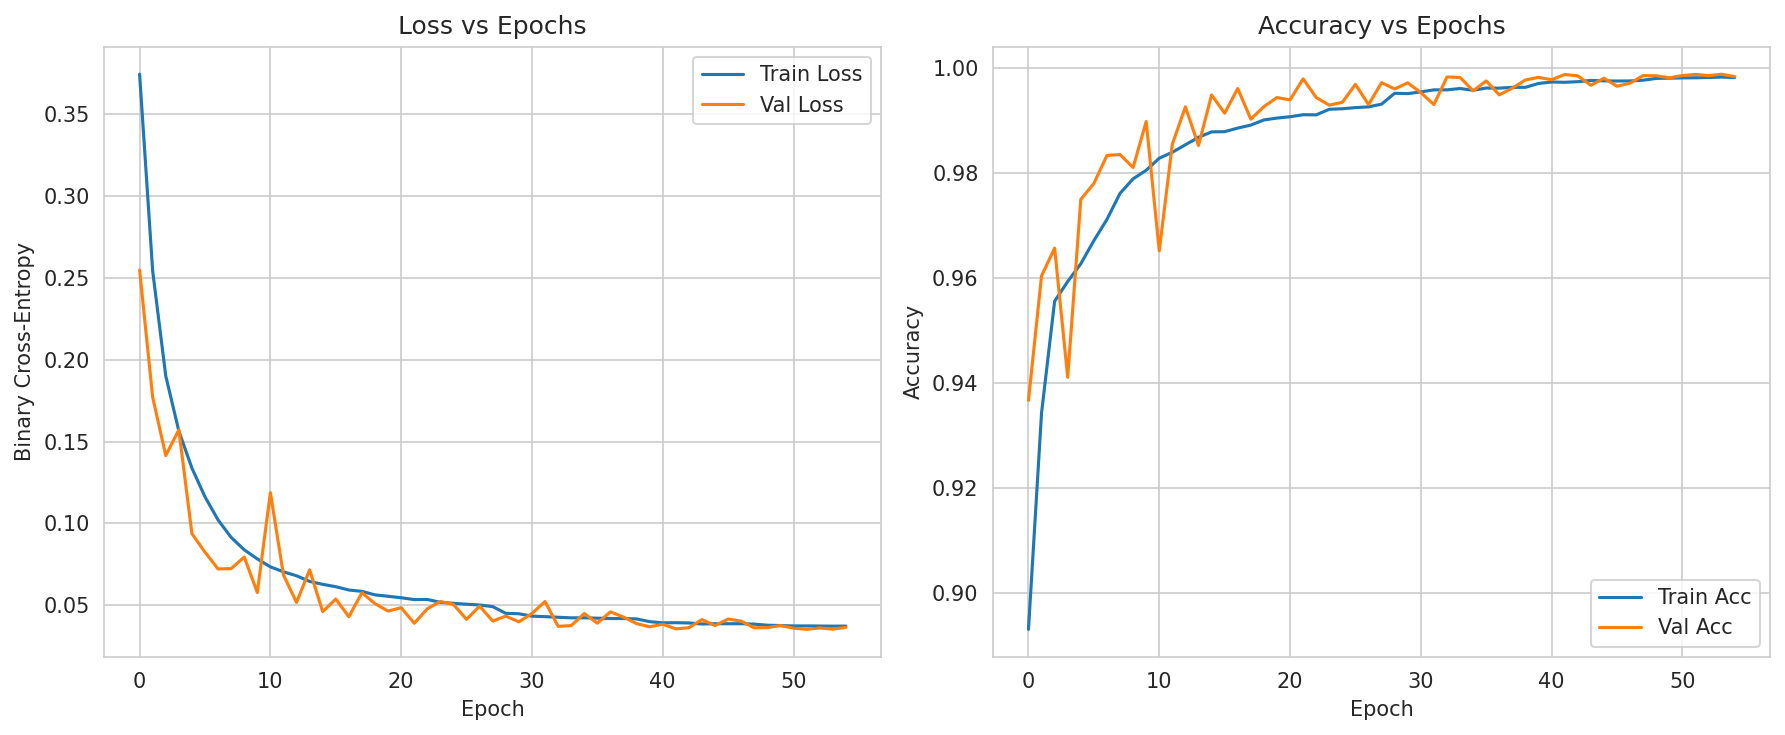

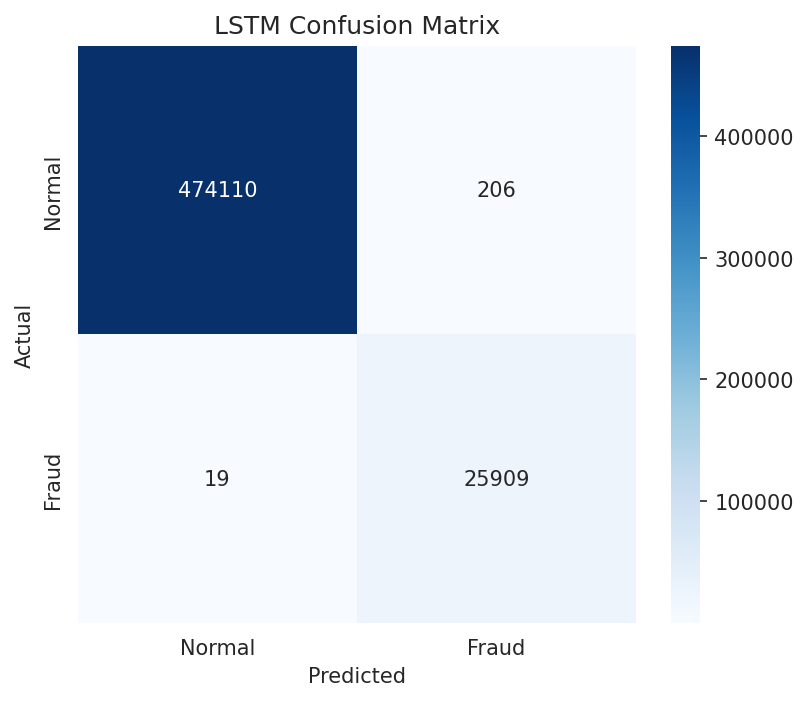

2026-04-15 14:48:36 - FraudDetection_LSTM - INFO - Saved ROC and PR curves to /kaggle/working/results/deep_learning/plots/lstm_roc_pr_curves.png


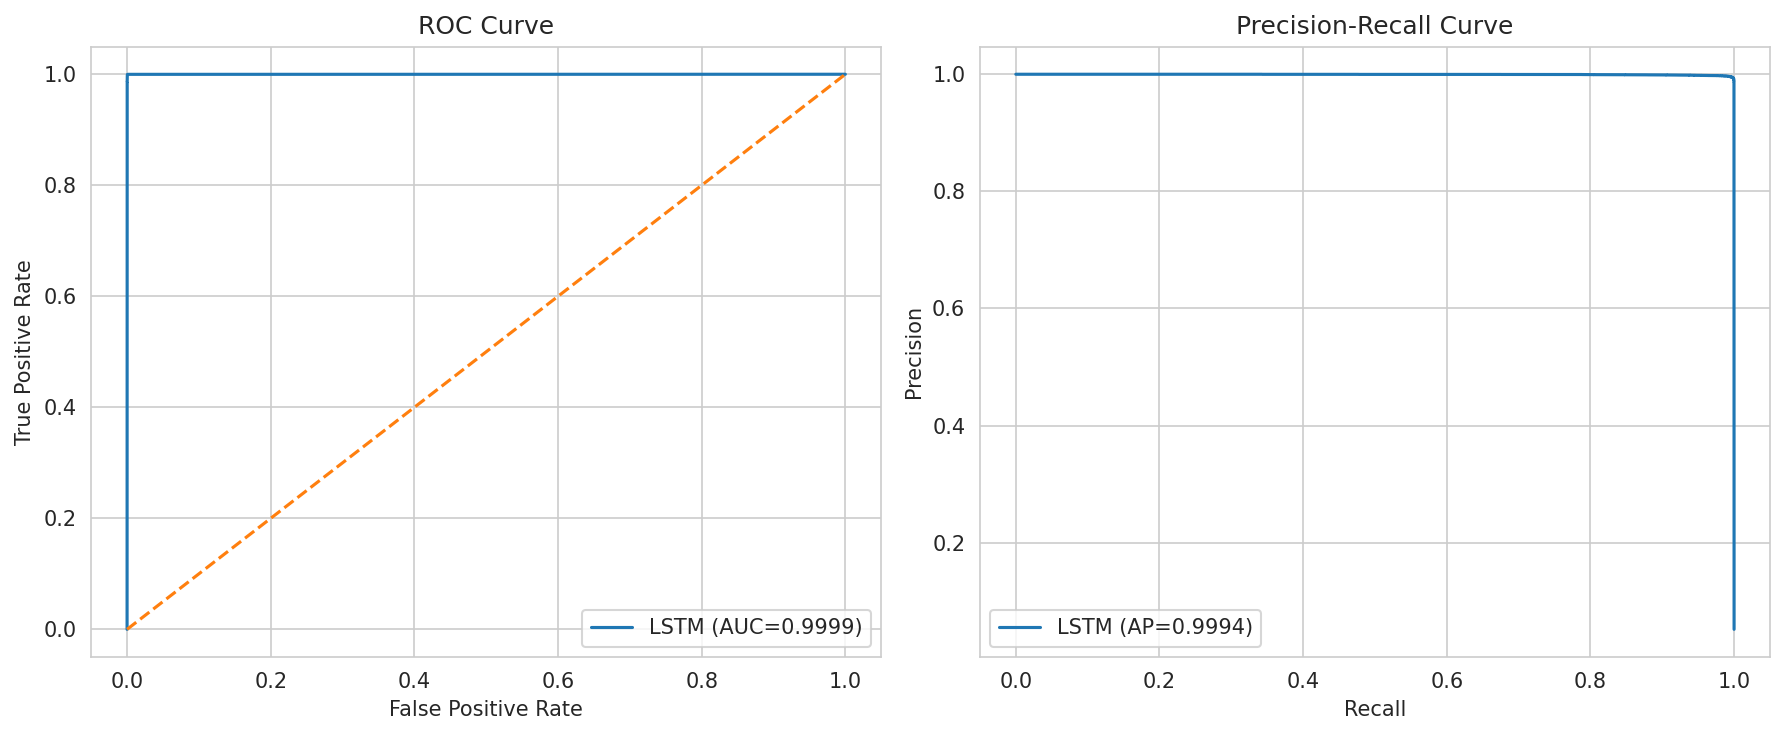

Cell 44: Deep learning visualizations generated.


In [7]:
# Cell 44: Section 10 - Deep learning visualizations (loss, accuracy, ROC, confusion matrix)

history_dict = {}
if "history" in locals() and history is not None:
    history_dict = history.history
elif os.path.exists(TRAIN_LOG_LOCAL_PATH):
    history_df = pd.read_csv(TRAIN_LOG_LOCAL_PATH)
    history_dict = {
        "loss": history_df.get("loss", pd.Series(dtype=float)).tolist(),
        "val_loss": history_df.get("val_loss", pd.Series(dtype=float)).tolist(),
        "accuracy": history_df.get("accuracy", pd.Series(dtype=float)).tolist(),
        "val_accuracy": history_df.get("val_accuracy", pd.Series(dtype=float)).tolist(),
    }

if history_dict:
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history_dict.get("loss", []), label="Train Loss")
    plt.plot(history_dict.get("val_loss", []), label="Val Loss")
    plt.title("Loss vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Binary Cross-Entropy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history_dict.get("accuracy", []), label="Train Acc")
    plt.plot(history_dict.get("val_accuracy", []), label="Val Acc")
    plt.title("Accuracy vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    loss_plot_path = os.path.join(PLOT_DL_DIR, "lstm_loss_accuracy.png")
    plt.tight_layout()
    plt.savefig(loss_plot_path, dpi=300)
    plt.show()

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="g",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"],
)
plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
cm_path = os.path.join(PLOT_DL_DIR, "lstm_confusion_matrix.png")
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

if len(np.unique(y_test)) > 1:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)
    pr_auc_val = average_precision_score(y_test, y_prob)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, label=f"LSTM (AUC={roc_auc_val:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, label=f"LSTM (AP={pr_auc_val:.4f})")
    plt.title("Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()

    curve_path = os.path.join(PLOT_DL_DIR, "lstm_roc_pr_curves.png")
    plt.tight_layout()
    plt.savefig(curve_path, dpi=300)
    log.info(f"Saved ROC and PR curves to {curve_path}")
    plt.show()

print("=" * 80)
print("Cell 44: Deep learning visualizations generated.")
print("=" * 80)

In [8]:
# Cell 45: Section 10 - Model metrics summary table

if not all_metrics:
    raise ValueError("No metrics found. Ensure Cell 43 (LSTM eval) has been executed.")

metrics_summary_pd = pd.DataFrame(all_metrics).set_index("Model")

# Sort by ROC-AUC descending
if "ROC-AUC" in metrics_summary_pd.columns:
    metrics_summary_pd = metrics_summary_pd.sort_values(by="ROC-AUC", ascending=False)

# Format for display
format_dict = {}
for col in metrics_summary_pd.columns:
    if col == "Train Time (s)":
        format_dict[col] = "{:.2f}"
    elif col == "Threshold":
        format_dict[col] = "{:.4f}"
    elif metrics_summary_pd[col].dtype in [float, np.float64, np.float32]:
        format_dict[col] = "{:.6f}"

styled_metrics = metrics_summary_pd.style.format(format_dict)

metrics_summary_pd.to_csv(COMPARISON_PATH)

try:
    display(styled_metrics)
except NameError:
    print(metrics_summary_pd)

print("=" * 80)
print("Cell 45: Model metrics summary saved.")
print("=" * 80)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Train Time (s),Threshold
Model,,,,,,,,
LSTM,0.999550,0.992112,0.999267,0.995677,0.999927,0.999450,11587.83,0.9700


Cell 45: Model metrics summary saved.
